## 1. Water Level Data Loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Define project directories
PROJECT_ROOT = Path.cwd().parent

data_path = (
    PROJECT_ROOT
    / "data"
    / "raw data"
    / "water levels"
)

processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

# Define output directories
outputs_path = (
    PROJECT_ROOT
    / "outputs"
)

ccm_results_path = (
    outputs_path
    / "ccm_results"
)

ccm_results_path.mkdir(
    parents=True,
    exist_ok=True
)

## 2. Data Cleaning

### (1)Clean the NOAA Great Lakes data

In [2]:
def clean_noaa_lake(file_1, file_2, lake_name):
    df1 = pd.read_csv(data_path / file_1)
    df2 = pd.read_csv(data_path / file_2)

    # Merge two time periods of the same lake
    df = pd.concat([df1, df2], ignore_index=True)

    df = df[["Date", "Verified (ft)"]].copy()

    df = df.rename(columns={
        "Verified (ft)": "Water_Level"
    })

    # Convert data types
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Water_Level"] = pd.to_numeric(df["Water_Level"], errors="coerce")

    # Add lake name
    df["Lake"] = lake_name

    # Deduplicate and sort by Date
    df = df.drop_duplicates(subset=["Date", "Lake"])
    df = df.sort_values("Date").reset_index(drop=True)

    return df

### (2)Clean USGS other 5 lakes data

In [3]:
def clean_usgs_lake(file, lake_name):
    df = pd.read_csv(data_path / file)
    df = df[["time", "value"]].copy()
    
    df = df.rename(columns={
        "time": "Date",
        "value": "Water_Level"
    })
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Water_Level"] = pd.to_numeric(df["Water_Level"], errors="coerce")
    df["Lake"] = lake_name

    df = df.drop_duplicates(subset=["Date", "Lake"])
    df = df.sort_values("Date").reset_index(drop=True)

    return df

### (3)Read and merge the 10 lakes data

In [4]:
superior = clean_noaa_lake(
    "Lake Superior 2006~2015.csv",
    "Lake Superior 2016~2025.csv",
    "Lake Superior"
)

huron = clean_noaa_lake(
    "Lake Huron 2006~2015.csv",
    "Lake Huron 2016~2025.csv",
    "Lake Huron"
)

michigan = clean_noaa_lake(
    "Lake Michigan 2006~2015.csv",
    "Lake Michigan 2016~2025.csv",
    "Lake Michigan"
)

erie = clean_noaa_lake(
    "Lake Erie 2006~2015.csv",
    "Lake Erie 2016~2025.csv",
    "Lake Erie"
)

ontario = clean_noaa_lake(
    "Lake Ontario 2006~2015.csv",
    "Lake Ontario 2016~2025.csv",
    "Lake Ontario"
)

lake_woods = clean_usgs_lake(
    "Lake Woods.csv",
    "Lake Woods"
)

great_salt_lake = clean_usgs_lake(
    "Great Salt Lake.csv",
    "Great Salt Lake"
)

lake_tahoe = clean_usgs_lake(
    "Lake Tahoe.csv",
    "Lake Tahoe"
)

red_lake = clean_usgs_lake(
    "Red Lake.csv",
    "Red Lake"
)

lake_champlain = clean_usgs_lake(
    "Lake Champlain.csv",
    "Lake Champlain"
)

water_level = pd.concat([
    superior,
    huron,
    michigan, 
    erie,
    ontario,
    lake_woods,
    great_salt_lake,
    lake_tahoe,
    red_lake,
    lake_champlain 
], ignore_index=True)

print(water_level.head())
print(water_level.tail())
print(water_level.columns)
print(water_level.shape)

        Date  Water_Level           Lake
0 2006-01-01       601.63  Lake Superior
1 2006-01-02       601.48  Lake Superior
2 2006-01-03       601.33  Lake Superior
3 2006-01-04       601.32  Lake Superior
4 2006-01-05       601.33  Lake Superior
            Date  Water_Level            Lake
72554 2025-12-27        95.32  Lake Champlain
72555 2025-12-28        95.29  Lake Champlain
72556 2025-12-29        95.31  Lake Champlain
72557 2025-12-30        95.39  Lake Champlain
72558 2025-12-31        95.44  Lake Champlain
Index(['Date', 'Water_Level', 'Lake'], dtype='object')
(72559, 3)


## 3. Missing Water-Level Data Assessment

### (1) missing data summary

In [5]:
lake_order = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario",
    "Lake Woods",
    "Great Salt Lake",
    "Lake Champlain",
    "Red Lake",
    "Lake Tahoe"
]

In [6]:
# Check which dates are missing in the lake
full_dates = pd.date_range(
    "2006-01-01",
    "2025-12-31",
    freq="D"
)

LONG_GAP_THRESHOLD = 14


# Summarise missing water-level dates for each lake

missing_date_summary = []

for lake in lake_order:

    observed_dates = pd.DatetimeIndex(
        water_level.loc[
            water_level["Lake"] == lake,
            "Date"
        ]
        .dropna()
        .sort_values()
    )

    missing_dates = full_dates.difference(
        observed_dates
    )

    missing_date_summary.append({
        "Lake": lake,
        "Missing_Days": len(missing_dates)
    })


missing_date_summary = (
    pd.DataFrame(missing_date_summary)
    .set_index("Lake")
    .reindex(lake_order)
)

display(missing_date_summary)

,Missing_Days
Lake,
Lake Superior,31
Lake Huron,35
Lake Michigan,1
Lake Erie,2
Lake Ontario,30
Lake Woods,154
Great Salt Lake,0
Lake Champlain,13
Red Lake,225


### (2)audit consecutive gaps

In [7]:
gap_records = []

for lake in lake_order:

    observed_dates = pd.DatetimeIndex(
        water_level.loc[
            water_level["Lake"] == lake,
            "Date"
        ]
        .dropna()
        .sort_values()
    )

    missing_dates = full_dates.difference(observed_dates)

    if len(missing_dates) == 0:
        continue

    start = missing_dates[0]
    previous = missing_dates[0]

    for current in missing_dates[1:]:

        if (current - previous).days > 1:

            gap_length = (previous - start).days + 1

            gap_records.append({
                "Lake": lake,
                "Gap_Start": start,
                "Gap_End": previous,
                "Gap_Days": gap_length
            })

            start = current

        previous = current

    # Add the final gap
    gap_length = (previous - start).days + 1

    gap_records.append({
        "Lake": lake,
        "Gap_Start": start,
        "Gap_End": previous,
        "Gap_Days": gap_length
    })


gap_summary = pd.DataFrame(gap_records)

gap_summary["Long_Gap"] = (
    gap_summary["Gap_Days"] > LONG_GAP_THRESHOLD
)

gap_summary = gap_summary.sort_values(
    ["Lake", "Gap_Start"]
).reset_index(drop=True)

display(gap_summary)

,Lake,Gap_Start,Gap_End,Gap_Days,Long_Gap
0,Lake Champlain,2015-11-19,2015-11-19,1,False
1,Lake Champlain,2016-04-07,2016-04-07,1,False
2,Lake Champlain,2016-10-17,2016-10-17,1,False
3,Lake Champlain,2020-03-17,2020-03-19,3,False
4,Lake Champlain,2020-09-04,2020-09-04,1,False
5,Lake Champlain,2023-06-07,2023-06-08,2,False
6,Lake Champlain,2024-06-10,2024-06-10,1,False
7,Lake Champlain,2025-06-14,2025-06-16,3,False
8,Lake Erie,2015-12-31,2015-12-31,1,False
9,Lake Erie,2021-11-30,2021-11-30,1,False


In [8]:
# Summarise missing-gap characteristics by lake

gap_lake_summary = (
    gap_summary
    .groupby("Lake")
    .agg(
        Number_of_Gaps=("Gap_Days", "count"),
        Missing_Days=("Gap_Days", "sum"),
        Maximum_Gap_Days=("Gap_Days", "max"),
        Number_of_Long_Gaps=("Long_Gap", "sum")
    )
    .reindex(lake_order)
)

gap_lake_summary = gap_lake_summary.fillna(0)

display(gap_lake_summary)

,Number_of_Gaps,Missing_Days,Maximum_Gap_Days,Number_of_Long_Gaps
Lake,,,,
Lake Superior,1.0,31.0,31.0,1.0
Lake Huron,2.0,35.0,30.0,1.0
Lake Michigan,1.0,1.0,1.0,0.0
Lake Erie,2.0,2.0,1.0,0.0
Lake Ontario,1.0,30.0,30.0,1.0
Lake Woods,25.0,154.0,21.0,1.0
Great Salt Lake,0.0,0.0,0.0,0.0
Lake Champlain,8.0,13.0,3.0,0.0
Red Lake,16.0,225.0,87.0,2.0


### (3)complete daily dataset and preserve originals

In [9]:
# Create a complete daily sequence for every lake

def complete_dates(df):
    """
    Complete the daily date sequence for one lake.
    Missing dates are retained as rows with NaN water levels.
    """

    # The group name contains the lake name when
    # include_groups=False is used
    lake_name = df.name

    complete_df = pd.DataFrame({
        "Date": full_dates
    })

    complete_df["Lake"] = lake_name

    complete_df = complete_df.merge(
        df[["Date", "Water_Level"]],
        on="Date",
        how="left"
    )

    return complete_df


water_level_complete = (
    water_level
    .groupby(
        "Lake",
        group_keys=False,
        observed=True
    )
    .apply(
        complete_dates,
        include_groups=False
    )
    .reset_index(drop=True)
)


# Preserve original observations before any interpolation

water_level_complete[
    "Water_Level_Original"
] = (
    water_level_complete[
        "Water_Level"
    ].copy()
)


water_level_complete[
    "Water_Level_Observed"
] = (
    water_level_complete[
        "Water_Level_Original"
    ].notna()
)
#All subsequent gap detections are based on Water_Level_Original.

### (4)calculate gap lengths

In [10]:
# Calculate the length of the consecutive missing gap

def calculate_missing_gap_length(series):

    missing = series.isna()

    gap_group = (
        missing != missing.shift(fill_value=False)
    ).cumsum()

    gap_length = (
        missing
        .groupby(gap_group)
        .transform("sum")
    )

    return (
        gap_length
        .where(missing, 0)
        .astype(int)
    )


water_level_complete["Missing_Gap_Length_Days"] = (
    water_level_complete
    .groupby("Lake",observed=True)["Water_Level_Original"]
    .transform(calculate_missing_gap_length)
)


water_level_complete["Water_Long_Gap"] = (
    (~water_level_complete["Water_Level_Observed"])
    &
    (
        water_level_complete["Missing_Gap_Length_Days"]
        > LONG_GAP_THRESHOLD
    )
)

### (5)Sensitivity analysis of long-gap interpolation

In [11]:
# Create a fully interpolated series for sensitivity analysis only

water_level_complete[
    "Water_Level_Full_Interpolation"
] = (
    water_level_complete
    .groupby(
        "Lake",
        observed=True
    )["Water_Level_Original"]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit_area="inside"
        )
    )
)

# Create a sensitivity-analysis series
# in which long-gap interpolated values are excluded

water_level_complete[
    "Water_Level_No_Long_Gap"
] = (
    water_level_complete[
        "Water_Level_Full_Interpolation"
    ].copy()
)


water_level_complete.loc[
    water_level_complete[
        "Water_Long_Gap"
    ],
    "Water_Level_No_Long_Gap"
] = np.nan

#### (1)annual sensitivity

In [12]:
# compare annual means with and without long-gap interpolation

water_sensitivity = (
    water_level_complete[
        [
            "Date",
            "Lake",
            "Water_Level_Full_Interpolation",
            "Water_Level_No_Long_Gap"
        ]
    ]
    .copy()
)

water_sensitivity["Year"] = (
    water_sensitivity["Date"].dt.year
)


annual_sensitivity = (
    water_sensitivity
    .groupby(
        ["Lake", "Year"],
        observed=True
    )
    .agg(
        Annual_Mean_Full_Interpolation=(
            "Water_Level_Full_Interpolation",
            "mean"
        ),
        Annual_Mean_Without_Long_Gaps=(
            "Water_Level_No_Long_Gap",
            "mean"
        )
    )
    .reset_index()
)


annual_sensitivity["Absolute_Difference"] = (
    annual_sensitivity[
        "Annual_Mean_Full_Interpolation"
    ]
    -
    annual_sensitivity[
        "Annual_Mean_Without_Long_Gaps"
    ]
).abs()


annual_sensitivity_summary = (
    annual_sensitivity
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Mean_Annual_Difference=(
            "Absolute_Difference",
            "mean"
        ),
        Maximum_Annual_Difference=(
            "Absolute_Difference",
            "max"
        )
    )
    .reindex(lake_order)
)

display(
    annual_sensitivity_summary.round(4)
)

,Mean_Annual_Difference,Maximum_Annual_Difference
Lake,,
Lake Superior,0.0027,0.0537
Lake Huron,0.0009,0.0183
Lake Michigan,0.0000,0.0000
Lake Erie,0.0000,0.0000
Lake Ontario,0.0024,0.0471
Lake Woods,0.0015,0.0300
Great Salt Lake,0.0000,0.0000
Lake Champlain,0.0000,0.0000
Red Lake,0.0207,0.3926


#### (2)monthly sensitivity

In [13]:
# compare monthly climatology with and without long-gap interpolation

water_sensitivity["Month"] = (
    water_sensitivity["Date"].dt.month
)


monthly_sensitivity = (
    water_sensitivity
    .groupby(
        ["Lake", "Month"],
        observed=True
    )
    .agg(
        Monthly_Mean_Full_Interpolation=(
            "Water_Level_Full_Interpolation",
            "mean"
        ),
        Monthly_Mean_Without_Long_Gaps=(
            "Water_Level_No_Long_Gap",
            "mean"
        )
    )
    .reset_index()
)


monthly_sensitivity["Absolute_Difference"] = (
    monthly_sensitivity[
        "Monthly_Mean_Full_Interpolation"
    ]
    -
    monthly_sensitivity[
        "Monthly_Mean_Without_Long_Gaps"
    ]
).abs()


monthly_sensitivity_summary = (
    monthly_sensitivity
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Mean_Monthly_Difference=(
            "Absolute_Difference",
            "mean"
        ),
        Maximum_Monthly_Difference=(
            "Absolute_Difference",
            "max"
        )
    )
    .reindex(lake_order)
)

display(
    monthly_sensitivity_summary.round(4)
)

,Mean_Monthly_Difference,Maximum_Monthly_Difference
Lake,,
Lake Superior,0.0024,0.0277
Lake Huron,0.0057,0.0683
Lake Michigan,0.0000,0.0000
Lake Erie,0.0000,0.0000
Lake Ontario,0.0007,0.0081
Lake Woods,0.0005,0.0038
Great Salt Lake,0.0000,0.0000
Lake Champlain,0.0000,0.0000
Red Lake,0.0196,0.0604


### (6)Water-level missing data treatment

In [14]:
# Apply the final missing-data treatment:
# interpolate only short internal gaps (<=14 days)

short_gap_mask = (
    (~water_level_complete[
        "Water_Level_Observed"
    ])
    &
    (
        water_level_complete[
            "Missing_Gap_Length_Days"
        ]
        <= LONG_GAP_THRESHOLD
    )
)


# Start from the original observations
water_level_complete[
    "Water_Level"
] = (
    water_level_complete[
        "Water_Level_Original"
    ].copy()
)


# Fill only short gaps using linear interpolation
water_level_complete.loc[
    short_gap_mask,
    "Water_Level"
] = water_level_complete.loc[
    short_gap_mask,
    "Water_Level_Full_Interpolation"
]


water_level_complete[
    "Water_Level_Imputed"
] = (
    short_gap_mask
    &
    water_level_complete[
        "Water_Level"
    ].notna()
)

### (7)treatment summary

In [15]:
# Summarise the final water-level missing-data treatment

water_imputation_summary = (
    water_level_complete
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Observed_Days=(
            "Water_Level_Observed",
            "sum"
        ),
        Short_Gap_Imputed_Days=(
            "Water_Level_Imputed",
            "sum"
        ),
        Long_Gap_Missing_Days=(
            "Water_Long_Gap",
            "sum"
        ),
        Maximum_Gap_Days=(
            "Missing_Gap_Length_Days",
            "max"
        )
    )
    .reindex(lake_order)
)

display(
    water_imputation_summary
)

,Observed_Days,Short_Gap_Imputed_Days,Long_Gap_Missing_Days,Maximum_Gap_Days
Lake,,,,
Lake Superior,7274,0,31,31
Lake Huron,7270,5,30,30
Lake Michigan,7304,1,0,1
Lake Erie,7303,2,0,1
Lake Ontario,7275,0,30,30
Lake Woods,7151,133,21,21
Great Salt Lake,7305,0,0,0
Lake Champlain,7292,13,0,3
Red Lake,7080,58,167,87


### (8)final dataset validation

In [16]:
# Check the final water-level dataset after missing-data treatment

final_water_check = (
    water_level_complete
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Total_Days=(
            "Date",
            "size"
        ),
        Available_Water_Level=(
            "Water_Level",
            "count"
        ),
        Remaining_Missing=(
            "Water_Level",
            lambda x: x.isna().sum()
        )
    )
    .reindex(lake_order)
)

display(final_water_check)

,Total_Days,Available_Water_Level,Remaining_Missing
Lake,,,
Lake Superior,7305,7274,31
Lake Huron,7305,7275,30
Lake Michigan,7305,7305,0
Lake Erie,7305,7305,0
Lake Ontario,7305,7275,30
Lake Woods,7305,7284,21
Great Salt Lake,7305,7305,0
Lake Champlain,7305,7305,0
Red Lake,7305,7138,167


In [17]:
# Validate the final missing-data treatment

assert (
    water_level_complete.loc[
        water_level_complete[
            "Water_Long_Gap"
        ],
        "Water_Level"
    ]
    .isna()
    .all()
)


assert (
    water_level_complete.loc[
        water_level_complete[
            "Water_Level_Imputed"
        ],
        "Water_Level"
    ]
    .notna()
    .all()
)


print(
    "Final water-level missing-data treatment verified."
)

Final water-level missing-data treatment verified.


In [18]:
# Prepare Appendix Table A1:
# missing water-level observations and final treatment

appendix_A1 = (
    water_imputation_summary[
        [
            "Short_Gap_Imputed_Days",
            "Long_Gap_Missing_Days"
        ]
    ]
    .copy()
)


# Calculate the number of originally missing observations
appendix_A1["Original_Missing_Days"] = (
    appendix_A1["Short_Gap_Imputed_Days"]
    +
    appendix_A1["Long_Gap_Missing_Days"]
)


# Calculate the original missing percentage
appendix_A1["Missing_Percent"] = (
    appendix_A1["Original_Missing_Days"]
    / len(full_dates)
    * 100
)


# Arrange columns for the dissertation table
appendix_A1 = appendix_A1[
    [
        "Original_Missing_Days",
        "Missing_Percent",
        "Short_Gap_Imputed_Days",
        "Long_Gap_Missing_Days"
    ]
]


# Add the overall row
appendix_A1.loc["Overall"] = [
    appendix_A1["Original_Missing_Days"].sum(),
    appendix_A1["Original_Missing_Days"].sum()
    / (len(full_dates) * len(lake_order))
    * 100,
    appendix_A1["Short_Gap_Imputed_Days"].sum(),
    appendix_A1["Long_Gap_Missing_Days"].sum()
]


# Format percentage for display
appendix_A1["Missing_Percent"] = (
    appendix_A1["Missing_Percent"].round(2)
)

display(appendix_A1)

,Original_Missing_Days,Missing_Percent,Short_Gap_Imputed_Days,Long_Gap_Missing_Days
Lake,,,,
Lake Superior,31.0,0.42,0.0,31.0
Lake Huron,35.0,0.48,5.0,30.0
Lake Michigan,1.0,0.01,1.0,0.0
Lake Erie,2.0,0.03,2.0,0.0
Lake Ontario,30.0,0.41,0.0,30.0
Lake Woods,154.0,2.11,133.0,21.0
Great Salt Lake,0.0,0.00,0.0,0.0
Lake Champlain,13.0,0.18,13.0,0.0
Red Lake,225.0,3.08,58.0,167.0


## 4.Climate Data Prerocessing

### (1)Climate Data Loading

In [19]:
# Define the directory containing climate data

climate_path = (
    PROJECT_ROOT
    / "data"
    / "raw data"
    / "climate variables"
)


# Define climate files for each lake

climate_files = {
    "Lake Superior": "Lake_Superior.csv",
    "Lake Huron": "Lake_Huron.csv",
    "Lake Michigan": "Lake_Michigan.csv",
    "Lake Erie": "Lake_Erie.csv",
    "Lake Ontario": "Lake_Ontario.csv",
    "Lake Woods": "Lake_Woods.csv",
    "Great Salt Lake": "Great_Salt_Lake.csv",
    "Lake Tahoe": "Lake_Tahoe.csv",
    "Red Lake": "Red_Lake.csv",
    "Lake Champlain": "Lake_Champlain.csv"
}

In [20]:
def clean_climate_file(file_name, lake_name):

    df = pd.read_csv(
        climate_path / file_name
    )

    # Keep the original meteorological variables
    keep_cols = [
        "DATE",
        "PRCP",
        "TMAX",
        "TMIN"
    ]

    if "WESD" in df.columns:
        keep_cols.append("WESD")

    df = df[keep_cols].copy()

    df = df.rename(
        columns={
            "DATE": "Date"
        }
    )

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    for col in [
        "PRCP",
        "TMAX",
        "TMIN",
        "WESD"
    ]:

        if col in df.columns:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    if "WESD" not in df.columns:
        df["WESD"] = np.nan

    df["Lake"] = lake_name

    df = df[
        [
            "Date",
            "Lake",
            "PRCP",
            "TMAX",
            "TMIN",
            "WESD"
        ]
    ]

    df = df.drop_duplicates(
        subset=["Date", "Lake"]
    )

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    return df

In [21]:
# Read and combine all climate files

climate_list = []

for lake, file_name in climate_files.items():

    temp = clean_climate_file(
        file_name,
        lake
    )

    climate_list.append(temp)


climate_data = pd.concat(
    climate_list,
    ignore_index=True
)


climate_data["Lake"] = pd.Categorical(
    climate_data["Lake"],
    categories=lake_order,
    ordered=True
)


climate_data = (
    climate_data
    .sort_values(
        ["Lake", "Date"]
    )
    .reset_index(drop=True)
)


print(type(climate_data))
print(climate_data.shape)
print(climate_data.columns)

<class 'pandas.core.frame.DataFrame'>
(72837, 6)
Index(['Date', 'Lake', 'PRCP', 'TMAX', 'TMIN', 'WESD'], dtype='object')


### (2)Climate Data Cleaning and Standardisation

In [22]:
# Complete the daily date sequence for each lake

full_dates = pd.date_range(
    start="2006-01-01",
    end="2025-12-31",
    freq="D"
)


def complete_climate_dates(df):
    """
    Complete the daily climate date sequence for one lake.
    Missing dates are retained as rows with NaN climate values.
    """

    lake_name = df.name

    full_df = pd.DataFrame({
        "Date": full_dates
    })

    full_df["Lake"] = lake_name

    merged = full_df.merge(
        df[
            [
                "Date",
                "PRCP",
                "TMAX",
                "TMIN",
                "WESD"
            ]
        ],
        on="Date",
        how="left"
    )

    return merged


climate_complete = (
    climate_data
    .groupby(
        "Lake",
        observed=True,
        group_keys=False
    )
    .apply(
        complete_climate_dates,
        include_groups=False
    )
    .reset_index(drop=True)
)


climate_complete["Lake"] = pd.Categorical(
    climate_complete["Lake"],
    categories=lake_order,
    ordered=True
)

climate_complete = (
    climate_complete
    .sort_values(["Lake", "Date"])
    .reset_index(drop=True)
)


print(
    climate_complete
    .groupby(
        "Lake",
        observed=True
    )
    .size()
)

Lake
Lake Superior      7305
Lake Huron         7305
Lake Michigan      7305
Lake Erie          7305
Lake Ontario       7305
Lake Woods         7305
Great Salt Lake    7305
Lake Champlain     7305
Red Lake           7305
Lake Tahoe         7305
dtype: int64


In [23]:
# Preserve original meteorological observations
# before any missing-data treatment

for var in ["PRCP", "TMAX", "TMIN"]:

    climate_complete[
        f"{var}_Original"
    ] = climate_complete[var].copy()

    climate_complete[
        f"{var}_Observed"
    ] = climate_complete[
        f"{var}_Original"
    ].notna()

In [24]:
# Audit consecutive missing gaps for the main meteorological variables

climate_variables_audit = [
    "PRCP",
    "TMAX",
    "TMIN"
]

climate_gap_records = []


for lake in lake_order:

    lake_data = (
        climate_complete[
            climate_complete["Lake"] == lake
        ]
        .sort_values("Date")
    )

    for variable in climate_variables_audit:

        missing = (
            lake_data[
                f"{variable}_Original"
            ]
            .isna()
            .to_numpy()
        )

        dates = (
            lake_data["Date"]
            .to_numpy()
        )

        start_index = None

        for i, is_missing in enumerate(missing):

            if is_missing and start_index is None:
                start_index = i

            if (
                start_index is not None
                and
                (
                    not is_missing
                    or i == len(missing) - 1
                )
            ):

                if not is_missing:
                    end_index = i - 1
                else:
                    end_index = i

                climate_gap_records.append({
                    "Lake": lake,
                    "Variable": variable,
                    "Gap_Start": pd.Timestamp(
                        dates[start_index]
                    ),
                    "Gap_End": pd.Timestamp(
                        dates[end_index]
                    ),
                    "Gap_Days":
                        end_index
                        - start_index
                        + 1
                })

                start_index = None


climate_gap_summary = pd.DataFrame(
    climate_gap_records
)

climate_gap_summary = (
    climate_gap_summary
    .sort_values(
        [
            "Lake",
            "Variable",
            "Gap_Start"
        ]
    )
    .reset_index(drop=True)
)

display(climate_gap_summary)

,Lake,Variable,Gap_Start,Gap_End,Gap_Days
0,Great Salt Lake,PRCP,2025-01-28,2025-01-28,1
1,Great Salt Lake,PRCP,2025-08-31,2025-08-31,1
2,Great Salt Lake,TMAX,2025-01-28,2025-01-28,1
3,Great Salt Lake,TMAX,2025-03-10,2025-03-11,2
4,Great Salt Lake,TMAX,2025-08-31,2025-08-31,1
...,...,...,...,...,...
187,Red Lake,TMIN,2022-06-30,2022-06-30,1
188,Red Lake,TMIN,2025-01-05,2025-01-05,1
189,Red Lake,TMIN,2025-04-08,2025-04-08,1
190,Red Lake,TMIN,2025-07-30,2025-07-31,2


In [25]:
# Summarise meteorological missing-gap characteristics

climate_gap_lake_summary = (
    climate_gap_summary
    .groupby(
        ["Lake", "Variable"],
        observed=True
    )
    .agg(
        Number_of_Gaps=(
            "Gap_Days",
            "count"
        ),
        Missing_Days=(
            "Gap_Days",
            "sum"
        ),
        Maximum_Gap_Days=(
            "Gap_Days",
            "max"
        )
    )
    .reset_index()
)


climate_gap_lake_summary["Lake"] = (
    pd.Categorical(
        climate_gap_lake_summary["Lake"],
        categories=lake_order,
        ordered=True
    )
)

climate_gap_lake_summary = (
    climate_gap_lake_summary
    .sort_values(
        ["Lake", "Variable"]
    )
    .reset_index(drop=True)
)

display(climate_gap_lake_summary)

,Lake,Variable,Number_of_Gaps,Missing_Days,Maximum_Gap_Days
0,Lake Huron,PRCP,5,9,4
1,Lake Huron,TMAX,2,4,3
2,Lake Huron,TMIN,3,5,3
3,Lake Woods,PRCP,45,49,2
4,Lake Woods,TMAX,18,59,34
5,Lake Woods,TMIN,19,60,34
6,Great Salt Lake,PRCP,2,2,1
7,Great Salt Lake,TMAX,3,4,2
8,Great Salt Lake,TMIN,3,4,2
9,Red Lake,PRCP,25,238,57


PRCP: retained as missing rather than interpolated

TMIN/TMAX: TMAX and TMIN gaps of up to 7 consecutive days are linearly interpolated; gaps longer than 7 days remain missing.

In [26]:
# Display the maximum missing gap for each climate variable by lake

climate_max_gap_summary = (
    climate_gap_lake_summary
    .pivot(
        index="Lake",
        columns="Variable",
        values="Maximum_Gap_Days"
    )
    .reindex(lake_order)
    .fillna(0)
)

display(climate_max_gap_summary)

Variable,PRCP,TMAX,TMIN
Lake,,,
Lake Superior,0.0,0.0,0.0
Lake Huron,4.0,3.0,3.0
Lake Michigan,0.0,0.0,0.0
Lake Erie,0.0,0.0,0.0
Lake Ontario,0.0,0.0,0.0
Lake Woods,2.0,34.0,34.0
Great Salt Lake,1.0,2.0,2.0
Lake Champlain,0.0,0.0,0.0
Red Lake,57.0,391.0,391.0


### (3)Meteorological Missing-Data Treatment

In [27]:
# Display temperature gaps that exceed the interpolation threshold

TEMP_GAP_THRESHOLD = 7

long_temperature_gaps = (
    climate_gap_summary[
        climate_gap_summary["Variable"].isin(
            ["TMAX", "TMIN"]
        )
        &
        (
            climate_gap_summary["Gap_Days"]
            > TEMP_GAP_THRESHOLD
        )
    ]
    .sort_values(
        ["Lake", "Variable", "Gap_Start"]
    )
    .reset_index(drop=True)
)

display(long_temperature_gaps)

,Lake,Variable,Gap_Start,Gap_End,Gap_Days
0,Lake Woods,TMAX,2021-08-25,2021-09-27,34
1,Lake Woods,TMIN,2021-08-25,2021-09-27,34
2,Red Lake,TMAX,2008-09-01,2008-09-30,30
3,Red Lake,TMAX,2012-07-23,2012-08-31,40
4,Red Lake,TMAX,2019-06-05,2019-07-31,57
5,Red Lake,TMAX,2019-09-01,2020-09-25,391
6,Red Lake,TMIN,2008-09-01,2008-09-30,30
7,Red Lake,TMIN,2012-07-23,2012-08-31,40
8,Red Lake,TMIN,2019-06-05,2019-07-31,57
9,Red Lake,TMIN,2019-09-01,2020-09-25,391


In [28]:
# Create temperature-gap detail table

temperature_gap_detail = (
    climate_gap_summary[
        climate_gap_summary["Variable"].isin(
            ["TMAX", "TMIN"]
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# Summarise temperature gaps by length category

def classify_temperature_gap(days):

    if days <= 3:
        return "1-3 days"

    elif days <= 7:
        return "4-7 days"

    elif days <= 14:
        return "8-14 days"

    elif days <= 30:
        return "15-30 days"

    else:
        return ">30 days"


temperature_gap_detail["Gap_Category"] = (
    temperature_gap_detail["Gap_Days"]
    .apply(classify_temperature_gap)
)


temperature_gap_distribution = (
    temperature_gap_detail
    .groupby(
        ["Lake", "Variable", "Gap_Category"],
        observed=True
    )
    .size()
    .reset_index(
        name="Number_of_Gaps"
    )
)

display(temperature_gap_distribution)

,Lake,Variable,Gap_Category,Number_of_Gaps
0,Great Salt Lake,TMAX,1-3 days,3
1,Great Salt Lake,TMIN,1-3 days,3
2,Lake Huron,TMAX,1-3 days,2
3,Lake Huron,TMIN,1-3 days,3
4,Lake Tahoe,TMAX,1-3 days,1
5,Lake Tahoe,TMIN,1-3 days,3
6,Lake Woods,TMAX,1-3 days,16
7,Lake Woods,TMAX,4-7 days,1
8,Lake Woods,TMAX,>30 days,1
9,Lake Woods,TMIN,1-3 days,17


In [29]:
# Final meteorological missing-data treatment

TEMP_GAP_THRESHOLD = 7


# Retain missing precipitation observations
# rather than applying linear interpolation

climate_complete["PRCP"] = (
    climate_complete["PRCP_Original"].copy()
)

climate_complete["PRCP_Imputed"] = False


# Apply gap-aware interpolation to TMAX and TMIN

for var in ["TMAX", "TMIN"]:

    # Calculate the length of the missing gap
    # associated with each observation
    climate_complete[
        f"{var}_Gap_Length_Days"
    ] = (
        climate_complete
        .groupby(
            "Lake",
            observed=True
        )[f"{var}_Original"]
        .transform(
            calculate_missing_gap_length
        )
    )


    # Generate interpolation candidates using
    # only values bounded by observed data
    interpolation_candidate = (
        climate_complete
        .groupby(
            "Lake",
            observed=True
        )[f"{var}_Original"]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit_area="inside"
            )
        )
    )


    # Identify short internal gaps eligible for interpolation
    short_gap_mask = (
        climate_complete[
            f"{var}_Original"
        ].isna()
        &
        (
            climate_complete[
                f"{var}_Gap_Length_Days"
            ]
            <= TEMP_GAP_THRESHOLD
        )
        &
        interpolation_candidate.notna()
    )


    # Start from the original observations
    climate_complete[var] = (
        climate_complete[
            f"{var}_Original"
        ].copy()
    )


    # Fill only short internal gaps
    climate_complete.loc[
        short_gap_mask,
        var
    ] = interpolation_candidate.loc[
        short_gap_mask
    ]


    # Flag values actually interpolated
    climate_complete[
        f"{var}_Imputed"
    ] = short_gap_mask


    # Flag longer gaps retained as missing
    climate_complete[
        f"{var}_Long_Gap"
    ] = (
        climate_complete[
            f"{var}_Original"
        ].isna()
        &
        (
            climate_complete[
                f"{var}_Gap_Length_Days"
            ]
            > TEMP_GAP_THRESHOLD
        )
    )

In [30]:
# Summarise final meteorological missing-data treatment

climate_treatment_summary = []

for lake in lake_order:

    lake_df = climate_complete[
        climate_complete["Lake"] == lake
    ]

    for var in ["PRCP", "TMAX", "TMIN"]:

        original_missing = (
            lake_df[f"{var}_Original"]
            .isna()
            .sum()
        )

        if var == "PRCP":

            imputed_days = 0

        else:

            imputed_days = (
                lake_df[f"{var}_Imputed"]
                .sum()
            )

        remaining_missing = (
            lake_df[var]
            .isna()
            .sum()
        )

        climate_treatment_summary.append({
            "Lake": lake,
            "Variable": var,
            "Original_Missing_Days": original_missing,
            "Imputed_Days": imputed_days,
            "Remaining_Missing_Days": remaining_missing
        })


climate_treatment_summary = pd.DataFrame(
    climate_treatment_summary
)

climate_treatment_summary["Lake"] = pd.Categorical(
    climate_treatment_summary["Lake"],
    categories=lake_order,
    ordered=True
)

climate_treatment_summary = (
    climate_treatment_summary
    .sort_values(
        ["Lake", "Variable"]
    )
    .reset_index(drop=True)
)

display(climate_treatment_summary)

,Lake,Variable,Original_Missing_Days,Imputed_Days,Remaining_Missing_Days
0,Lake Superior,PRCP,0,0,0
1,Lake Superior,TMAX,0,0,0
2,Lake Superior,TMIN,0,0,0
3,Lake Huron,PRCP,9,0,9
4,Lake Huron,TMAX,4,4,0
5,Lake Huron,TMIN,5,5,0
6,Lake Michigan,PRCP,0,0,0
7,Lake Michigan,TMAX,0,0,0
8,Lake Michigan,TMIN,0,0,0
9,Lake Erie,PRCP,0,0,0


In [31]:
# Validate retained long temperature gaps

for var in ["TMAX", "TMIN"]:

    assert (
        climate_complete.loc[
            climate_complete[f"{var}_Long_Gap"],
            var
        ]
        .isna()
        .all()
    )

print(
    "Temperature missing-data treatment verified."
)

Temperature missing-data treatment verified.


### (4) Reconstruction of Daily Mean Temperature

In [32]:
# Recalculate daily mean temperature 
#after the final TMAX and TMIN missing-data treatment

climate_complete["TMEAN"] = (
    climate_complete["TMAX"]
    +
    climate_complete["TMIN"]
) / 2

# Construct the original TMEAN series from 
#the original TMAX and TMIN observations

climate_complete["TMEAN_Original"] = (
    climate_complete["TMAX_Original"]
    +
    climate_complete["TMIN_Original"]
) / 2

# Flag TMEAN values derived from at least 
#one interpolated temperature component

climate_complete["TMEAN_Derived_From_Imputation"] = (
    climate_complete["TMAX_Imputed"]
    |
    climate_complete["TMIN_Imputed"]
)

In [33]:
# Check TMEAN consistency

tmean_difference = (
    climate_complete["TMEAN"]
    -
    (
        climate_complete["TMAX"]
        +
        climate_complete["TMIN"]
    ) / 2
)

assert (
    tmean_difference
    .dropna()
    .abs()
    .max()
    < 1e-10
)

print(
    "TMEAN verified as the mean of final TMAX and TMIN."
)

TMEAN verified as the mean of final TMAX and TMIN.


In [34]:
# Summarise final TMEAN missingness

tmean_missing_summary = (
    climate_complete
    .groupby(
        "Lake",
        observed=True
    )["TMEAN"]
    .agg(
        Available_Days="count",
        Remaining_Missing_Days=lambda x: x.isna().sum()
    )
    .reindex(lake_order)
)

display(tmean_missing_summary)

,Available_Days,Remaining_Missing_Days
Lake,,
Lake Superior,7305,0
Lake Huron,7305,0
Lake Michigan,7305,0
Lake Erie,7305,0
Lake Ontario,7305,0
Lake Woods,7271,34
Great Salt Lake,7305,0
Lake Champlain,7305,0
Red Lake,6787,518


### (5) WESD Availability Assessment

In [35]:
# Assess WESD availability by lake

wesd_summary = (
    climate_complete
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Total_Days=("Date", "count"),
        Missing_WESD=(
            "WESD",
            lambda x: x.isna().sum()
        ),
        Available_WESD=(
            "WESD",
            lambda x: x.notna().sum()
        )
    )
    .reindex(lake_order)
)


wesd_summary["Available_Percent"] = (
    wesd_summary["Available_WESD"]
    / wesd_summary["Total_Days"]
    * 100
)

display(
    wesd_summary.round(2)
)

,Total_Days,Missing_WESD,Available_WESD,Available_Percent
Lake,,,,
Lake Superior,7305,5479,1826,25.00
Lake Huron,7305,7305,0,0.00
Lake Michigan,7305,5479,1826,25.00
Lake Erie,7305,5167,2138,29.27
Lake Ontario,7305,5444,1861,25.48
Lake Woods,7305,7305,0,0.00
Great Salt Lake,7305,5479,1826,25.00
Lake Champlain,7305,5479,1826,25.00
Red Lake,7305,7305,0,0.00


### (5)Final Dataset Construction

In [36]:
# Select the final meteorological variables

climate_final = climate_complete[
    [
        "Date",
        "Lake",
        "PRCP",
        "TMAX",
        "TMIN",
        "TMEAN",
        "WESD"
    ]
].copy()

water_final = water_level_complete[
    [
        "Date",
        "Lake",
        "Water_Level"
    ]
].copy()

water_final = water_final.rename(
    columns={
        "Water_Level": "Lake_Level_ft"
    }
)

# Merge the final water-level and meteorological datasets

water_climate = water_final.merge(
    climate_final,
    on=["Date", "Lake"],
    how="left",
    validate="one_to_one"
)

# Preserve the established lake order

water_climate["Lake"] = pd.Categorical(
    water_climate["Lake"],
    categories=lake_order,
    ordered=True
)


water_climate = (
    water_climate
    .sort_values(
        ["Lake", "Date"]
    )
    .reset_index(drop=True)
)


print(water_climate.shape)
display(water_climate.head())

(73050, 8)


,Date,Lake,Lake_Level_ft,PRCP,TMAX,TMIN,TMEAN,WESD
0,2006-01-01,Lake Superior,601.63,0.3,-1.7,-10.0,-5.85,0.0
1,2006-01-02,Lake Superior,601.48,2.5,0.6,-2.8,-1.10,0.0
2,2006-01-03,Lake Superior,601.33,0.0,0.6,0.0,0.30,0.0
3,2006-01-04,Lake Superior,601.32,0.0,0.6,-3.3,-1.35,0.0
4,2006-01-05,Lake Superior,601.33,0.0,-2.8,-4.4,-3.60,0.0


In [37]:
# Export the primary processed dataset for forecasting

forecasting_input_path = (
    data_path / "water_climate_10_lakes_primary.csv"
)

water_climate.to_csv(
    forecasting_input_path,
    index=False
)

print(
    "Primary forecasting dataset saved to:",
    forecasting_input_path
)

print(
    "Dataset shape:",
    water_climate.shape
)

print(
    "\nMissing water-level observations by lake:"
)

print(
    water_climate
    .groupby("Lake", observed=True)["Lake_Level_ft"]
    .apply(lambda x: x.isna().sum())
    .reindex(lake_order)
)

Primary forecasting dataset saved to: D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final\data\raw data\water levels\water_climate_10_lakes_primary.csv
Dataset shape: (73050, 8)

Missing water-level observations by lake:
Lake
Lake Superior       31
Lake Huron          30
Lake Michigan        0
Lake Erie            0
Lake Ontario        30
Lake Woods          21
Great Salt Lake      0
Lake Champlain       0
Red Lake           167
Lake Tahoe           0
Name: Lake_Level_ft, dtype: int64


In [38]:
# Summarise missing values in the final master dataset

final_summary = (
    water_climate
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Records=(
            "Date",
            "count"
        ),
        Missing_Water_Level=(
            "Lake_Level_ft",
            lambda x: x.isna().sum()
        ),
        Missing_PRCP=(
            "PRCP",
            lambda x: x.isna().sum()
        ),
        Missing_TMAX=(
            "TMAX",
            lambda x: x.isna().sum()
        ),
        Missing_TMIN=(
            "TMIN",
            lambda x: x.isna().sum()
        ),
        Missing_TMEAN=(
            "TMEAN",
            lambda x: x.isna().sum()
        ),
        Missing_WESD=(
            "WESD",
            lambda x: x.isna().sum()
        )
    )
    .reindex(lake_order)
)

display(final_summary)

,Records,Missing_Water_Level,Missing_PRCP,Missing_TMAX,Missing_TMIN,Missing_TMEAN,Missing_WESD
Lake,,,,,,,
Lake Superior,7305,31,0,0,0,0,5479
Lake Huron,7305,30,9,0,0,0,7305
Lake Michigan,7305,0,0,0,0,0,5479
Lake Erie,7305,0,0,0,0,0,5167
Lake Ontario,7305,30,0,0,0,0,5444
Lake Woods,7305,21,49,34,34,34,7305
Great Salt Lake,7305,0,2,0,0,0,5479
Lake Champlain,7305,0,0,0,0,0,5479
Red Lake,7305,167,238,518,518,518,7305


In [39]:
# Validate the final merged dataset

assert len(water_climate) == 73050

assert (
    water_climate[
        ["Date", "Lake"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    water_climate["Lake"].nunique()
    == 10
)

print(
    "Final water-climate master dataset verified."
)

Final water-climate master dataset verified.


## 5.Exploratory Data Analysis

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Create an analysis dataset for exploratory analysis

eda_data = water_climate.copy()

eda_data["Year"] = (
    eda_data["Date"].dt.year
)

eda_data["Month"] = (
    eda_data["Date"].dt.month
)

print(eda_data.shape)

(73050, 10)


### (1)Water-Level EDA

#### [1]Data Overview

In [42]:
# Summarise final water-level data availability by lake

water_level_summary = (
    eda_data
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Total_Days=("Date", "count"),
        Available_Water_Level=(
            "Lake_Level_ft",
            "count"
        ),
        Missing_Water_Level=(
            "Lake_Level_ft",
            lambda x: x.isna().sum()
        )
    )
    .reindex(lake_order)
)

display(water_level_summary)

,Start_Date,End_Date,Total_Days,Available_Water_Level,Missing_Water_Level
Lake,,,,,
Lake Superior,2006-01-01,2025-12-31,7305,7274,31
Lake Huron,2006-01-01,2025-12-31,7305,7275,30
Lake Michigan,2006-01-01,2025-12-31,7305,7305,0
Lake Erie,2006-01-01,2025-12-31,7305,7305,0
Lake Ontario,2006-01-01,2025-12-31,7305,7275,30
Lake Woods,2006-01-01,2025-12-31,7305,7284,21
Great Salt Lake,2006-01-01,2025-12-31,7305,7305,0
Lake Champlain,2006-01-01,2025-12-31,7305,7305,0
Red Lake,2006-01-01,2025-12-31,7305,7138,167


#### [2]Descriptive Statistics

In [43]:
water_level_descriptive = (
    eda_data
    .groupby(
        "Lake",
        observed=True
    )["Lake_Level_ft"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max"
    )
    .reindex(lake_order)
    .round(2)
)

display(water_level_descriptive)

,Count,Mean,SD,Median,Min,Max
Lake,,,,,,
Lake Superior,7274,601.87,0.89,601.95,599.59,604.12
Lake Huron,7275,578.77,1.44,578.79,575.60,582.25
Lake Michigan,7305,579.03,1.47,579.03,575.71,582.66
Lake Erie,7305,572.08,1.02,572.02,568.60,576.10
Lake Ontario,7275,245.54,0.98,245.51,243.48,249.07
Lake Woods,7284,59.11,0.94,59.00,57.55,63.66
Great Salt Lake,7305,4194.17,2.07,4194.14,4188.50,4198.95
Lake Champlain,7305,96.48,1.58,96.35,93.33,103.19
Red Lake,7138,74.40,0.78,74.26,72.53,76.87


#### [3]Daily Water-Level Time Series

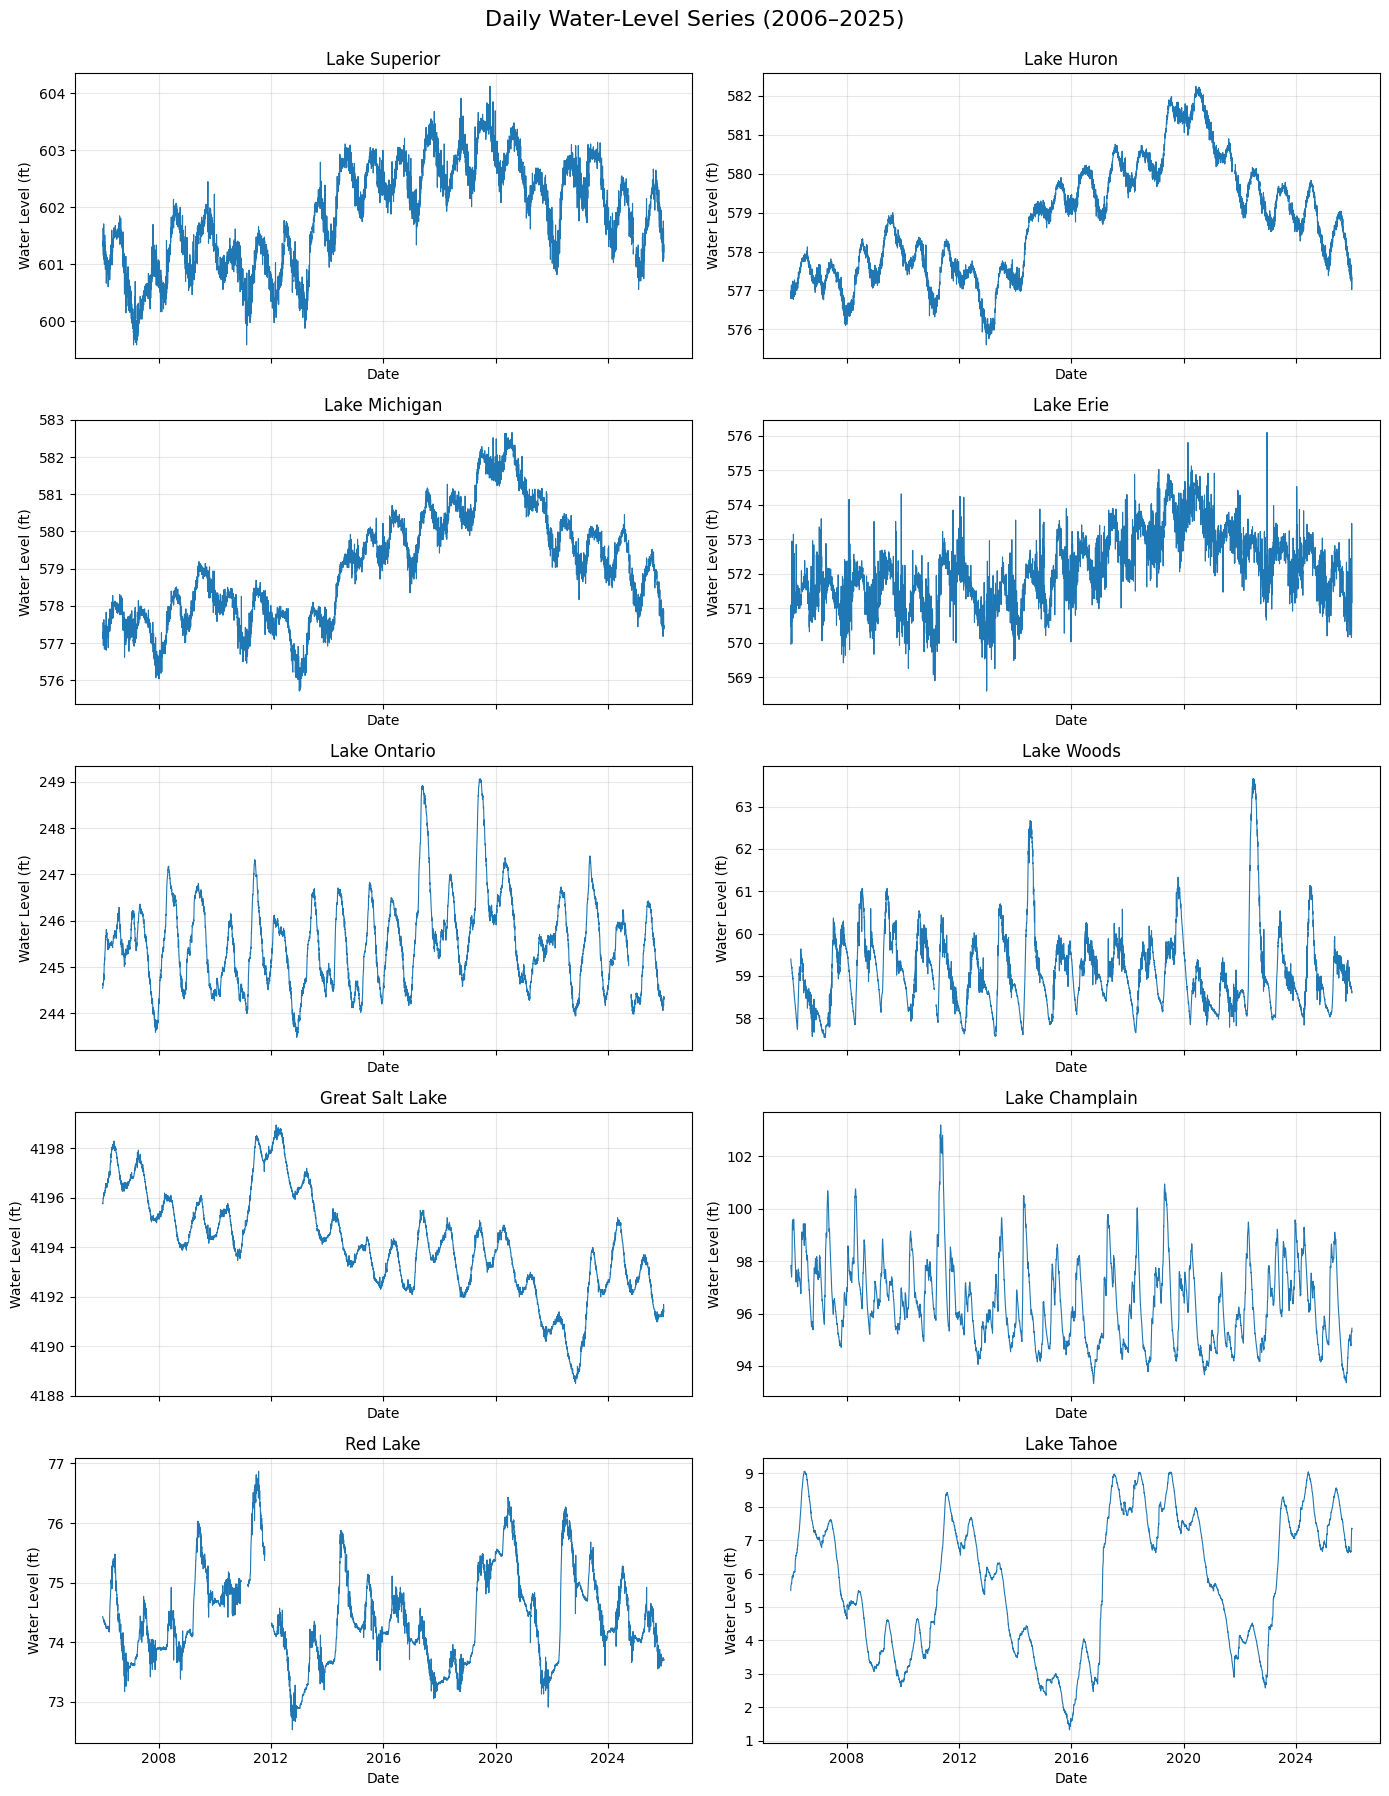

In [44]:
# Plot daily water-level time series for all lakes

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    sharex=True
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = eda_data[
        eda_data["Lake"] == lake
    ]

    ax.plot(
        temp["Date"],
        temp["Lake_Level_ft"],
        linewidth=0.8
    )

    ax.set_title(lake)
    ax.set_ylabel("Water Level (ft)")
    ax.grid(alpha=0.3)


for ax in axes:
    ax.set_xlabel("Date")


fig.suptitle(
    "Daily Water-Level Series (2006–2025)",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.show()

#### [4]Annual Water-Level Patterns

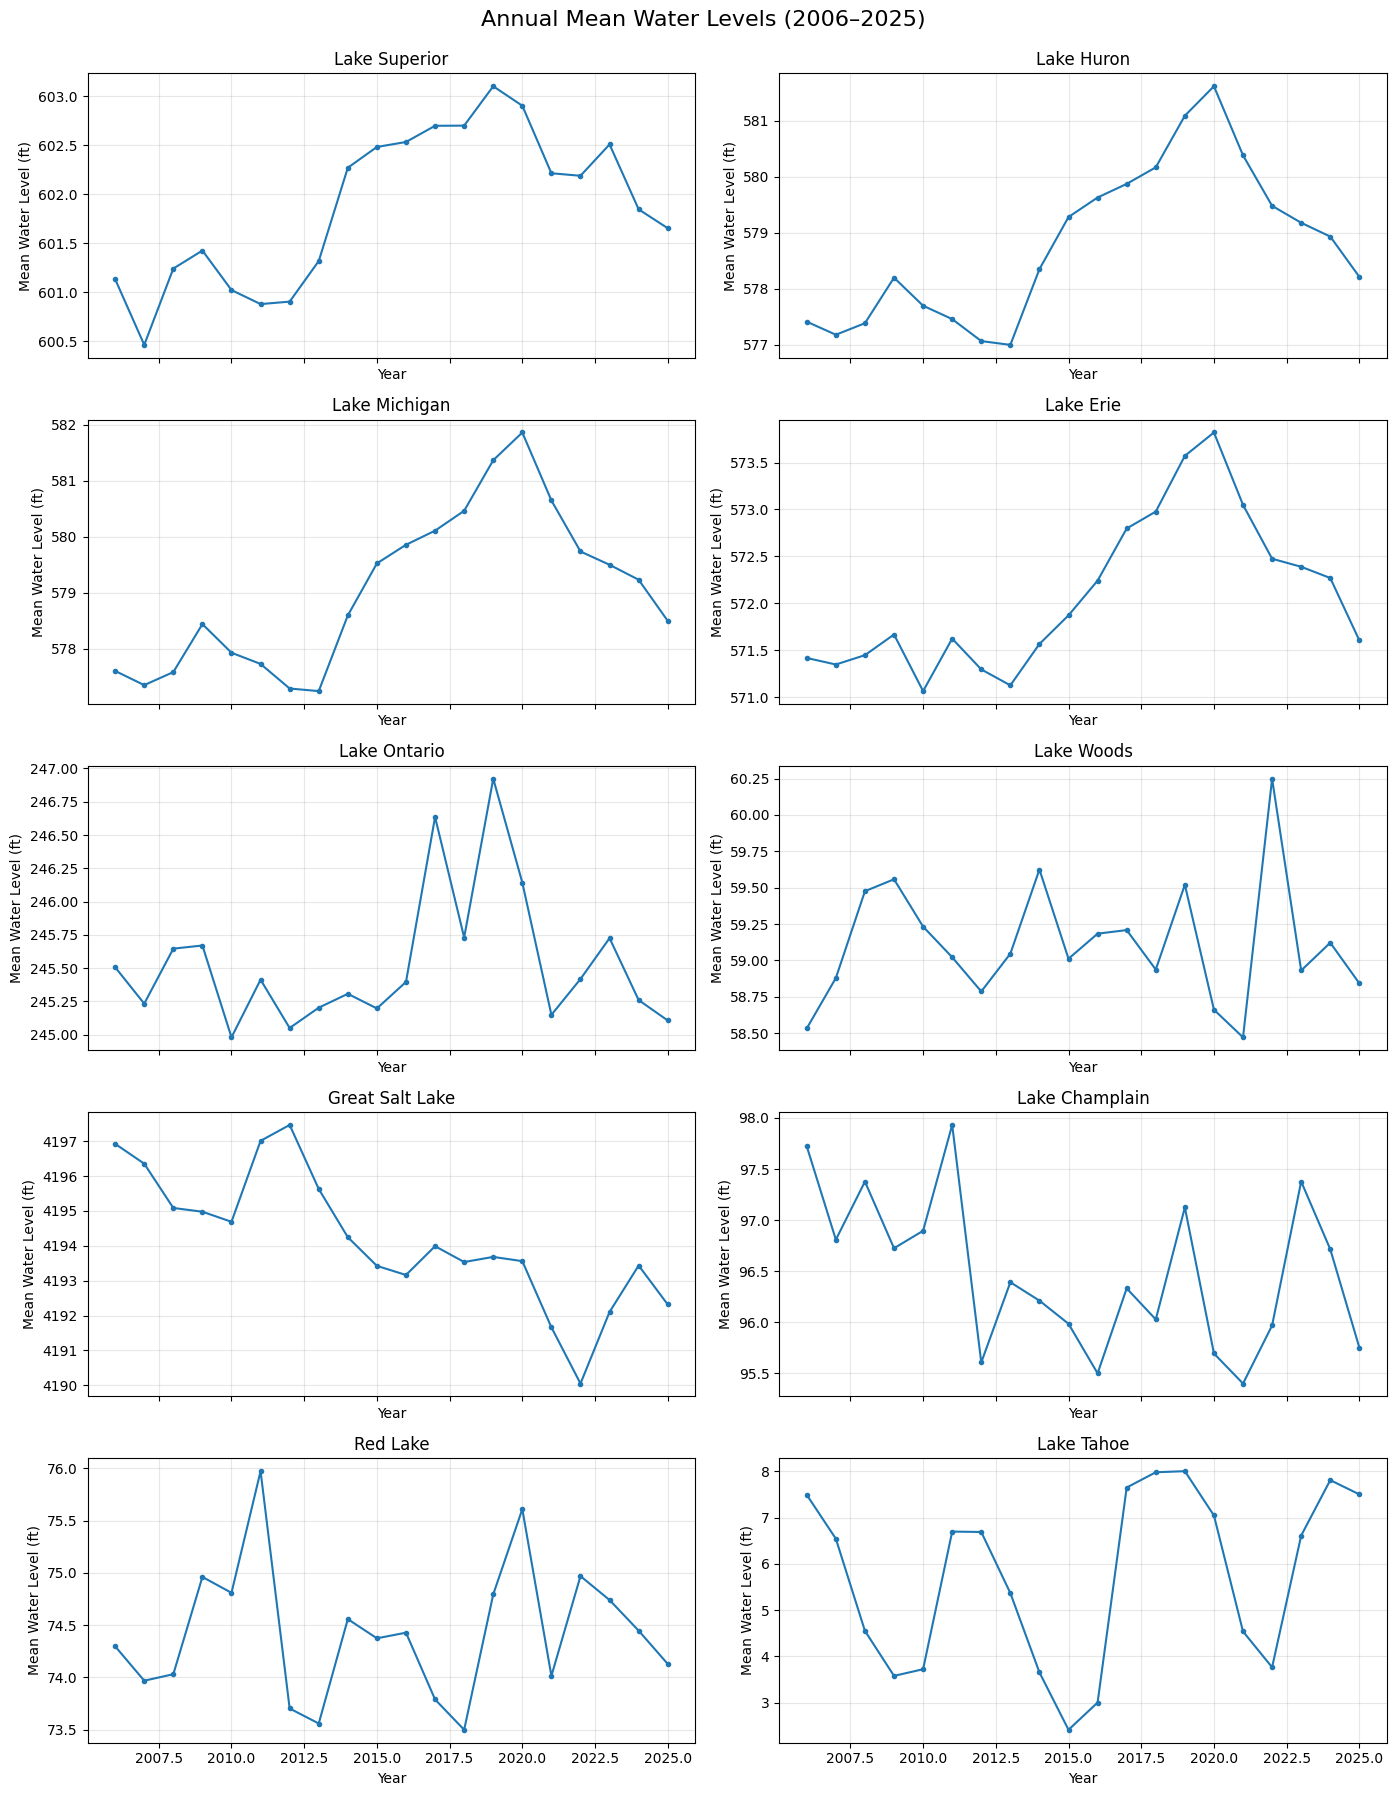

In [45]:
annual_mean = (
    eda_data
    .groupby(
        ["Lake", "Year"],
        observed=True
    )["Lake_Level_ft"]
    .mean()
    .reset_index()
)


fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    sharex=True
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = annual_mean[
        annual_mean["Lake"] == lake
    ]

    ax.plot(
        temp["Year"],
        temp["Lake_Level_ft"],
        marker="o",
        markersize=3
    )

    ax.set_title(lake)
    ax.set_ylabel("Mean Water Level (ft)")
    ax.grid(alpha=0.3)


for ax in axes:
    ax.set_xlabel("Year")


fig.suptitle(
    "Annual Mean Water Levels (2006–2025)",
    fontsize=16,
    y=0.995
)


plt.savefig(
    "Figure_Annual_Mean_Water_Levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

#### [5]Monthly Seasonal Patterns

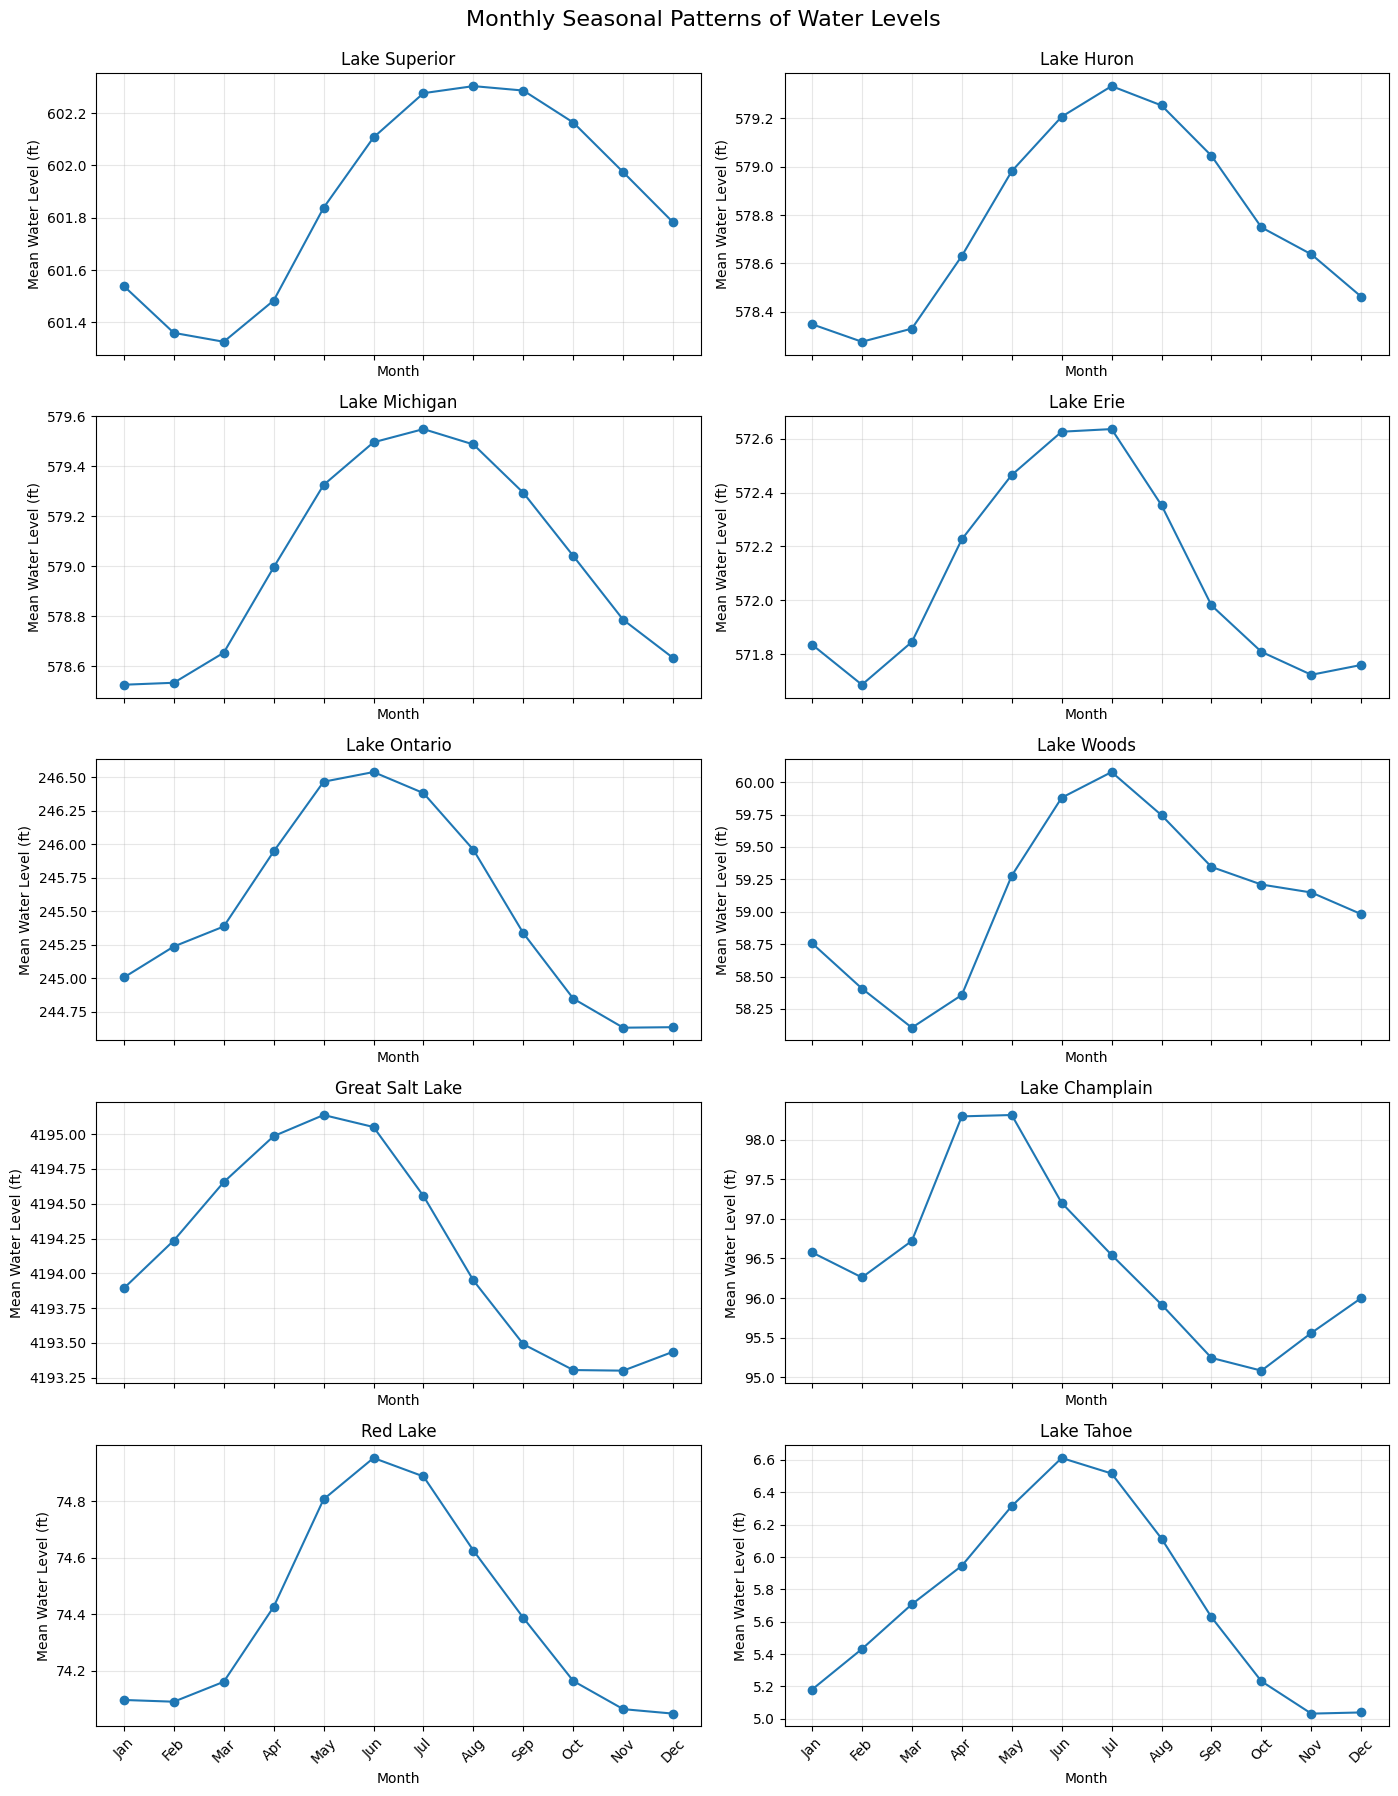

In [46]:
# Calculate monthly mean water levels across the study period

monthly_mean = (
    eda_data
    .groupby(
        ["Lake", "Month"],
        observed=True
    )["Lake_Level_ft"]
    .mean()
    .reset_index()
)


month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    sharex=True
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = monthly_mean[
        monthly_mean["Lake"] == lake
    ]

    ax.plot(
        temp["Month"],
        temp["Lake_Level_ft"],
        marker="o"
    )

    ax.set_title(lake)
    ax.set_ylabel("Mean Water Level (ft)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(
        month_labels,
        rotation=45
    )
    ax.grid(alpha=0.3)


for ax in axes:
    ax.set_xlabel("Month")


fig.suptitle(
    "Monthly Seasonal Patterns of Water Levels",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

plt.savefig(
    "Figure_Monthly_Seasonal_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### [6]Monthly Water-Level Variability

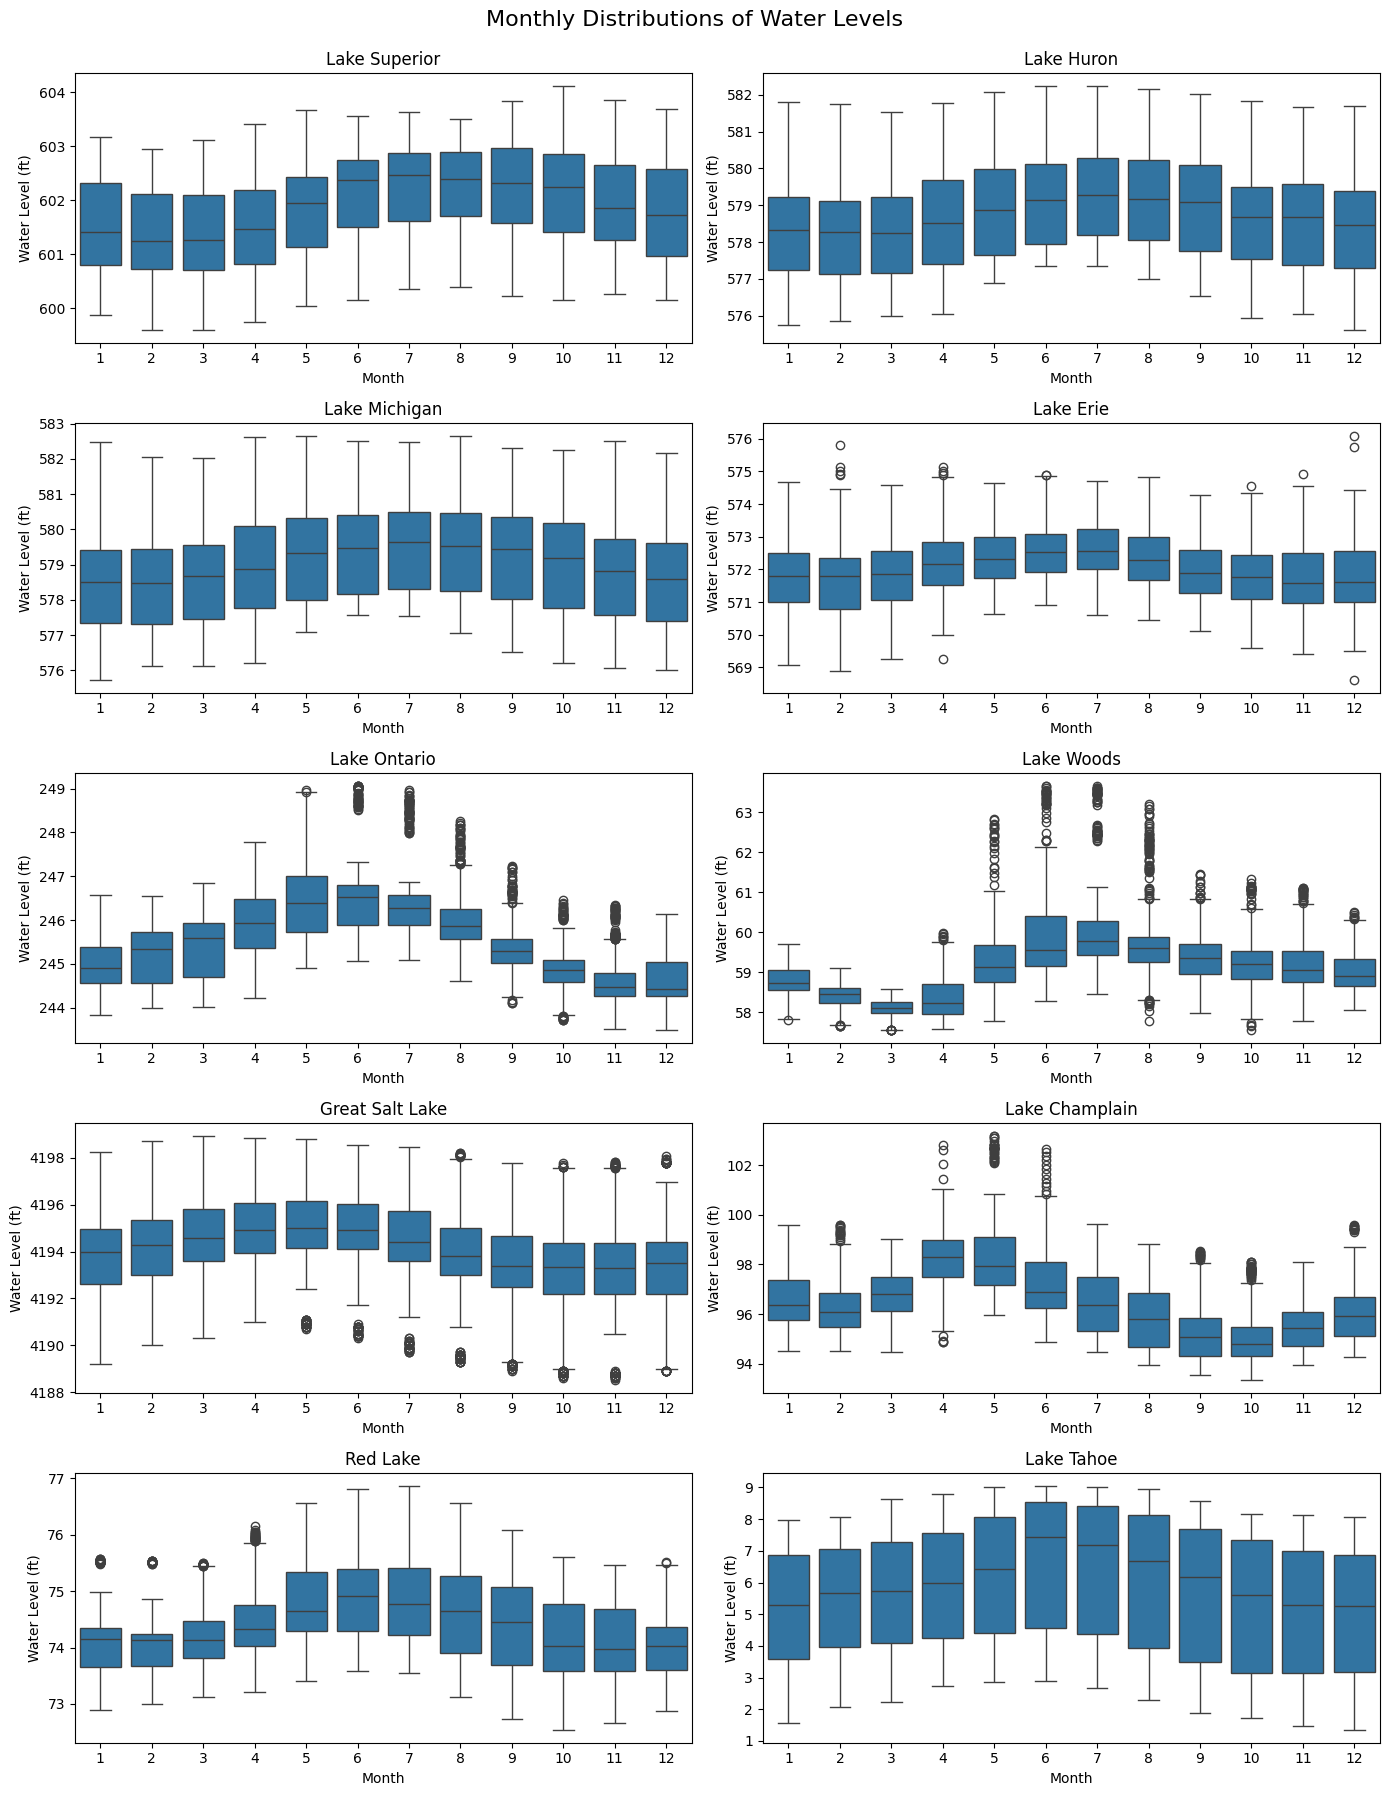

In [47]:
# Compare monthly water-level distributions

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18)
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = eda_data[
        eda_data["Lake"] == lake
    ]

    sns.boxplot(
        data=temp,
        x="Month",
        y="Lake_Level_ft",
        ax=ax
    )

    ax.set_title(lake)
    ax.set_xlabel("Month")
    ax.set_ylabel("Water Level (ft)")


fig.suptitle(
    "Monthly Distributions of Water Levels",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.show()

#### [7]Overall Water-Level Distributions

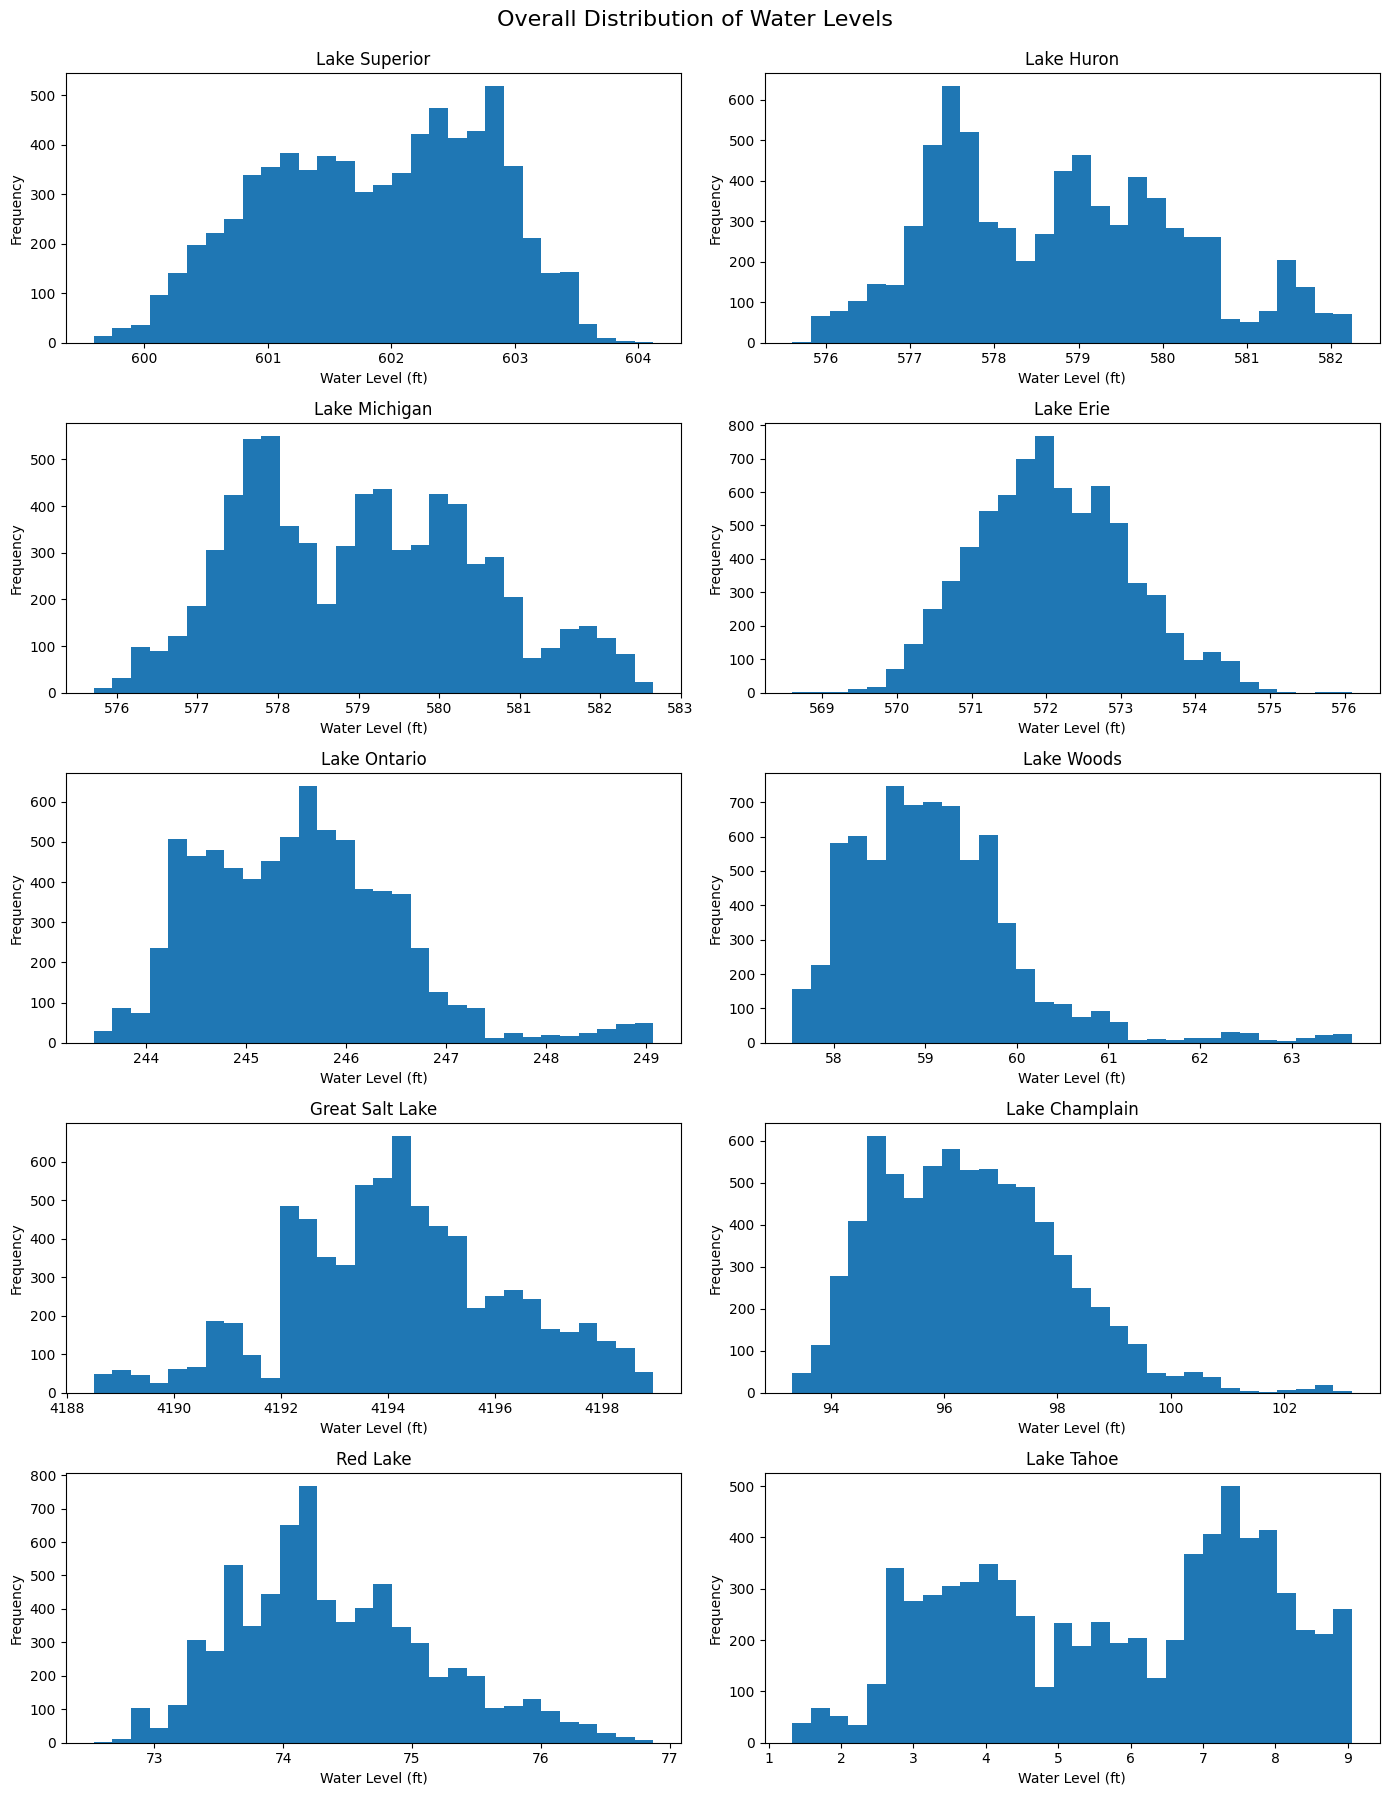

In [48]:
# Plot overall water-level distributions

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18)
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = eda_data[
        eda_data["Lake"] == lake
    ]

    ax.hist(
        temp["Lake_Level_ft"].dropna(),
        bins=30
    )

    ax.set_title(lake)
    ax.set_xlabel("Water Level (ft)")
    ax.set_ylabel("Frequency")


fig.suptitle(
    "Overall Distribution of Water Levels",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.savefig(
    "Figure_Overall_Distribution_Water_Levels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### (2)Meteorological Data EDA

#### [1]Descriptive Statistics

In [49]:
# Calculate descriptive statistics for the main meteorological variables

climate_descriptive = (
    eda_data
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        PRCP_Count=("PRCP", "count"),
        PRCP_Mean=("PRCP", "mean"),
        PRCP_SD=("PRCP", "std"),
        PRCP_Median=("PRCP", "median"),
        PRCP_Max=("PRCP", "max"),
        TMEAN_Count=("TMEAN", "count"),
        TMEAN_Mean=("TMEAN", "mean"),
        TMEAN_SD=("TMEAN", "std"),
        TMEAN_Min=("TMEAN", "min"),
        TMEAN_Max=("TMEAN", "max")
    )
    .reindex(lake_order)
    .round(2)
)

display(climate_descriptive)

,PRCP_Count,PRCP_Mean,PRCP_SD,PRCP_Median,PRCP_Max,TMEAN_Count,TMEAN_Mean,TMEAN_SD,TMEAN_Min,TMEAN_Max
Lake,,,,,,,,,,
Lake Superior,7305,2.09,6.02,0.0,105.2,7305,5.08,12.16,-29.90,29.70
Lake Huron,7296,2.05,5.40,0.0,94.2,7305,6.44,10.73,-26.85,29.15
Lake Michigan,7305,2.50,7.32,0.0,145.8,7305,9.75,10.73,-26.00,33.05
Lake Erie,7305,2.86,6.43,0.0,90.2,7305,9.98,10.24,-19.90,30.25
Lake Ontario,7305,2.46,5.99,0.0,84.6,7305,9.97,10.17,-19.05,30.00
Lake Woods,7256,1.42,4.93,0.0,102.6,7271,4.24,13.32,-33.75,28.05
Great Salt Lake,7303,1.04,3.17,0.0,62.7,7305,12.75,10.59,-14.35,33.90
Lake Champlain,7305,2.75,6.57,0.0,85.9,7305,8.98,11.07,-22.75,31.40
Red Lake,7067,1.59,5.51,0.0,89.2,6787,4.36,13.78,-34.45,30.55


#### [2]Monthly Meteorological Patterns

##### 1.Monthly Precipitation Patterns

In [50]:
# Assess monthly PRCP coverage relative to the expected number of days

monthly_prcp_coverage = (
    eda_data
    .groupby(
        ["Lake", "Month"],
        observed=True
    )
    .agg(
        Expected_Days=("Date", "count"),
        Available_PRCP_Days=("PRCP", "count")
    )
    .reset_index()
)


monthly_prcp_coverage["Coverage_Percent"] = (
    monthly_prcp_coverage["Available_PRCP_Days"]
    / monthly_prcp_coverage["Expected_Days"]
    * 100
)


# Summarise the lowest monthly PRCP coverage for each lake

prcp_coverage_summary = (
    monthly_prcp_coverage
    .groupby(
        "Lake",
        observed=True
    )
    .agg(
        Minimum_Coverage_Percent=(
            "Coverage_Percent",
            "min"
        ),
        Mean_Coverage_Percent=(
            "Coverage_Percent",
            "mean"
        )
    )
    .reindex(lake_order)
    .round(2)
)

display(prcp_coverage_summary)

,Minimum_Coverage_Percent,Mean_Coverage_Percent
Lake,,
Lake Superior,100.00,100.00
Lake Huron,99.52,99.88
Lake Michigan,100.00,100.00
Lake Erie,100.00,100.00
Lake Ontario,100.00,100.00
Lake Woods,98.67,99.33
Great Salt Lake,99.84,99.97
Lake Champlain,100.00,100.00
Red Lake,85.67,96.75


In [51]:
# Identify the calendar month with the lowest PRCP coverage for each lake

lowest_prcp_coverage = (
    monthly_prcp_coverage
    .sort_values(
        ["Lake", "Coverage_Percent"]
    )
    .groupby(
        "Lake",
        observed=True
    )
    .first()
    .reset_index()
)

lowest_prcp_coverage["Month_Name"] = (
    lowest_prcp_coverage["Month"]
    .map(
        dict(
            zip(
                range(1, 13),
                month_labels
            )
        )
    )
)


lowest_prcp_coverage = (
    lowest_prcp_coverage[
        [
            "Lake",
            "Month_Name",
            "Expected_Days",
            "Available_PRCP_Days",
            "Coverage_Percent"
        ]
    ]
    .set_index("Lake")
    .reindex(lake_order)
)

display(
    lowest_prcp_coverage.round(2)
)

,Month_Name,Expected_Days,Available_PRCP_Days,Coverage_Percent
Lake,,,,
Lake Superior,Jan,620,620,100.00
Lake Huron,Mar,620,617,99.52
Lake Michigan,Jan,620,620,100.00
Lake Erie,Jan,620,620,100.00
Lake Ontario,Jan,620,620,100.00
Lake Woods,Sep,600,592,98.67
Great Salt Lake,Jan,620,619,99.84
Lake Champlain,Jan,620,620,100.00
Red Lake,Sep,600,514,85.67


In [52]:
# Calculate monthly mean meteorological patterns

climate_monthly = (
    climate_complete
    .assign(
        Month=climate_complete["Date"].dt.month
    )
    .groupby(
        ["Lake", "Month"],
        observed=True
    )
    .agg(
        Mean_PRCP=("PRCP", "mean"),
        Mean_TMEAN=("TMEAN", "mean")
    )
    .reset_index()
)


# Add month names for easier interpretation
month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

climate_monthly["Month_Name"] = (
    climate_monthly["Month"]
    .map(month_names)
)


# Identify the coldest month for each lake

coldest_idx = (
    climate_monthly
    .groupby("Lake", observed=True)["Mean_TMEAN"]
    .idxmin()
)

coldest_month = (
    climate_monthly
    .loc[
        coldest_idx,
        ["Lake", "Month_Name", "Mean_TMEAN"]
    ]
    .rename(
        columns={
            "Month_Name": "Coldest_Month",
            "Mean_TMEAN": "Lowest_Monthly_Mean_Temperature"
        }
    )
    .reset_index(drop=True)
)

# Identify the warmest month for each lake

warmest_idx = (
    climate_monthly
    .groupby("Lake", observed=True)["Mean_TMEAN"]
    .idxmax()
)

warmest_month = (
    climate_monthly
    .loc[
        warmest_idx,
        ["Lake", "Month_Name", "Mean_TMEAN"]
    ]
    .rename(
        columns={
            "Month_Name": "Warmest_Month",
            "Mean_TMEAN": "Highest_Monthly_Mean_Temperature"
        }
    )
    .reset_index(drop=True)
)


# Identify the month with the highest mean daily precipitation

wettest_idx = (
    climate_monthly
    .groupby("Lake", observed=True)["Mean_PRCP"]
    .idxmax()
)

wettest_month = (
    climate_monthly
    .loc[
        wettest_idx,
        ["Lake", "Month_Name", "Mean_PRCP"]
    ]
    .rename(
        columns={
            "Month_Name": "Wettest_Month",
            "Mean_PRCP": "Highest_Monthly_Mean_Daily_PRCP"
        }
    )
    .reset_index(drop=True)
)


# Combine seasonal summaries

monthly_seasonal_summary = (
    coldest_month
    .merge(
        warmest_month,
        on="Lake"
    )
    .merge(
        wettest_month,
        on="Lake"
    )
)


# Restore the study lake order

monthly_seasonal_summary["Lake"] = pd.Categorical(
    monthly_seasonal_summary["Lake"],
    categories=lake_order,
    ordered=True
)

monthly_seasonal_summary = (
    monthly_seasonal_summary
    .sort_values("Lake")
    .reset_index(drop=True)
)

display(monthly_seasonal_summary)

,Lake,Coldest_Month,Lowest_Monthly_Mean_Temperature,Warmest_Month,Highest_Monthly_Mean_Temperature,Wettest_Month,Highest_Monthly_Mean_Daily_PRCP
0,Lake Superior,Jan,-10.982903,Jul,19.946048,Jun,3.584500
1,Lake Huron,Feb,-7.681327,Jul,19.354597,Oct,3.840484
2,Lake Michigan,Jan,-4.204597,Jul,22.998629,Jun,3.670667
3,Lake Erie,Jan,-2.947581,Jul,22.596048,Oct,3.896129
4,Lake Ontario,Jan,-2.885887,Jul,22.532177,Jul,3.358548
5,Lake Woods,Jan,-13.290081,Jul,19.874194,Jun,2.813356
6,Great Salt Lake,Jan,-0.738427,Jul,28.024919,Apr,1.621167
7,Lake Champlain,Jan,-5.465565,Jul,22.672419,Jun,3.986167
8,Red Lake,Jan,-13.613243,Jul,20.726321,Jun,3.383392
9,Lake Tahoe,Dec,0.369274,Jul,17.910565,Dec,5.925806


In [53]:
monthly_prcp = (
    eda_data
    .groupby(
        ["Lake", "Month"],
        observed=True
    )["PRCP"]
    .mean()
    .reset_index()
)

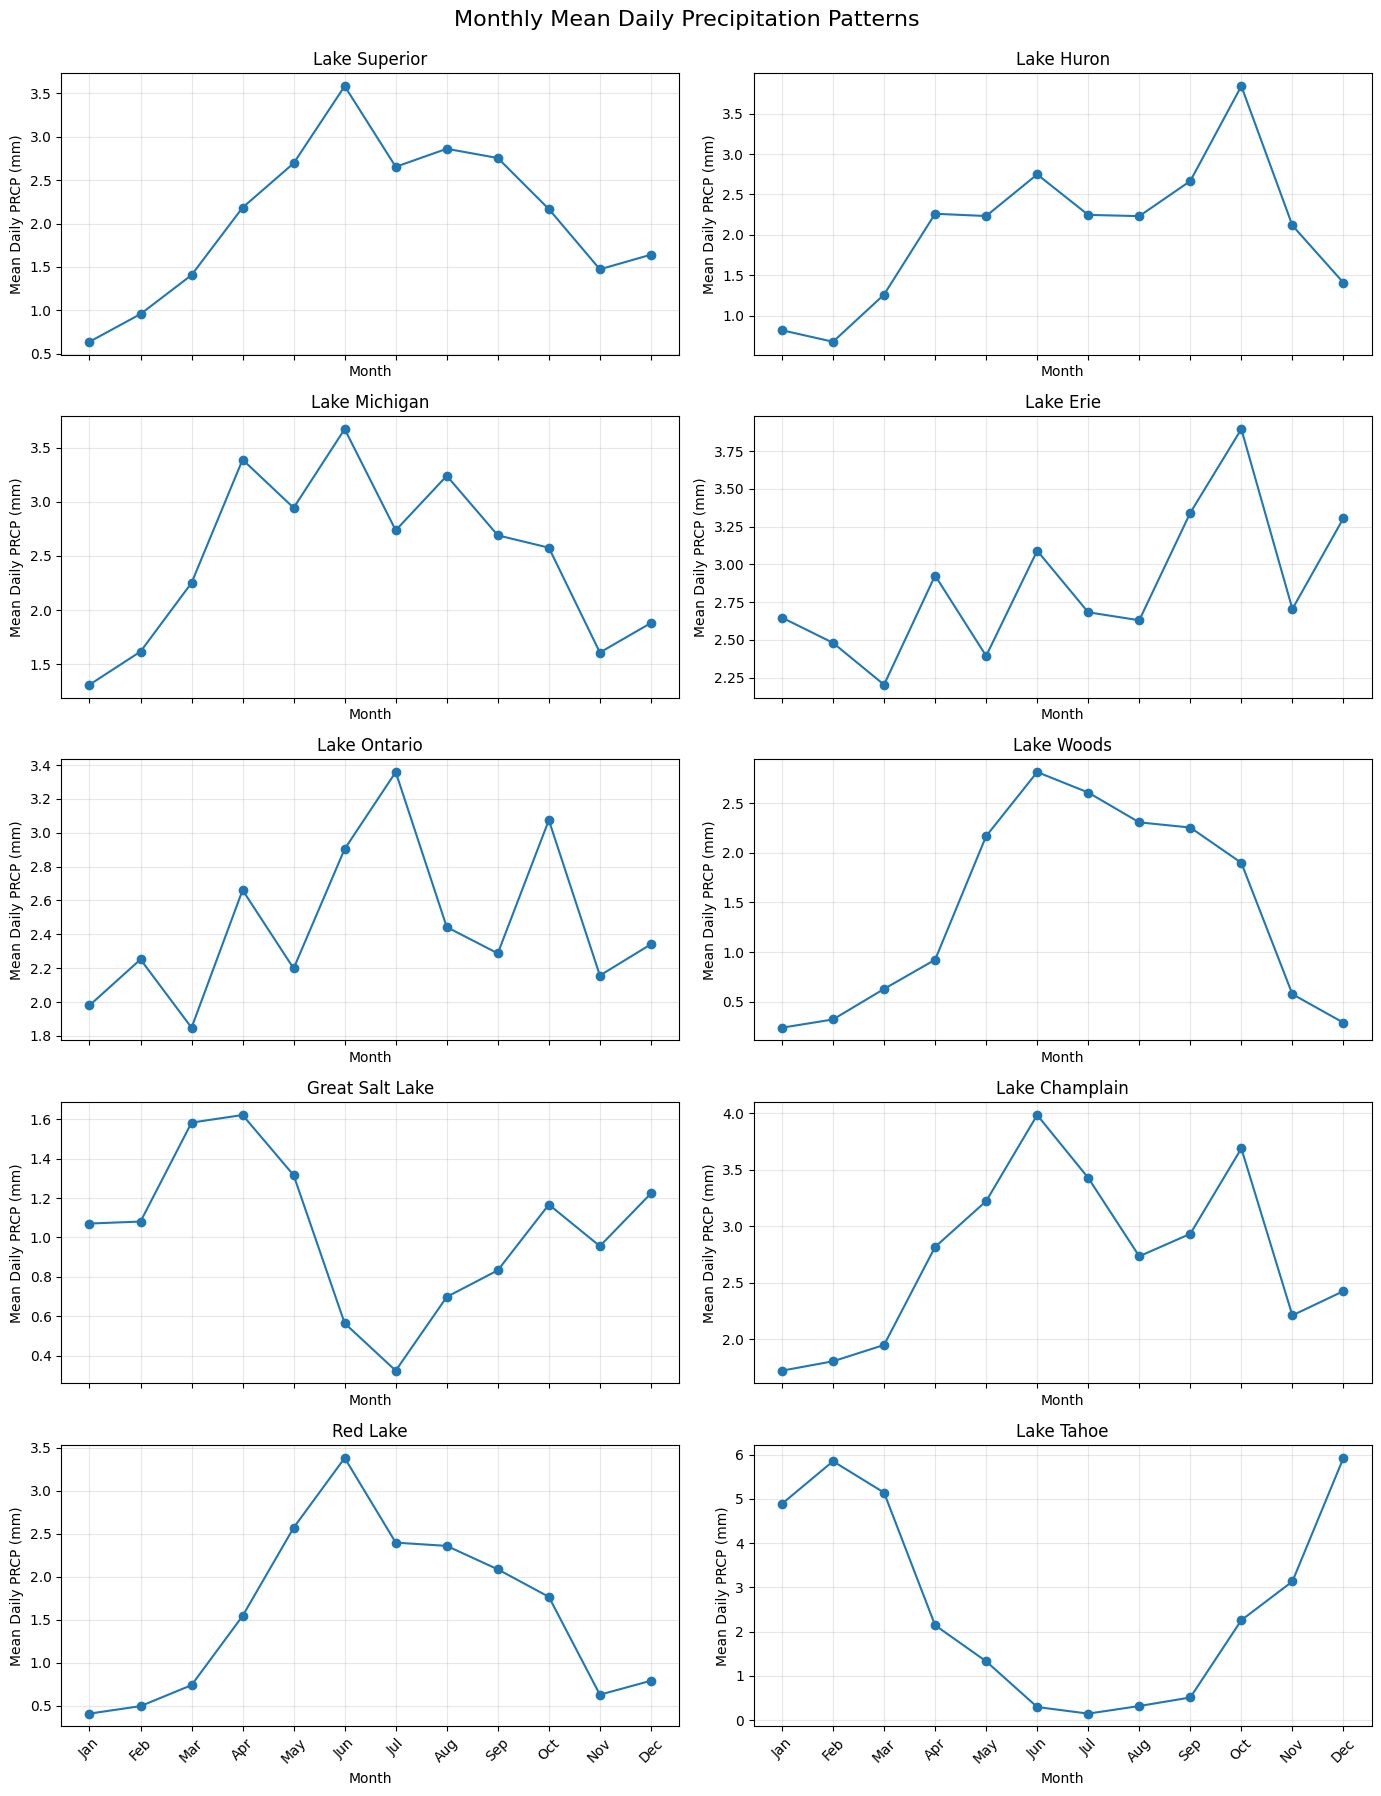

In [54]:
# Plot monthly precipitation patterns

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    sharex=True
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = monthly_prcp[
        monthly_prcp["Lake"] == lake
    ]

    ax.plot(
        temp["Month"],
        temp["PRCP"],
        marker="o"
    )

    ax.set_title(lake)
    ax.set_ylabel("Mean Daily PRCP (mm)")

    ax.set_xticks(
        range(1, 13)
    )

    ax.set_xticklabels(
        month_labels,
        rotation=45
    )

    ax.grid(alpha=0.3)


for ax in axes:
    ax.set_xlabel("Month")


fig.suptitle(
    "Monthly Mean Daily Precipitation Patterns",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.savefig(
    "Figure_Monthly_Mean_Daily_Precipitation_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

##### 2.Monthly Temperature Patterns

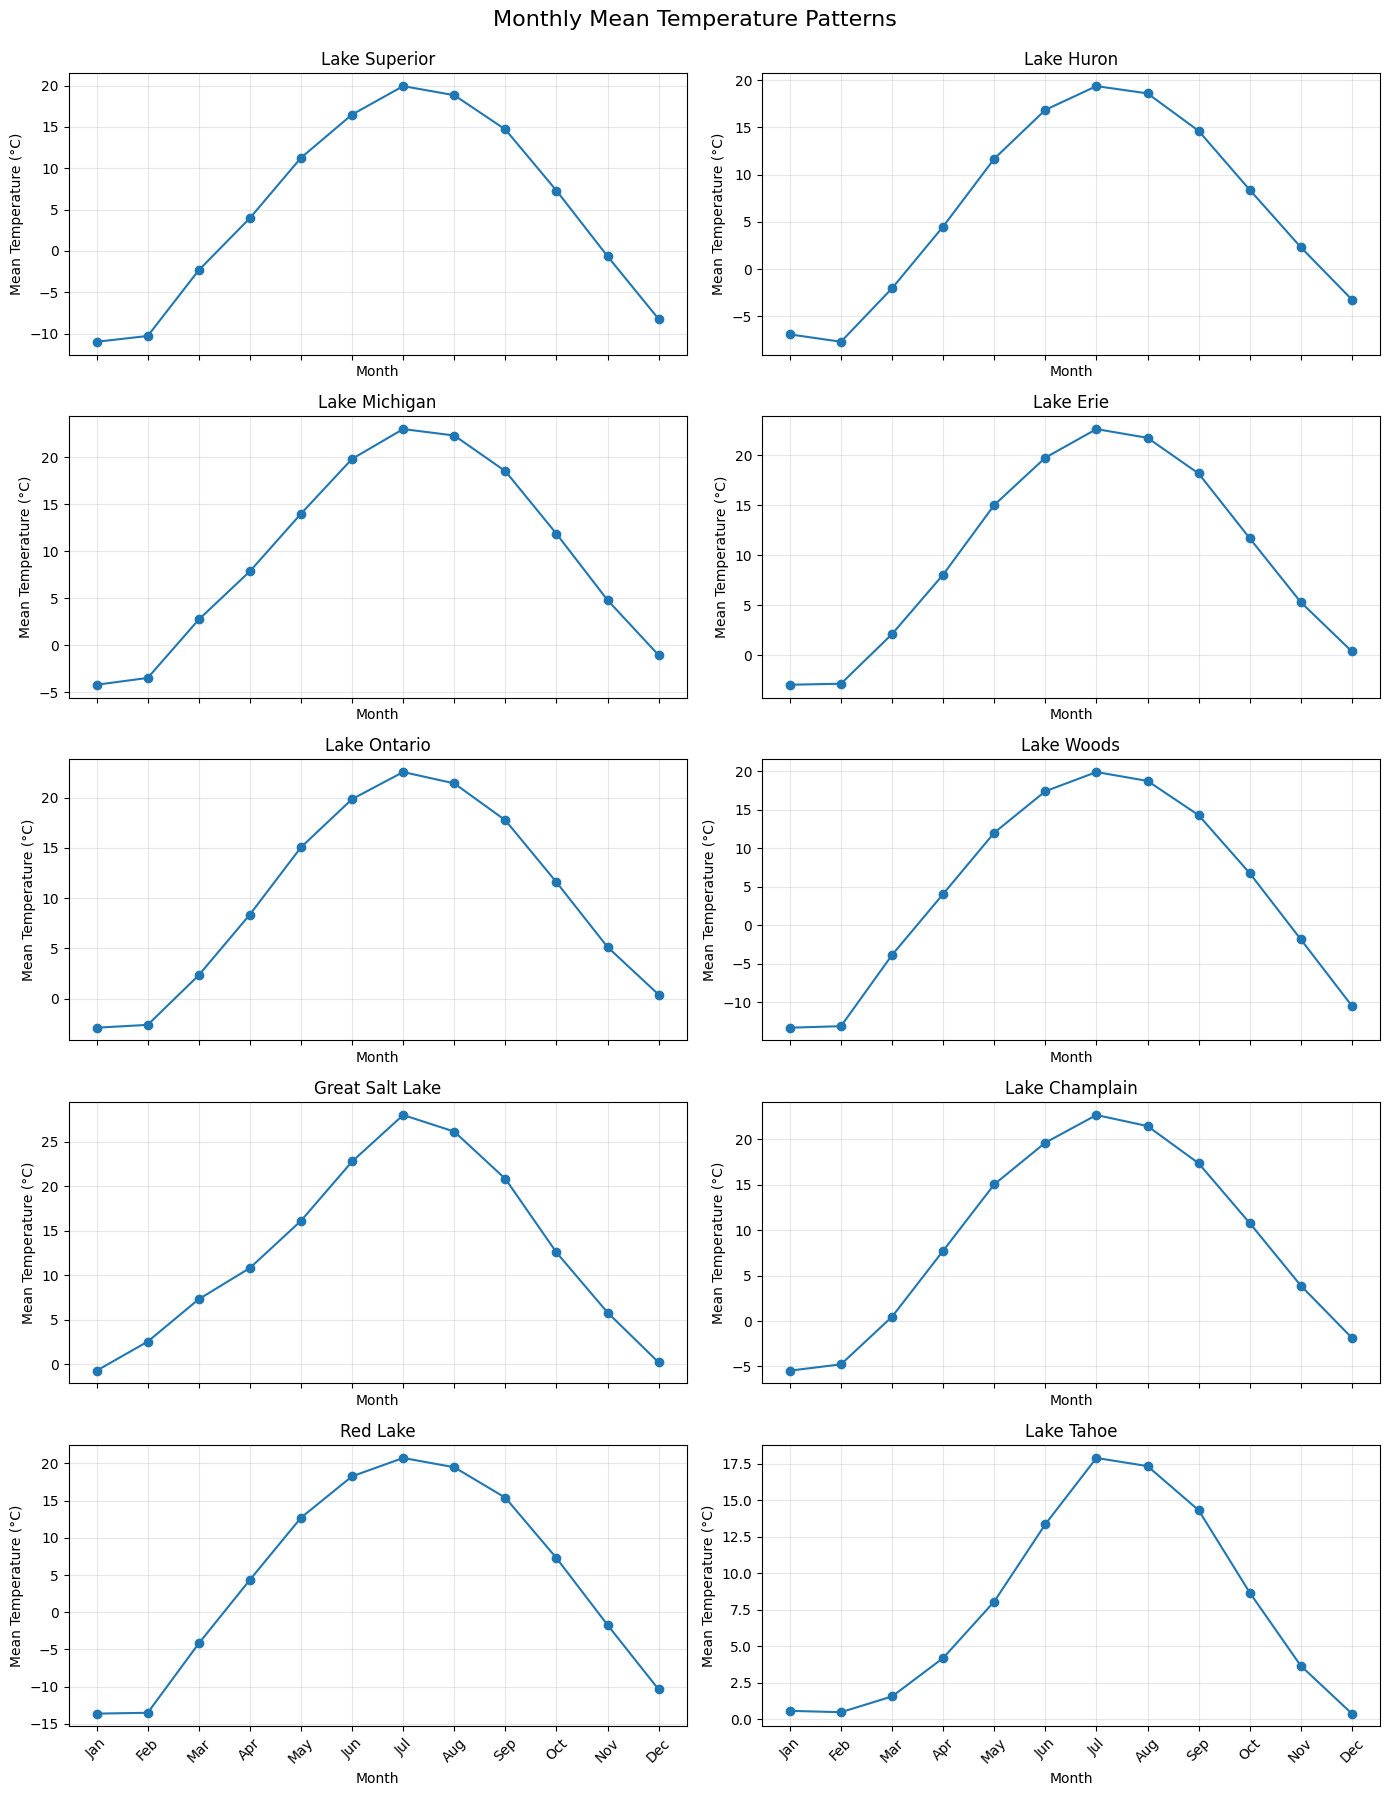

In [55]:
# Calculate mean daily temperature for each calendar month

monthly_tmean = (
    eda_data
    .groupby(
        ["Lake", "Month"],
        observed=True
    )["TMEAN"]
    .mean()
    .reset_index()
)

# Plot monthly temperature patterns

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    sharex=True
)

axes = axes.flatten()


for ax, lake in zip(axes, lake_order):

    temp = monthly_tmean[
        monthly_tmean["Lake"] == lake
    ]

    ax.plot(
        temp["Month"],
        temp["TMEAN"],
        marker="o"
    )

    ax.set_title(lake)
    ax.set_ylabel("Mean Temperature (°C)")

    ax.set_xticks(
        range(1, 13)
    )

    ax.set_xticklabels(
        month_labels,
        rotation=45
    )

    ax.grid(alpha=0.3)


for ax in axes:
    ax.set_xlabel("Month")


fig.suptitle(
    "Monthly Mean Temperature Patterns",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.savefig(
    "Figure_Monthly_Mean_Temperature_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### [3]Meteorological Variable Distributions

##### 1.Precipitation Distribution

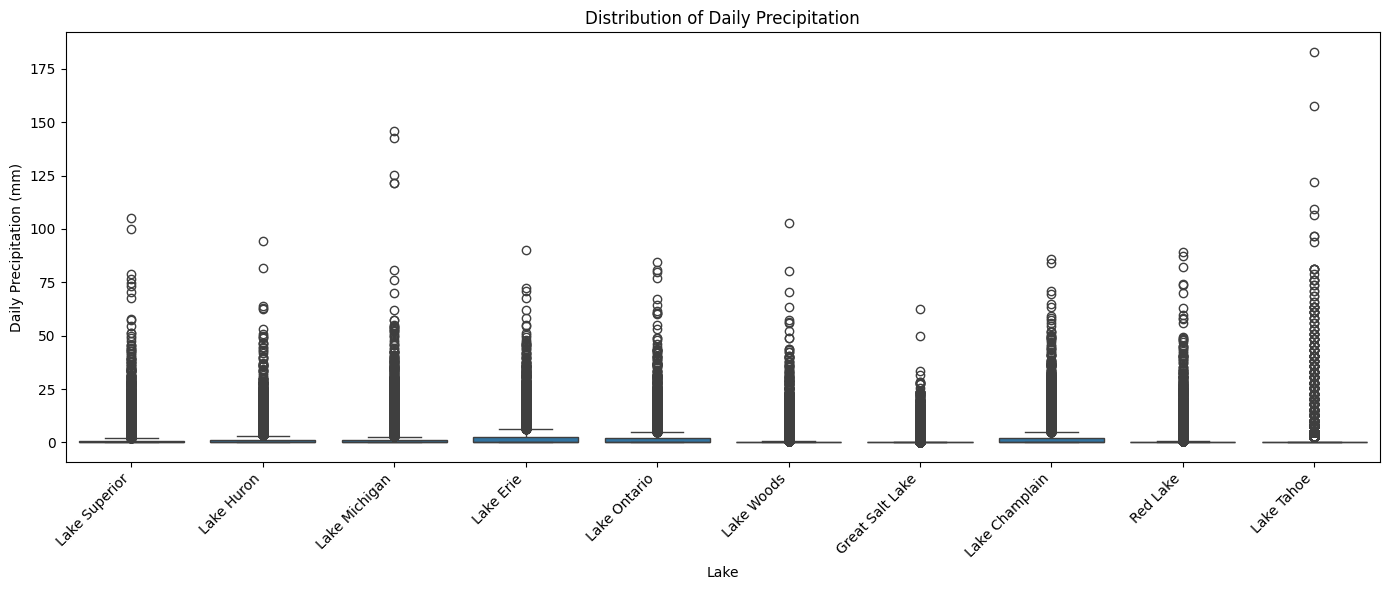

In [56]:
# Compare daily precipitation distributions across lakes

plt.figure(
    figsize=(14, 6)
)

sns.boxplot(
    data=eda_data,
    x="Lake",
    y="PRCP",
    order=lake_order
)

plt.xlabel("Lake")
plt.ylabel("Daily Precipitation (mm)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Distribution of Daily Precipitation"
)

plt.tight_layout()
plt.show()

##### 2.Temperature Distribution

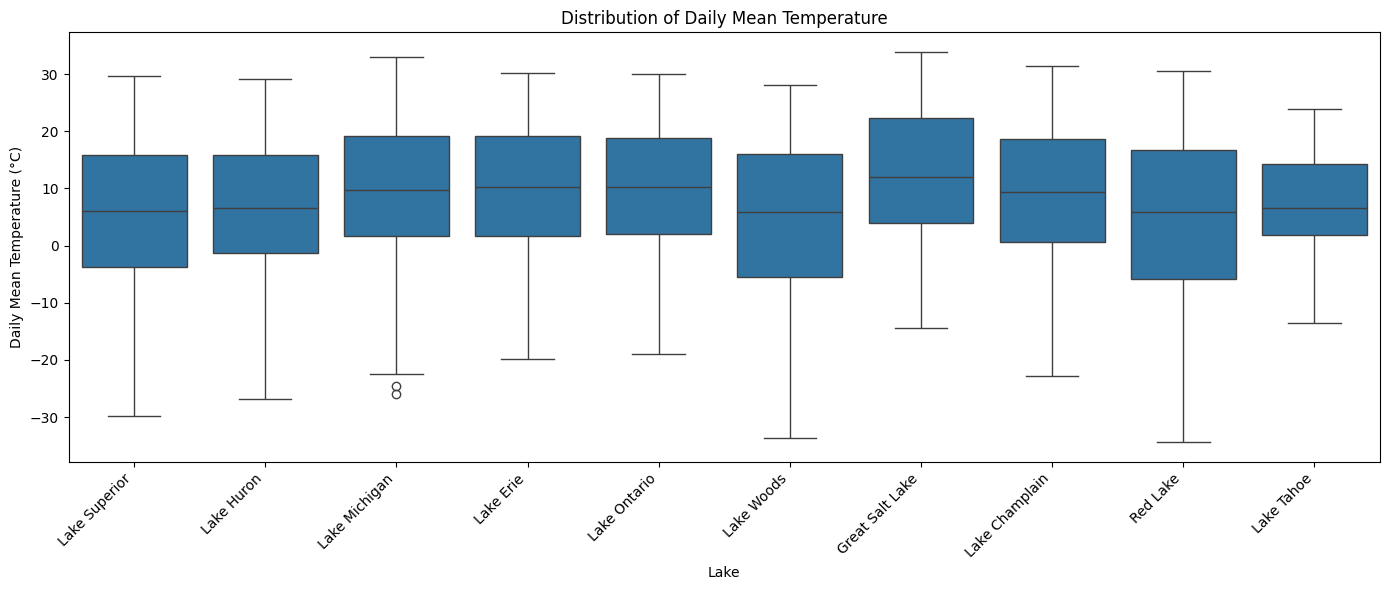

In [57]:
# Compare daily mean temperature distributions across lakes

plt.figure(
    figsize=(14, 6)
)

sns.boxplot(
    data=eda_data,
    x="Lake",
    y="TMEAN",
    order=lake_order
)

plt.xlabel("Lake")
plt.ylabel("Daily Mean Temperature (°C)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Distribution of Daily Mean Temperature"
)

plt.tight_layout()
plt.show()

## 6.Climate-Water-Level Relationships

### (1) Scatter Plots
Explore relationships between water level and climate variables.

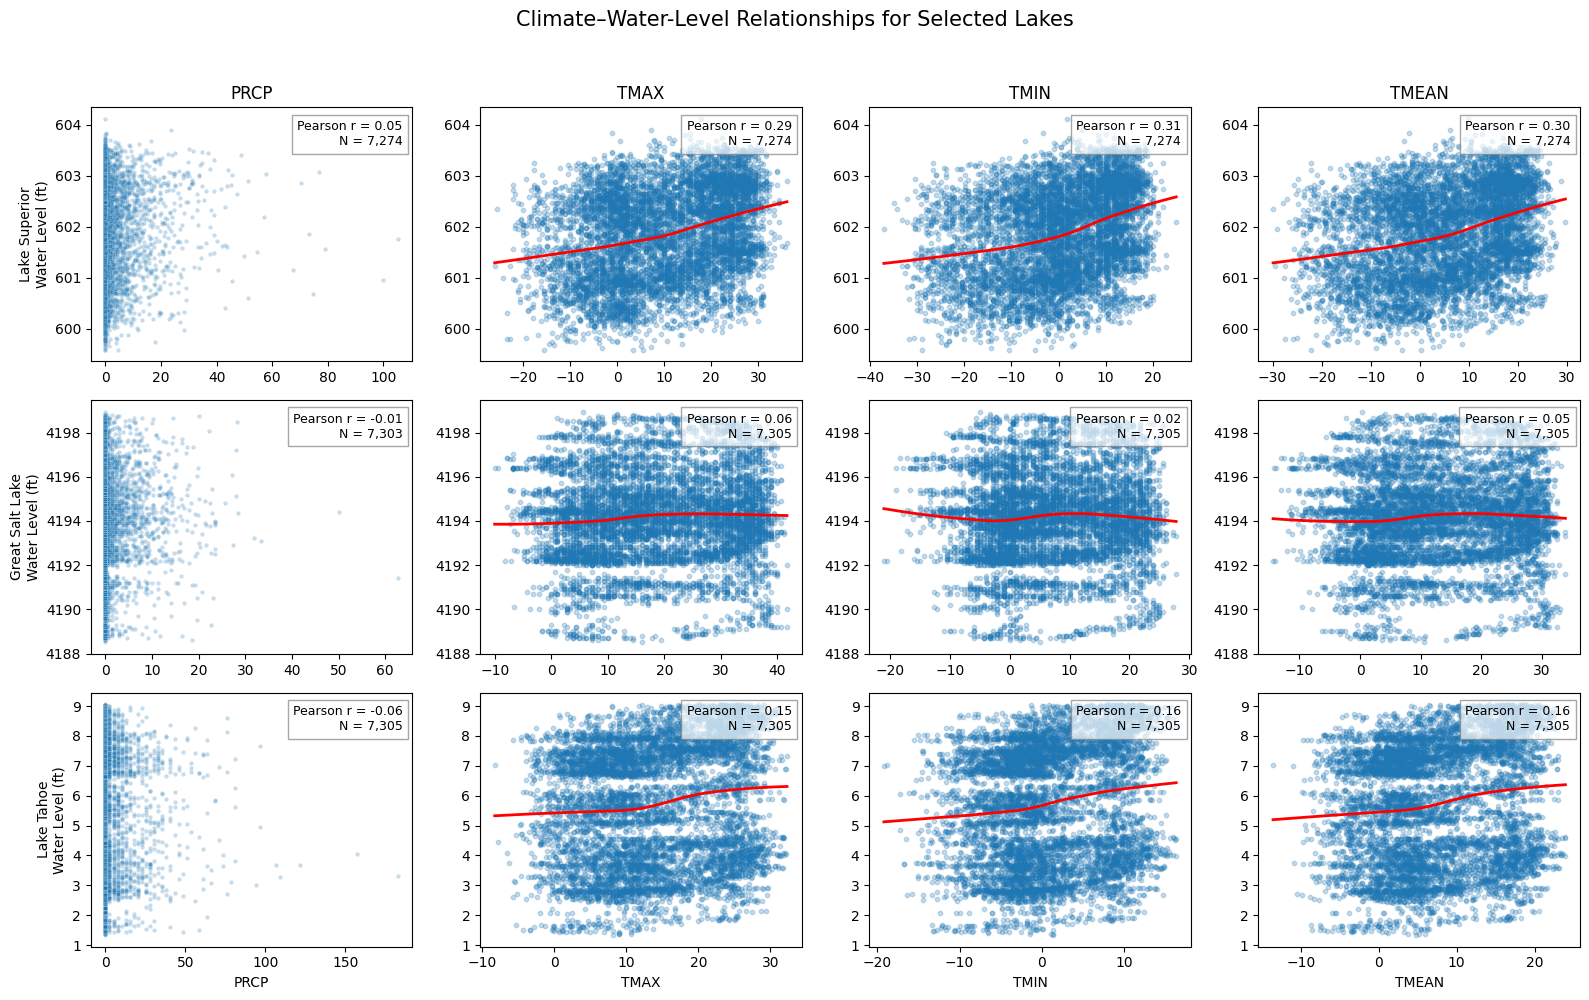

In [58]:
# Visualise climate-water-level relationships for illustrative lakes

selected_lakes = [
    "Lake Superior",
    "Great Salt Lake",
    "Lake Tahoe"
]

climate_variables = [
    "PRCP",
    "TMAX",
    "TMIN",
    "TMEAN"
]


# Create one combined figure:
# rows = lakes, columns = climate variables
fig, axes = plt.subplots(
    nrows=len(selected_lakes),
    ncols=len(climate_variables),
    figsize=(16, 10)
)


for row, lake in enumerate(selected_lakes):

    lake_df = (
        water_climate[
            water_climate["Lake"] == lake
        ]
        .sort_values("Date")
        .copy()
    )

    for col, variable in enumerate(climate_variables):

        ax = axes[row, col]

        subset = lake_df[
            [
                "Lake_Level_ft",
                variable
            ]
        ].dropna()

        # Use scatter only for precipitation because of many zero values
        if variable == "PRCP":

            sns.scatterplot(
                data=subset,
                x=variable,
                y="Lake_Level_ft",
                alpha=0.25,
                s=10,
                ax=ax
            )

        else:

            sns.regplot(
                data=subset,
                x=variable,
                y="Lake_Level_ft",
                lowess=True,
                scatter_kws={
                    "alpha": 0.25,
                    "s": 10
                },
                line_kws={
                    "color": "red",
                    "linewidth": 2
                },
                ax=ax
            )

        # Calculate Pearson correlation
        r = subset[
            "Lake_Level_ft"
        ].corr(
            subset[variable],
            method="pearson"
        )

        # Add correlation coefficient and sample size
        ax.text(
            0.97,
            0.95,
            f"Pearson r = {r:.2f}\nN = {len(subset):,}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="gray"
            )
        )

        # Column titles
        if row == 0:
            ax.set_title(
                variable,
                fontsize=12
            )
        else:
            ax.set_title("")

        # X-axis labels only on the bottom row
        if row == len(selected_lakes) - 1:
            ax.set_xlabel(variable)
        else:
            ax.set_xlabel("")

        # Use lake name as the y-axis label for the first column
        if col == 0:
            ax.set_ylabel(
                f"{lake}\nWater Level (ft)"
            )
        else:
            ax.set_ylabel("")


fig.suptitle(
    "Climate–Water-Level Relationships for Selected Lakes",
    fontsize=15,
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

# Save the combined figure
fig.savefig(
    "Figure_Climate_Water_Level_Relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Red lines denote LOWESS fits for temperature variables.

The temperature LOWESS curves indicated approximately monotonic increasing relationships with water level, whereas precipitation scatter plots showed weak and less consistent patterns across lakes.

### (2)Pearson Correlation 
explore linear relationships

In [59]:
# Calculate contemporaneous Pearson correlations
pearson_results = []
pearson_skipped = []

for lake in lake_order:

    lake_df = water_climate[
        water_climate["Lake"] == lake
    ].copy()

    for variable in climate_variables:

        subset = lake_df[
            ["Lake_Level_ft", variable]
        ].dropna()

        if len(subset) <= 10:
            pearson_skipped.append([lake, variable, "Insufficient observations"])
            continue

        if subset["Lake_Level_ft"].nunique() <= 1:
            pearson_skipped.append([lake, variable, "Constant lake level"])
            continue

        if subset[variable].nunique() <= 1:
            pearson_skipped.append([lake, variable, "Constant climate variable"])
            continue


        r = subset[
            "Lake_Level_ft"
        ].corr(
            subset[variable],
            method="pearson"
        )
       
        pearson_results.append({
            "Lake": lake,
            "Climate Variable": variable,
            "N": len(subset),
            "Pearson r": r
        })

pearson_results = pd.DataFrame(pearson_results)

pearson_skipped = pd.DataFrame(
    pearson_skipped,
    columns=["Lake", "Climate Variable", "Reason"]
)

pearson_results

,Lake,Climate Variable,N,Pearson r
0,Lake Superior,PRCP,7274,0.046555
1,Lake Superior,TMAX,7274,0.290891
2,Lake Superior,TMIN,7274,0.310135
3,Lake Superior,TMEAN,7274,0.304427
4,Lake Huron,PRCP,7266,0.055529
5,Lake Huron,TMAX,7275,0.233697
6,Lake Huron,TMIN,7275,0.234360
7,Lake Huron,TMEAN,7275,0.241745
8,Lake Michigan,PRCP,7305,0.048356
9,Lake Michigan,TMAX,7305,0.255083


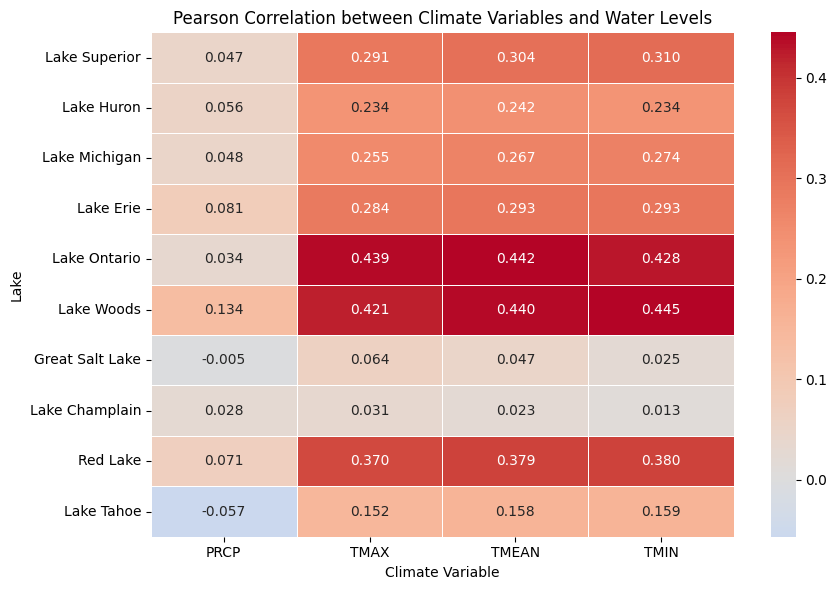

In [60]:
# Heatmap

pearson_matrix = (
    pearson_results.pivot(
        index="Lake",
        columns="Climate Variable",
        values="Pearson r"
    )
    .reindex(lake_order)
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    pearson_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f",
    linewidths=0.5
)

plt.title(
    "Pearson Correlation between Climate Variables and Water Levels"
)

plt.tight_layout()
plt.savefig(
    "Figure_Pearson_Correlation_between_Climate_Variables_and_Water_Levels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

RQ1:
Contemporaneous associations with temperature were generally stronger than those with precipitation, although their magnitude varied considerably among lakes.

### (3)Spearman Correlation 
explore monotonic relationship

In [61]:
spearman_results = []
spearman_skipped = []

for lake in lake_order:

    lake_df = (
        water_climate[
            water_climate["Lake"] == lake
        ]
        .sort_values("Date")
        .copy()
    )

    for variable in climate_variables:

        subset = lake_df[
            ["Lake_Level_ft", variable]
        ].dropna()

        if len(subset) <= 10:
            spearman_skipped.append([lake, variable, "Insufficient observations"])
            continue

        if subset["Lake_Level_ft"].nunique() <= 1:
            spearman_skipped.append([lake, variable, "Constant lake level"])
            continue

        if subset[variable].nunique() <= 1:
            spearman_skipped.append([lake, variable, "Constant climate variable"])
            continue

        rho = subset[
            "Lake_Level_ft"
        ].corr(
            subset[variable],
            method="spearman"
        )

        spearman_results.append({
            "Lake": lake,
            "Climate Variable": variable,
            "N": len(subset),
            "Spearman rho": rho
        })
spearman_results = pd.DataFrame(spearman_results)

spearman_skipped = pd.DataFrame(
    spearman_skipped,
    columns=["Lake", "Climate Variable", "Reason"]
)

spearman_results

,Lake,Climate Variable,N,Spearman rho
0,Lake Superior,PRCP,7274,0.029688
1,Lake Superior,TMAX,7274,0.292148
2,Lake Superior,TMIN,7274,0.321571
3,Lake Superior,TMEAN,7274,0.309518
4,Lake Huron,PRCP,7266,0.021998
5,Lake Huron,TMAX,7275,0.246693
6,Lake Huron,TMIN,7275,0.256202
7,Lake Huron,TMEAN,7275,0.257423
8,Lake Michigan,PRCP,7305,0.028268
9,Lake Michigan,TMAX,7305,0.262373


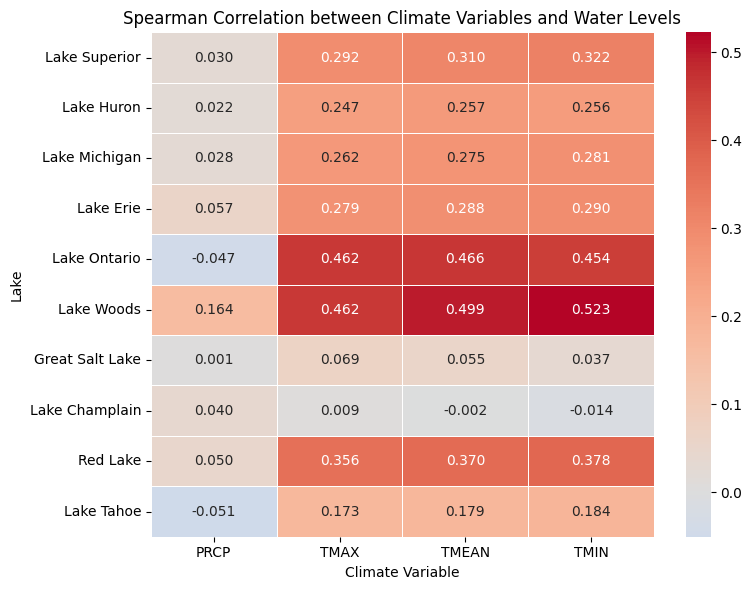

In [62]:
#Heatmap
spearman_matrix = spearman_results.pivot(
    index="Lake",
    columns="Climate Variable",
    values="Spearman rho"
)

spearman_matrix = spearman_matrix.reindex(lake_order)

plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".3f"
)

plt.title("Spearman Correlation between Climate Variables and Water Levels")

plt.tight_layout()
plt.show()

### (4)Pearson-Spearman Comparison

In [63]:
comparison = pearson_results.merge(
    spearman_results,
    on=["Lake","Climate Variable"],
    suffixes=("_Pearson","_Spearman")
)

# Both correlations should use the same pairwise observations
assert (
    comparison["N_Pearson"]
    ==
    comparison["N_Spearman"]
).all()


comparison["N"] = (
    comparison["N_Pearson"]
)


comparison["Correlation Difference"] = (
    comparison["Spearman rho"]
    -
    comparison["Pearson r"]
)


comparison["Absolute Difference"] = (
    comparison[
        "Correlation Difference"
    ].abs()
)

comparison = comparison[
    [
        "Lake",
        "Climate Variable",
        "N",
        "Pearson r",
        "Spearman rho",
        "Correlation Difference",
        "Absolute Difference"
    ]
]
comparison = comparison.sort_values(
    [
        "Lake",
        "Climate Variable"
    ]
)


display(comparison)

,Lake,Climate Variable,N,Pearson r,Spearman rho,Correlation Difference,Absolute Difference
24,Great Salt Lake,PRCP,7303,-0.005188,0.001117,0.006305,0.006305
25,Great Salt Lake,TMAX,7305,0.063595,0.068832,0.005237,0.005237
27,Great Salt Lake,TMEAN,7305,0.046739,0.055213,0.008474,0.008474
26,Great Salt Lake,TMIN,7305,0.024562,0.036677,0.012115,0.012115
28,Lake Champlain,PRCP,7305,0.027954,0.040074,0.012120,0.012120
29,Lake Champlain,TMAX,7305,0.031449,0.009126,-0.022323,0.022323
31,Lake Champlain,TMEAN,7305,0.023260,-0.001689,-0.024949,0.024949
30,Lake Champlain,TMIN,7305,0.013471,-0.014302,-0.027773,0.027773
12,Lake Erie,PRCP,7305,0.081019,0.057457,-0.023563,0.023563
13,Lake Erie,TMAX,7305,0.284261,0.278836,-0.005425,0.005425


In [64]:
# Rank relationships by Pearson-Spearman difference

pearson_spearman_difference = (
    comparison
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    pearson_spearman_difference
)

,Lake,Climate Variable,N,Pearson r,Spearman rho,Correlation Difference,Absolute Difference
0,Lake Ontario,PRCP,7275,0.034356,-0.047237,-0.081592,0.081592
1,Lake Woods,TMIN,7250,0.445008,0.522711,0.077703,0.077703
2,Lake Woods,TMEAN,7250,0.439553,0.499275,0.059722,0.059722
3,Lake Woods,TMAX,7250,0.421328,0.462227,0.040899,0.040899
4,Lake Huron,PRCP,7266,0.055529,0.021998,-0.033531,0.033531
5,Lake Woods,PRCP,7235,0.134449,0.164333,0.029884,0.029884
6,Lake Champlain,TMIN,7305,0.013471,-0.014302,-0.027773,0.027773
7,Lake Ontario,TMIN,7275,0.428007,0.453753,0.025745,0.025745
8,Lake Champlain,TMEAN,7305,0.023260,-0.001689,-0.024949,0.024949
9,Lake Tahoe,TMIN,7305,0.159380,0.183517,0.024138,0.024138


In [65]:
# Identify relationships where Pearson and Spearman have different signs

comparison["Different Sign"] = (
    np.sign(
        comparison["Pearson r"]
    )
    !=
    np.sign(
        comparison["Spearman rho"]
    )
)


different_sign_results = (
    comparison[
        comparison["Different Sign"]
    ]
    .copy()
)


display(
    different_sign_results
)

,Lake,Climate Variable,N,Pearson r,Spearman rho,Correlation Difference,Absolute Difference,Different Sign
24,Great Salt Lake,PRCP,7303,-0.005188,0.001117,0.006305,0.006305,True
31,Lake Champlain,TMEAN,7305,0.023260,-0.001689,-0.024949,0.024949,True
30,Lake Champlain,TMIN,7305,0.013471,-0.014302,-0.027773,0.027773,True
16,Lake Ontario,PRCP,7275,0.034356,-0.047237,-0.081592,0.081592,True


### (5)Spearman Summary

In [66]:
# Summarise Spearman correlations by climate variable

spearman_summary_data = (
    comparison
    .copy()
)


spearman_summary_data[
    "Absolute Spearman rho"
] = (
    spearman_summary_data[
        "Spearman rho"
    ].abs()
)


spearman_variable_summary = (
    spearman_summary_data
    .groupby("Climate Variable")
    .agg(
        Mean_Spearman_rho=("Spearman rho", "mean"),
        Median_Spearman_rho=("Spearman rho", "median"),
        Minimum_Spearman_rho=("Spearman rho", "min"),
        Maximum_Spearman_rho=("Spearman rho", "max")
    )
    .reset_index()
)

spearman_variable_summary

,Climate Variable,Mean_Spearman_rho,Median_Spearman_rho,Minimum_Spearman_rho,Maximum_Spearman_rho
0,PRCP,0.029495,0.028978,-0.050614,0.164333
1,TMAX,0.261162,0.270604,0.009126,0.462227
2,TMEAN,0.269833,0.281694,-0.001689,0.499275
3,TMIN,0.270927,0.285606,-0.014302,0.522711


In [67]:
# Identify the strongest Spearman relationship for each variable
strongest_spearman_by_variable = (
   comparison
    .loc[
        comparison
        .groupby("Climate Variable")["Spearman rho"]
        .apply(lambda x: x.abs().idxmax())
    ]
    [
        [
            "Climate Variable",
            "Lake",
            "N",
            "Spearman rho"
        ]
    ]
    .reset_index(drop=True)
)

strongest_spearman_by_variable

,Climate Variable,Lake,N,Spearman rho
0,PRCP,Lake Woods,7235,0.164333
1,TMAX,Lake Woods,7250,0.462227
2,TMEAN,Lake Woods,7250,0.499275
3,TMIN,Lake Woods,7250,0.522711


In [68]:
# Prepare Pearson-Spearman comparison table for the appendix

appendix_B2 = comparison[
    [
        "Lake",
        "Climate Variable",
        "N",
        "Pearson r",
        "Spearman rho"
    ]
].copy()


appendix_B2[
    [
        "Pearson r",
        "Spearman rho"
    ]
] = (
    appendix_B2[
        [
            "Pearson r",
            "Spearman rho"
        ]
    ]
    .round(3)
)


display(
    appendix_B2
)

,Lake,Climate Variable,N,Pearson r,Spearman rho
24,Great Salt Lake,PRCP,7303,-0.005,0.001
25,Great Salt Lake,TMAX,7305,0.064,0.069
27,Great Salt Lake,TMEAN,7305,0.047,0.055
26,Great Salt Lake,TMIN,7305,0.025,0.037
28,Lake Champlain,PRCP,7305,0.028,0.040
29,Lake Champlain,TMAX,7305,0.031,0.009
31,Lake Champlain,TMEAN,7305,0.023,-0.002
30,Lake Champlain,TMIN,7305,0.013,-0.014
12,Lake Erie,PRCP,7305,0.081,0.057
13,Lake Erie,TMAX,7305,0.284,0.279


### (6)WESD Avalibility Check

In [69]:
# Check WESD availability across lakes

wesd_check = []

for lake in lake_order:

    lake_df = water_climate[
        water_climate["Lake"] == lake
    ]

    wesd_check.append(
        {
            "Lake": lake,
            "Available WESD": (
                lake_df["WESD"]
                .notna()
                .sum()
            ),
            "Missing WESD": (
                lake_df["WESD"]
                .isna()
                .sum()
            ),
            "Unique WESD Values": (
                lake_df["WESD"]
                .nunique()
            ),
            "Minimum WESD": (
                lake_df["WESD"]
                .min()
            ),
            "Maximum WESD": (
                lake_df["WESD"]
                .max()
            )
        }
    )


wesd_check = (
    pd.DataFrame(wesd_check)
    .set_index("Lake")
    .reindex(lake_order)
)

display(wesd_check)

,Available WESD,Missing WESD,Unique WESD Values,Minimum WESD,Maximum WESD
Lake,,,,,
Lake Superior,1826,5479,1,0.0,0.0
Lake Huron,0,7305,0,NaN,NaN
Lake Michigan,1826,5479,1,0.0,0.0
Lake Erie,2138,5167,3,0.0,5.1
Lake Ontario,1861,5444,1,0.0,0.0
Lake Woods,0,7305,0,NaN,NaN
Great Salt Lake,1826,5479,1,0.0,0.0
Lake Champlain,1826,5479,1,0.0,0.0
Red Lake,0,7305,0,NaN,NaN


### (7)Cross-Correlation Analysis

#### [1]Define Reusable CCF Function

In [70]:
# Calculate lagged climate-water-level correlations

def calculate_climate_ccf(
    data,
    cases,
    max_lag
):

    results = []


    for lake, variable in cases:

        temp = (
            data[
                data["Lake"] == lake
            ][
                [
                    "Date",
                    "Lake_Level_ft",
                    variable
                ]
            ]
            .sort_values("Date")
            .copy()
        )


        # Confirm that row lags correspond to calendar-day lags
        date_differences = (
            temp["Date"]
            .diff()
            .dropna()
        )


        if not (
            date_differences
            ==
            pd.Timedelta(days=1)
        ).all():

            raise ValueError(
                f"Non-daily date sequence detected for {lake}."
            )


        for lag in range(
            0,
            max_lag + 1
        ):

            lagged_climate = (
                temp[variable]
                .shift(lag)
            )


            subset = pd.DataFrame(
                {
                    "Lake_Level_ft":
                        temp[
                            "Lake_Level_ft"
                        ],

                    "Lagged_Climate":
                        lagged_climate
                }
            ).dropna()


            if len(subset) <= 10:
                continue


            if (
                subset[
                    "Lake_Level_ft"
                ].nunique() <= 1
            ):
                continue


            if (
                subset[
                    "Lagged_Climate"
                ].nunique() <= 1
            ):
                continue


            r = subset[
                "Lake_Level_ft"
            ].corr(
                subset[
                    "Lagged_Climate"
                ],
                method="pearson"
            )


            results.append(
                {
                    "Lake": lake,
                    "Climate Variable": variable,
                    "Lag": lag,
                    "N": len(subset),
                    "Correlation": r,
                    "Abs Correlation": abs(r)
                }
            )


    return pd.DataFrame(
        results
    )

#### [2]Initial 0-30-day CCF

In [71]:
# Define all lake-variable combinations

all_climate_ccf_cases = [
    (
        lake,
        variable
    )
    for lake in lake_order
    for variable in climate_variables
]

max_lag = 30 
ccf_results = calculate_climate_ccf(
    data=water_climate,
    cases=all_climate_ccf_cases,
    max_lag=max_lag
)

ccf_results.head()

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation
0,Lake Superior,PRCP,0,7274,0.046555,0.046555
1,Lake Superior,PRCP,1,7273,0.045625,0.045625
2,Lake Superior,PRCP,2,7272,0.051668,0.051668
3,Lake Superior,PRCP,3,7271,0.054338,0.054338
4,Lake Superior,PRCP,4,7270,0.055153,0.055153


#### [3]Find Best Lag

In [72]:
# Find the strongest absolute correlation within the 0-30 day window

best_lag_summary = (
    ccf_results
    .sort_values(
         [
            "Lake",
            "Climate Variable",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(["Lake", "Climate Variable"],observed=True)
    .head(1)
    .reset_index(drop=True)
)

best_lag_summary[
    "At 30-day Boundary"
] = (
    best_lag_summary[
        "Lag"
    ]
    ==
    max_lag
)

best_lag_summary["Lake"] = (
    pd.Categorical(
        best_lag_summary["Lake"],
        categories=lake_order,
        ordered=True
    )
)

best_lag_summary = (
    best_lag_summary
    .sort_values(
        [
            "Lake",
            "Climate Variable"
        ]
    )
    .reset_index(drop=True)
)

best_lag_summary

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation,At 30-day Boundary
0,Lake Superior,PRCP,29,7245,0.070462,0.070462,False
1,Lake Superior,TMAX,28,7246,0.346461,0.346461,False
2,Lake Superior,TMEAN,28,7246,0.355038,0.355038,False
3,Lake Superior,TMIN,28,7246,0.353922,0.353922,False
4,Lake Huron,PRCP,4,7262,0.058300,0.058300,False
5,Lake Huron,TMAX,0,7275,0.233697,0.233697,False
6,Lake Huron,TMEAN,3,7272,0.241973,0.241973,False
7,Lake Huron,TMIN,3,7272,0.236225,0.236225,False
8,Lake Michigan,PRCP,0,7305,0.048356,0.048356,False
9,Lake Michigan,TMAX,0,7305,0.255083,0.255083,False


#### [4]Compare Best Lag with Lag 0

In [73]:
# Extract lag-0 correlations

lag0_summary = (
    ccf_results[
        ccf_results["Lag"] == 0
    ]
    [
        [
            "Lake",
            "Climate Variable",
            "N",
            "Correlation"
        ]
    ]
    .copy()
    .rename(
        columns={
            "N": "Lag0 N",
            "Correlation":
                "Lag0 Correlation"
        }
    )
)


# Compare lag-0 and best-lag relationships

lag_comparison = (
    best_lag_summary
    .merge(
        lag0_summary,
        on=[
            "Lake",
            "Climate Variable"
        ],
        how="left"
    )
)


lag_comparison[
    "Correlation Difference"
] = (
    lag_comparison[
        "Correlation"
    ]
    -
    lag_comparison[
        "Lag0 Correlation"
    ]
)


lag_comparison[
    "Abs Difference"
] = (
    lag_comparison[
        "Abs Correlation"
    ]
    -
    lag_comparison[
        "Lag0 Correlation"
    ].abs()
)




lag_comparison[
    "At 30-day Boundary"
] = (
    lag_comparison[
        "Lag"
    ]
    ==
    max_lag
)


lag_comparison["Lake"] = (
    pd.Categorical(
        lag_comparison["Lake"],
        categories=lake_order,
        ordered=True
    )
)


lag_comparison = (
    lag_comparison
    .sort_values(
        [
            "Lake",
            "Climate Variable"
        ]
    )
    .reset_index(drop=True)
)


display(
    lag_comparison[
        [
            "Lake",
            "Climate Variable",
            "Lag0 N",
            "Lag0 Correlation",
            "Lag",
            "N",
            "Correlation",
            "Abs Difference",
            "At 30-day Boundary"
        ]
    ]
)

,Lake,Climate Variable,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Difference,At 30-day Boundary
0,Lake Superior,PRCP,7274,0.046555,29,7245,0.070462,0.023907,False
1,Lake Superior,TMAX,7274,0.290891,28,7246,0.346461,0.055570,False
2,Lake Superior,TMEAN,7274,0.304427,28,7246,0.355038,0.050610,False
3,Lake Superior,TMIN,7274,0.310135,28,7246,0.353922,0.043787,False
4,Lake Huron,PRCP,7266,0.055529,4,7262,0.058300,0.002771,False
5,Lake Huron,TMAX,7275,0.233697,0,7275,0.233697,0.000000,False
6,Lake Huron,TMEAN,7275,0.241745,3,7272,0.241973,0.000227,False
7,Lake Huron,TMIN,7275,0.234360,3,7272,0.236225,0.001865,False
8,Lake Michigan,PRCP,7305,0.048356,0,7305,0.048356,0.000000,False
9,Lake Michigan,TMAX,7305,0.255083,0,7305,0.255083,0.000000,False


#### [5]Extended 0-60-day CCF

In [74]:
# Identify cases whose optimum occurs at the 30-day search boundary

boundary_cases_30 = (
    best_lag_summary[
        best_lag_summary[
            "At 30-day Boundary"
        ]
    ]
    [
        [
            "Lake",
            "Climate Variable"
        ]
    ]
    .copy()
)


boundary_cases_30_list = list(
    boundary_cases_30.itertuples(
        index=False,
        name=None
    )
)


display(
    boundary_cases_30
)

,Lake,Climate Variable
24,Great Salt Lake,PRCP
25,Great Salt Lake,TMAX
26,Great Salt Lake,TMEAN
27,Great Salt Lake,TMIN
29,Lake Champlain,TMAX
30,Lake Champlain,TMEAN
31,Lake Champlain,TMIN


In [75]:
extended60_max_lag = 60


if len(
    boundary_cases_30_list
) > 0:

    extended60_ccf_results = (
        calculate_climate_ccf(
            data=water_climate,
            cases=boundary_cases_30_list,
            max_lag=extended60_max_lag
        )
    )


    extended60_best_lag_summary = (
        extended60_ccf_results
        .sort_values(
            [
                "Lake",
                "Climate Variable",
                "Abs Correlation",
                "Lag"
            ],
            ascending=[
                True,
                True,
                False,
                True
            ]
        )
        .groupby(
            [
                "Lake",
                "Climate Variable"
            ],
            observed=True
        )
        .head(1)
        .reset_index(drop=True)
    )


    extended60_best_lag_summary[
        "At 60-day Boundary"
    ] = (
        extended60_best_lag_summary[
            "Lag"
        ]
        ==
        extended60_max_lag
    )


    display(
        extended60_best_lag_summary
    )

else:

    extended60_ccf_results = (
        pd.DataFrame()
    )

    extended60_best_lag_summary = (
        pd.DataFrame()
    )

    print(
        "No 30-day boundary cases require extension."
    )

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation,At 60-day Boundary
0,Great Salt Lake,PRCP,60,7243,0.033008,0.033008,True
1,Great Salt Lake,TMAX,60,7245,-0.216953,0.216953,True
2,Great Salt Lake,TMEAN,60,7245,-0.233922,0.233922,True
3,Great Salt Lake,TMIN,60,7245,-0.249409,0.249409,True
4,Lake Champlain,TMAX,60,7245,-0.451963,0.451963,True
5,Lake Champlain,TMEAN,60,7245,-0.464272,0.464272,True
6,Lake Champlain,TMIN,60,7245,-0.461385,0.461385,True


In [76]:
# Compare 30- and 60-day results
if not extended60_best_lag_summary.empty:

    summary_30 = (
        best_lag_summary[
            best_lag_summary[
                "At 30-day Boundary"
            ]
        ]
        [
            [
                "Lake",
                "Climate Variable",
                "Lag",
                "Correlation",
                "Abs Correlation"
            ]
        ]
        .rename(
            columns={
                "Lag":
                    "Best Lag (0-30)",

                "Correlation":
                    "Best Correlation (0-30)",

                "Abs Correlation":
                    "Best Abs Correlation (0-30)"
            }
        )
    )


    summary_60 = (
        extended60_best_lag_summary[
            [
                "Lake",
                "Climate Variable",
                "Lag",
                "Correlation",
                "Abs Correlation",
                "At 60-day Boundary"
            ]
        ]
        .rename(
            columns={
                "Lag":
                    "Best Lag (0-60)",

                "Correlation":
                    "Best Correlation (0-60)",

                "Abs Correlation":
                    "Best Abs Correlation (0-60)"
            }
        )
    )


    extended_lag_comparison = (
        summary_30
        .merge(
            summary_60,
            on=[
                "Lake",
                "Climate Variable"
            ],
            how="left"
        )
    )


    extended_lag_comparison[
        "Abs Correlation Improvement"
    ] = (
        extended_lag_comparison[
            "Best Abs Correlation (0-60)"
        ]
        -
        extended_lag_comparison[
            "Best Abs Correlation (0-30)"
        ]
    )


    display(
        extended_lag_comparison
    )

,Lake,Climate Variable,Best Lag (0-30),Best Correlation (0-30),Best Abs Correlation (0-30),Best Lag (0-60),Best Correlation (0-60),Best Abs Correlation (0-60),At 60-day Boundary,Abs Correlation Improvement
0,Great Salt Lake,PRCP,30,0.019719,0.019719,60,0.033008,0.033008,True,0.013288
1,Great Salt Lake,TMAX,30,-0.082348,0.082348,60,-0.216953,0.216953,True,0.134606
2,Great Salt Lake,TMEAN,30,-0.099439,0.099439,60,-0.233922,0.233922,True,0.134483
3,Great Salt Lake,TMIN,30,-0.118339,0.118339,60,-0.249409,0.249409,True,0.131070
4,Lake Champlain,TMAX,30,-0.230865,0.230865,60,-0.451963,0.451963,True,0.221098
5,Lake Champlain,TMEAN,30,-0.236603,0.236603,60,-0.464272,0.464272,True,0.227669
6,Lake Champlain,TMIN,30,-0.234526,0.234526,60,-0.461385,0.461385,True,0.226859


In [77]:
# Determine whether it needs to be extended to 90 days
if not extended60_best_lag_summary.empty:

    boundary_cases_60 = (
        extended60_best_lag_summary[
            extended60_best_lag_summary[
                "At 60-day Boundary"
            ]
        ]
        [
            [
                "Lake",
                "Climate Variable"
            ]
        ]
        .copy()
    )


    boundary_cases_60_list = list(
        boundary_cases_60.itertuples(
            index=False,
            name=None
        )
    )


    display(
        boundary_cases_60
    )

else:

    boundary_cases_60_list = []

,Lake,Climate Variable
0,Great Salt Lake,PRCP
1,Great Salt Lake,TMAX
2,Great Salt Lake,TMEAN
3,Great Salt Lake,TMIN
4,Lake Champlain,TMAX
5,Lake Champlain,TMEAN
6,Lake Champlain,TMIN


#### [6]Extended 0-90-day CCF

In [78]:
extended90_max_lag = 90


if len(
    boundary_cases_60_list
) > 0:

    extended90_ccf_results = (
        calculate_climate_ccf(
            data=water_climate,
            cases=boundary_cases_60_list,
            max_lag=extended90_max_lag
        )
    )


    extended90_best_lag_summary = (
        extended90_ccf_results
        .sort_values(
            [
                "Lake",
                "Climate Variable",
                "Abs Correlation",
                "Lag"
            ],
            ascending=[
                True,
                True,
                False,
                True
            ]
        )
        .groupby(
            [
                "Lake",
                "Climate Variable"
            ],
            observed=True
        )
        .head(1)
        .reset_index(drop=True)
    )


    extended90_best_lag_summary[
        "At 90-day Boundary"
    ] = (
        extended90_best_lag_summary[
            "Lag"
        ]
        ==
        extended90_max_lag
    )


    display(
        extended90_best_lag_summary
    )


else:

    extended90_ccf_results = (
        pd.DataFrame()
    )

    extended90_best_lag_summary = (
        pd.DataFrame()
    )

    print(
        "No 60-day boundary cases require extension to 90 days."
    )

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation,At 90-day Boundary
0,Great Salt Lake,PRCP,90,7213,0.045545,0.045545,True
1,Great Salt Lake,TMAX,90,7215,-0.303573,0.303573,True
2,Great Salt Lake,TMEAN,90,7215,-0.319042,0.319042,True
3,Great Salt Lake,TMIN,90,7215,-0.330613,0.330613,True
4,Lake Champlain,TMAX,90,7215,-0.557081,0.557081,True
5,Lake Champlain,TMEAN,90,7215,-0.566552,0.566552,True
6,Lake Champlain,TMIN,90,7215,-0.557023,0.557023,True


In [79]:
#Compare
if not extended90_best_lag_summary.empty:

    summary_90 = (
        extended90_best_lag_summary[
            [
                "Lake",
                "Climate Variable",
                "Lag",
                "Correlation",
                "Abs Correlation",
                "At 90-day Boundary"
            ]
        ]
        .rename(
            columns={
                "Lag":
                    "Best Lag (0-90)",

                "Correlation":
                    "Best Correlation (0-90)",

                "Abs Correlation":
                    "Best Abs Correlation (0-90)"
            }
        )
    )


    lag_window_comparison = (
        extended_lag_comparison
        .merge(
            summary_90,
            on=[
                "Lake",
                "Climate Variable"
            ],
            how="left"
        )
    )


    display(
        lag_window_comparison
    )

,Lake,Climate Variable,Best Lag (0-30),Best Correlation (0-30),Best Abs Correlation (0-30),Best Lag (0-60),Best Correlation (0-60),Best Abs Correlation (0-60),At 60-day Boundary,Abs Correlation Improvement,Best Lag (0-90),Best Correlation (0-90),Best Abs Correlation (0-90),At 90-day Boundary
0,Great Salt Lake,PRCP,30,0.019719,0.019719,60,0.033008,0.033008,True,0.013288,90,0.045545,0.045545,True
1,Great Salt Lake,TMAX,30,-0.082348,0.082348,60,-0.216953,0.216953,True,0.134606,90,-0.303573,0.303573,True
2,Great Salt Lake,TMEAN,30,-0.099439,0.099439,60,-0.233922,0.233922,True,0.134483,90,-0.319042,0.319042,True
3,Great Salt Lake,TMIN,30,-0.118339,0.118339,60,-0.249409,0.249409,True,0.131070,90,-0.330613,0.330613,True
4,Lake Champlain,TMAX,30,-0.230865,0.230865,60,-0.451963,0.451963,True,0.221098,90,-0.557081,0.557081,True
5,Lake Champlain,TMEAN,30,-0.236603,0.236603,60,-0.464272,0.464272,True,0.227669,90,-0.566552,0.566552,True
6,Lake Champlain,TMIN,30,-0.234526,0.234526,60,-0.461385,0.461385,True,0.226859,90,-0.557023,0.557023,True


#### [7]Seasonal-Anomaly CCF Sensitivity Check

In [80]:
# Identify cases retained for the seasonal-anomaly sensitivity check

seasonal_sensitivity_cases = list(
    extended90_best_lag_summary[
        [
            "Lake",
            "Climate Variable"
        ]
    ]
    .itertuples(
        index=False,
        name=None
    )
)

print(
    "Sensitivity cases:",
    len(seasonal_sensitivity_cases)
)

print(
    seasonal_sensitivity_cases
)

Sensitivity cases: 7
[('Great Salt Lake', 'PRCP'), ('Great Salt Lake', 'TMAX'), ('Great Salt Lake', 'TMEAN'), ('Great Salt Lake', 'TMIN'), ('Lake Champlain', 'TMAX'), ('Lake Champlain', 'TMEAN'), ('Lake Champlain', 'TMIN')]


In [81]:
# Create a separate dataset for seasonal-anomaly sensitivity analysis

seasonal_anomaly_data = (
    water_climate
    .copy()
)


# Use month and day to define the recurring calendar-day seasonal cycle

seasonal_anomaly_data[
    "Seasonal_Key"
] = (
    seasonal_anomaly_data["Date"]
    .dt.strftime("%m-%d")
)

# Calculate the long-term calendar-day mean water level for each lake

seasonal_anomaly_data[
    "Lake_Level_Seasonal_Mean"
] = (
    seasonal_anomaly_data
    .groupby(
        [
            "Lake",
            "Seasonal_Key"
        ],
        observed=True
    )[
        "Lake_Level_ft"
    ]
    .transform("mean")
)


# Calculate water-level anomalies

seasonal_anomaly_data[
    "Lake_Level_Anomaly"
] = (
    seasonal_anomaly_data[
        "Lake_Level_ft"
    ]
    -
    seasonal_anomaly_data[
        "Lake_Level_Seasonal_Mean"
    ]
)

In [82]:
# Calculate calendar-day climatologies and anomalies
# for the meteorological variables

for variable in climate_variables:

    seasonal_mean_column = (
        f"{variable}_Seasonal_Mean"
    )

    anomaly_column = (
        f"{variable}_Anomaly"
    )


    seasonal_anomaly_data[
        seasonal_mean_column
    ] = (
        seasonal_anomaly_data
        .groupby(
            [
                "Lake",
                "Seasonal_Key"
            ],
            observed=True
        )[
            variable
        ]
        .transform("mean")
    )


    seasonal_anomaly_data[
        anomaly_column
    ] = (
        seasonal_anomaly_data[
            variable
        ]
        -
        seasonal_anomaly_data[
            seasonal_mean_column
        ]
    )

In [83]:
# Check that calendar-day anomaly means are approximately zero

anomaly_check = (
    seasonal_anomaly_data
    .groupby(
        [
            "Lake",
            "Seasonal_Key"
        ],
        observed=True
    )
    [
        "Lake_Level_Anomaly"
    ]
    .mean()
    .abs()
    .max()
)

print(
    "Maximum absolute calendar-day mean "
    "water-level anomaly:",
    anomaly_check
)

Maximum absolute calendar-day mean water-level anomaly: 7.275957614183426e-13


In [84]:
for variable in [
    "TMAX",
    "TMIN",
    "TMEAN",
    "PRCP"
]:

    check_value = (
        seasonal_anomaly_data
        .groupby(
            [
                "Lake",
                "Seasonal_Key"
            ],
            observed=True
        )[
            f"{variable}_Anomaly"
        ]
        .mean()
        .abs()
        .max()
    )

    print(
        variable,
        check_value
    )

TMAX 5.5067062021407766e-15
TMIN 2.930988785010413e-15
TMEAN 4.085620730620576e-15
PRCP 1.4210854715202005e-15


In [85]:
# Calculate CCF using seasonally adjusted anomaly series

def calculate_anomaly_ccf(
    data,
    cases,
    max_lag
):

    results = []


    for lake, variable in cases:

        climate_anomaly_column = (
            f"{variable}_Anomaly"
        )


        temp = (
            data[
                data["Lake"] == lake
            ][
                [
                    "Date",
                    "Lake_Level_Anomaly",
                    climate_anomaly_column
                ]
            ]
            .sort_values("Date")
            .copy()
        )


        # Confirm that row shifts correspond to calendar-day lags

        date_differences = (
            temp["Date"]
            .diff()
            .dropna()
        )


        if not (
            date_differences
            ==
            pd.Timedelta(days=1)
        ).all():

            raise ValueError(
                f"Non-daily date sequence detected for {lake}."
            )


        for lag in range(
            0,
            max_lag + 1
        ):

            lagged_climate = (
                temp[
                    climate_anomaly_column
                ]
                .shift(lag)
            )


            subset = pd.DataFrame(
                {
                    "Water_Level_Anomaly":
                        temp[
                            "Lake_Level_Anomaly"
                        ],

                    "Climate_Anomaly":
                        lagged_climate
                }
            ).dropna()


            if len(subset) <= 10:
                continue


            if (
                subset[
                    "Water_Level_Anomaly"
                ].nunique()
                <= 1
            ):
                continue


            if (
                subset[
                    "Climate_Anomaly"
                ].nunique()
                <= 1
            ):
                continue


            r = (
                subset[
                    "Water_Level_Anomaly"
                ]
                .corr(
                    subset[
                        "Climate_Anomaly"
                    ],
                    method="pearson"
                )
            )


            results.append(
                {
                    "Lake": lake,
                    "Climate Variable":
                        variable,
                    "Lag": lag,
                    "N": len(subset),
                    "Correlation": r,
                    "Abs Correlation":
                        abs(r)
                }
            )


    return pd.DataFrame(
        results
    )

In [86]:
# Run the seasonal-anomaly CCF sensitivity analysis

anomaly_max_lag = 90


anomaly_ccf_results = (
    calculate_anomaly_ccf(
        data=seasonal_anomaly_data,
        cases=seasonal_sensitivity_cases,
        max_lag=anomaly_max_lag
    )
)


display(
    anomaly_ccf_results.head()
)

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation
0,Great Salt Lake,PRCP,0,7303,-0.011415,0.011415
1,Great Salt Lake,PRCP,1,7302,-0.010457,0.010457
2,Great Salt Lake,PRCP,2,7301,-0.012526,0.012526
3,Great Salt Lake,PRCP,3,7300,-0.012587,0.012587
4,Great Salt Lake,PRCP,4,7299,-0.011342,0.011342


In [87]:
# Select the strongest anomaly correlation within 0-90 days

anomaly_best_lag_summary = (
    anomaly_ccf_results
    .sort_values(
        [
            "Lake",
            "Climate Variable",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(
        [
            "Lake",
            "Climate Variable"
        ],
        observed=True
    )
    .head(1)
    .reset_index(drop=True)
)


anomaly_best_lag_summary[
    "At 90-day Boundary"
] = (
    anomaly_best_lag_summary[
        "Lag"
    ]
    ==
    anomaly_max_lag
)


display(
    anomaly_best_lag_summary
)

,Lake,Climate Variable,Lag,N,Correlation,Abs Correlation,At 90-day Boundary
0,Great Salt Lake,PRCP,89,7214,0.017934,0.017934,False
1,Great Salt Lake,TMAX,88,7217,-0.100892,0.100892,False
2,Great Salt Lake,TMEAN,82,7223,-0.142829,0.142829,False
3,Great Salt Lake,TMIN,82,7223,-0.174867,0.174867,False
4,Lake Champlain,TMAX,68,7237,-0.092312,0.092312,False
5,Lake Champlain,TMEAN,71,7234,-0.082227,0.082227,False
6,Lake Champlain,TMIN,88,7217,-0.063729,0.063729,False


In [88]:
# Prepare the raw-series 0-90 day results

raw_90_summary = (
    extended90_best_lag_summary[
        [
            "Lake",
            "Climate Variable",
            "Lag",
            "Correlation",
            "Abs Correlation",
            "At 90-day Boundary"
        ]
    ]
    .rename(
        columns={
            "Lag":
                "Raw Best Lag",

            "Correlation":
                "Raw Correlation",

            "Abs Correlation":
                "Raw Abs Correlation",

            "At 90-day Boundary":
                "Raw At 90-day Boundary"
        }
    )
)

# Prepare the seasonal-anomaly results

anomaly_90_summary = (
    anomaly_best_lag_summary[
        [
            "Lake",
            "Climate Variable",
            "Lag",
            "Correlation",
            "Abs Correlation",
            "At 90-day Boundary"
        ]
    ]
    .rename(
        columns={
            "Lag":
                "Anomaly Best Lag",

            "Correlation":
                "Anomaly Correlation",

            "Abs Correlation":
                "Anomaly Abs Correlation",

            "At 90-day Boundary":
                "Anomaly At 90-day Boundary"
        }
    )
)

# Compare raw and seasonally adjusted CCF results

seasonal_ccf_comparison = (
    raw_90_summary
    .merge(
        anomaly_90_summary,
        on=[
            "Lake",
            "Climate Variable"
        ],
        how="left"
    )
)


seasonal_ccf_comparison[
    "Reduction in Abs Correlation"
] = (
    seasonal_ccf_comparison[
        "Raw Abs Correlation"
    ]
    -
    seasonal_ccf_comparison[
        "Anomaly Abs Correlation"
    ]
)


display(
    seasonal_ccf_comparison.round(3)
)

,Lake,Climate Variable,Raw Best Lag,Raw Correlation,Raw Abs Correlation,Raw At 90-day Boundary,Anomaly Best Lag,Anomaly Correlation,Anomaly Abs Correlation,Anomaly At 90-day Boundary,Reduction in Abs Correlation
0,Great Salt Lake,PRCP,90,0.046,0.046,True,89,0.018,0.018,False,0.028
1,Great Salt Lake,TMAX,90,-0.304,0.304,True,88,-0.101,0.101,False,0.203
2,Great Salt Lake,TMEAN,90,-0.319,0.319,True,82,-0.143,0.143,False,0.176
3,Great Salt Lake,TMIN,90,-0.331,0.331,True,82,-0.175,0.175,False,0.156
4,Lake Champlain,TMAX,90,-0.557,0.557,True,68,-0.092,0.092,False,0.465
5,Lake Champlain,TMEAN,90,-0.567,0.567,True,71,-0.082,0.082,False,0.484
6,Lake Champlain,TMIN,90,-0.557,0.557,True,88,-0.064,0.064,False,0.493


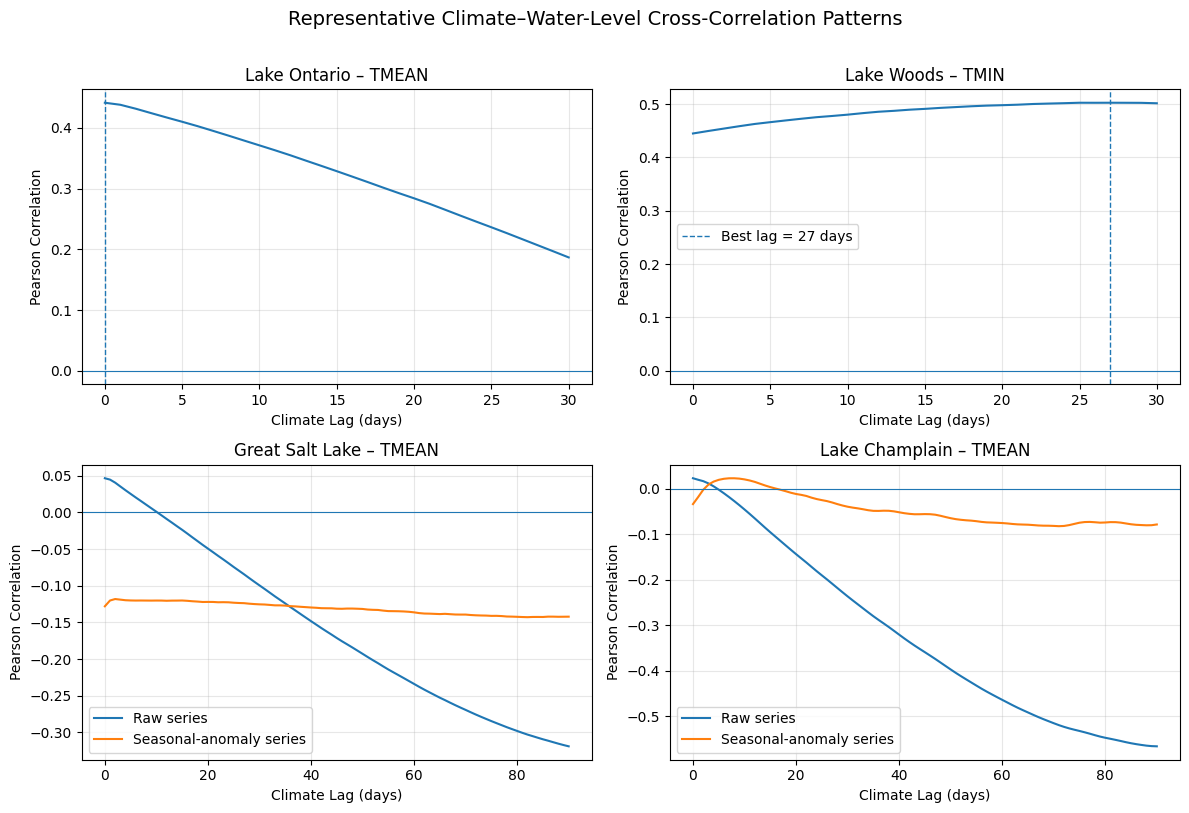

In [89]:
# Create representative CCF figure for the dissertation

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()



# Panel A: Lake Ontario - TMEAN
# Representative contemporaneous relationship


ontario_tmean = (
    ccf_results[
        (ccf_results["Lake"] == "Lake Ontario")
        &
        (ccf_results["Climate Variable"] == "TMEAN")
    ]
    .sort_values("Lag")
    .copy()
)

axes[0].plot(
    ontario_tmean["Lag"],
    ontario_tmean["Correlation"]
)

axes[0].axhline(
    0,
    linewidth=0.8
)

axes[0].axvline(
    0,
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "Lake Ontario – TMEAN"
)

axes[0].set_xlabel(
    "Climate Lag (days)"
)

axes[0].set_ylabel(
    "Pearson Correlation"
)

axes[0].grid(
    alpha=0.3
)



# Panel B: Lake Woods - TMIN
# Representative multi-week lagged relationship


woods_tmin = (
    ccf_results[
        (ccf_results["Lake"] == "Lake Woods")
        &
        (ccf_results["Climate Variable"] == "TMIN")
    ]
    .sort_values("Lag")
    .copy()
)

woods_best_lag = (
    woods_tmin
    .loc[
        woods_tmin["Abs Correlation"].idxmax(),
        "Lag"
    ]
)

axes[1].plot(
    woods_tmin["Lag"],
    woods_tmin["Correlation"]
)

axes[1].axhline(
    0,
    linewidth=0.8
)

axes[1].axvline(
    woods_best_lag,
    linestyle="--",
    linewidth=1,
    label=f"Best lag = {int(woods_best_lag)} days"
)

axes[1].set_title(
    "Lake Woods – TMIN"
)

axes[1].set_xlabel(
    "Climate Lag (days)"
)

axes[1].set_ylabel(
    "Pearson Correlation"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)



# Panel C: Great Salt Lake - TMEAN
# Raw series versus seasonal anomaly


gsl_raw = (
    extended90_ccf_results[
        (extended90_ccf_results["Lake"] == "Great Salt Lake")
        &
        (extended90_ccf_results["Climate Variable"] == "TMEAN")
    ]
    .sort_values("Lag")
    .copy()
)

gsl_anomaly = (
    anomaly_ccf_results[
        (anomaly_ccf_results["Lake"] == "Great Salt Lake")
        &
        (anomaly_ccf_results["Climate Variable"] == "TMEAN")
    ]
    .sort_values("Lag")
    .copy()
)

axes[2].plot(
    gsl_raw["Lag"],
    gsl_raw["Correlation"],
    label="Raw series"
)

axes[2].plot(
    gsl_anomaly["Lag"],
    gsl_anomaly["Correlation"],
    label="Seasonal-anomaly series"
)

axes[2].axhline(
    0,
    linewidth=0.8
)

axes[2].set_title(
    "Great Salt Lake – TMEAN"
)

axes[2].set_xlabel(
    "Climate Lag (days)"
)

axes[2].set_ylabel(
    "Pearson Correlation"
)

axes[2].legend()

axes[2].grid(
    alpha=0.3
)



# Panel D: Lake Champlain - TMEAN
# Raw series versus seasonal anomaly


champlain_raw = (
    extended90_ccf_results[
        (extended90_ccf_results["Lake"] == "Lake Champlain")
        &
        (extended90_ccf_results["Climate Variable"] == "TMEAN")
    ]
    .sort_values("Lag")
    .copy()
)

champlain_anomaly = (
    anomaly_ccf_results[
        (anomaly_ccf_results["Lake"] == "Lake Champlain")
        &
        (anomaly_ccf_results["Climate Variable"] == "TMEAN")
    ]
    .sort_values("Lag")
    .copy()
)

axes[3].plot(
    champlain_raw["Lag"],
    champlain_raw["Correlation"],
    label="Raw series"
)

axes[3].plot(
    champlain_anomaly["Lag"],
    champlain_anomaly["Correlation"],
    label="Seasonal-anomaly series"
)

axes[3].axhline(
    0,
    linewidth=0.8
)

axes[3].set_title(
    "Lake Champlain – TMEAN"
)

axes[3].set_xlabel(
    "Climate Lag (days)"
)

axes[3].set_ylabel(
    "Pearson Correlation"
)

axes[3].legend()

axes[3].grid(
    alpha=0.3
)




fig.suptitle(
    "Representative Climate–Water-Level Cross-Correlation Patterns",
    fontsize=14,
    y=1.01
)

plt.tight_layout()


fig.savefig(
    "Figure_Representative_Climate_Water_Level_CCF_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
# Compare raw and seasonally adjusted correlations at the same 90-day lag

raw_lag90 = (
    extended90_ccf_results[
        extended90_ccf_results["Lag"] == 90
    ][
        [
            "Lake",
            "Climate Variable",
            "Correlation"
        ]
    ]
    .rename(
        columns={
            "Correlation": "Raw r at 90 days"
        }
    )
)


anomaly_lag90 = (
    anomaly_ccf_results[
        anomaly_ccf_results["Lag"] == 90
    ][
        [
            "Lake",
            "Climate Variable",
            "Correlation"
        ]
    ]
    .rename(
        columns={
            "Correlation": "Anomaly r at 90 days"
        }
    )
)


seasonal_sensitivity_summary = (
    raw_lag90
    .merge(
        anomaly_lag90,
        on=[
            "Lake",
            "Climate Variable"
        ],
        how="left"
    )
)


seasonal_sensitivity_summary[
    "Reduction in |r| (%)"
] = (
    (
        seasonal_sensitivity_summary[
            "Raw r at 90 days"
        ].abs()
        -
        seasonal_sensitivity_summary[
            "Anomaly r at 90 days"
        ].abs()
    )
    /
    seasonal_sensitivity_summary[
        "Raw r at 90 days"
    ].abs()
    * 100
)


display(
    seasonal_sensitivity_summary.round(3)
)

,Lake,Climate Variable,Raw r at 90 days,Anomaly r at 90 days,Reduction in |r| (%)
0,Great Salt Lake,PRCP,0.046,0.018,60.647
1,Great Salt Lake,TMAX,-0.304,-0.101,66.812
2,Great Salt Lake,TMEAN,-0.319,-0.142,55.444
3,Great Salt Lake,TMIN,-0.331,-0.173,47.597
4,Lake Champlain,TMAX,-0.557,-0.082,85.292
5,Lake Champlain,TMEAN,-0.567,-0.078,86.152
6,Lake Champlain,TMIN,-0.557,-0.062,88.823


## 8.Inter-lake Dependence

### (1) Pearson Correlation Analysis

#### 1.Prepare Water-level Data

In [91]:
# Make sure Date is datetime
water_climate["Date"] = pd.to_datetime(water_climate["Date"])

# One row per date, one column per lake
lake_level_wide = water_climate.pivot(
    index="Date",
    columns="Lake",
    values="Lake_Level_ft"
)

# Reorder columns
lake_level_wide = lake_level_wide[lake_order]

lake_level_wide.head()

Lake,Lake Superior,Lake Huron,Lake Michigan,Lake Erie,Lake Ontario,Lake Woods,Great Salt Lake,Lake Champlain,Red Lake,Lake Tahoe
Date,,,,,,,,,,
2006-01-01,601.63,576.83,577.54,569.96,244.54,59.40,4195.78,97.83,74.43,5.49
2006-01-02,601.48,576.95,577.49,570.19,244.54,59.38,4195.76,97.82,74.42,5.62
2006-01-03,601.33,576.97,577.18,570.52,244.57,59.35,4195.77,97.80,74.41,5.64
2006-01-04,601.32,576.79,577.21,571.10,244.60,59.32,4195.88,97.75,74.39,5.65
2006-01-05,601.33,576.96,577.12,570.76,244.65,59.31,4195.89,97.71,74.39,5.66


#### 2.Check missing values after pivot

In [92]:
missing_interlake = pd.DataFrame({
    "Missing Count": lake_level_wide.isna().sum(),
    "Missing Percentage": lake_level_wide.isna().mean() * 100
})

missing_interlake

,Missing Count,Missing Percentage
Lake,,
Lake Superior,31,0.424367
Lake Huron,30,0.410678
Lake Michigan,0,0.000000
Lake Erie,0,0.000000
Lake Ontario,30,0.410678
Lake Woods,21,0.287474
Great Salt Lake,0,0.000000
Lake Champlain,0,0.000000
Red Lake,167,2.286105


#### 3.Calculate Pearson Correlation between Water Levels

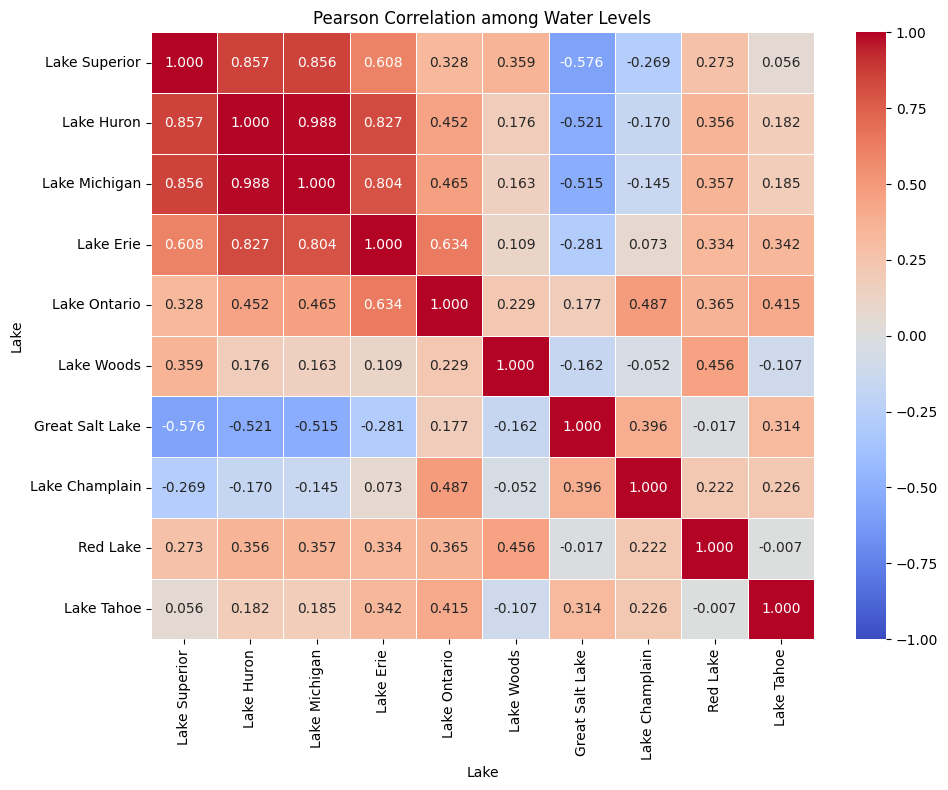

In [93]:
# Calculate contemporaneous Pearson correlations

interlake_corr = (
    lake_level_wide[
        lake_order
    ]
    .corr(method="pearson")
)


# Plot Pearson correlation heatmap

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    interlake_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".3f",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Pearson Correlation among Water Levels"
)

ax.set_xlabel("Lake")
ax.set_ylabel("Lake")

plt.tight_layout()


fig.savefig(
    "Figure_Interlake_Pearson_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
from itertools import combinations

interlake_pairs = []

for lake_1, lake_2 in combinations(lake_order, 2):

    pair_data = (
        lake_level_wide[
            [lake_1, lake_2]
        ]
        .dropna()
    )

    r = pair_data[lake_1].corr(
        pair_data[lake_2],
        method="pearson"
    )

    interlake_pairs.append({
        "Lake 1": lake_1,
        "Lake 2": lake_2,
        "N": len(pair_data),
        "Pearson r": r,
        "Abs Pearson r": abs(r)
    })


interlake_pairs = (
    pd.DataFrame(interlake_pairs)
    .sort_values(
        "Abs Pearson r",
        ascending=False
    )
    .reset_index(drop=True)
)

interlake_pairs

,Lake 1,Lake 2,N,Pearson r,Abs Pearson r
0,Lake Huron,Lake Michigan,7275,0.987701,0.987701
1,Lake Superior,Lake Huron,7244,0.856869,0.856869
2,Lake Superior,Lake Michigan,7274,0.856264,0.856264
3,Lake Huron,Lake Erie,7275,0.827023,0.827023
4,Lake Michigan,Lake Erie,7305,0.804138,0.804138
5,Lake Erie,Lake Ontario,7275,0.633665,0.633665
6,Lake Superior,Lake Erie,7274,0.608079,0.608079
7,Lake Superior,Great Salt Lake,7274,-0.575549,0.575549
8,Lake Huron,Great Salt Lake,7275,-0.521202,0.521202
9,Lake Michigan,Great Salt Lake,7305,-0.515200,0.515200


### (2)Cross Correlation Analysis

#### 1.Calculate Directional CCF over 0-30 Days

In [95]:
max_lag = 30

interlake_ccf_results = []

for leading_lake in lake_order:
    for response_lake in lake_order:

        if leading_lake == response_lake:
            continue

        for lag in range(0, max_lag + 1):

            # Positive lag k means the leading lake at t-k
            # is aligned with the response lake at time t
            pair_data = pd.DataFrame({
                "Leading": lake_level_wide[leading_lake].shift(lag),
                "Response": lake_level_wide[response_lake]
            }).dropna()

            # Require sufficient paired observations and variation
            if len(pair_data) <= 10:
                continue

            if pair_data["Leading"].nunique() <= 1:
                continue

            if pair_data["Response"].nunique() <= 1:
                continue

            r = pair_data["Leading"].corr(
                pair_data["Response"],
                method="pearson"
            )

            interlake_ccf_results.append({
                "Leading Lake": leading_lake,
                "Response Lake": response_lake,
                "Lag": lag,
                "N": len(pair_data),
                "Correlation": r,
                "Abs Correlation": abs(r)
            })


interlake_ccf_results = pd.DataFrame(interlake_ccf_results)

print("Number of directional lag results:", len(interlake_ccf_results))
print("Expected if all 90 directions × 31 lags are available:", 90 * 31)

interlake_ccf_results.head()

Number of directional lag results: 2790
Expected if all 90 directions × 31 lags are available: 2790


,Leading Lake,Response Lake,Lag,N,Correlation,Abs Correlation
0,Lake Superior,Lake Huron,0,7244,0.856869,0.856869
1,Lake Superior,Lake Huron,1,7243,0.858341,0.858341
2,Lake Superior,Lake Huron,2,7242,0.857182,0.857182
3,Lake Superior,Lake Huron,3,7241,0.856602,0.856602
4,Lake Superior,Lake Huron,4,7240,0.855926,0.855926


#### 2.Identify the Strongest Lag for Each Direction

In [96]:
best_interlake_lag = (
    interlake_ccf_results
    .sort_values(
        by=[
            "Leading Lake",
            "Response Lake",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(
        ["Leading Lake", "Response Lake"],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)

best_interlake_lag = best_interlake_lag[
    [
        "Leading Lake",
        "Response Lake",
        "Lag",
        "N",
        "Correlation",
        "Abs Correlation"
    ]
]

best_interlake_lag.sort_values(
    "Abs Correlation",
    ascending=False
).reset_index(drop=True)

,Leading Lake,Response Lake,Lag,N,Correlation,Abs Correlation
0,Lake Michigan,Lake Huron,5,7270,0.991284,0.991284
1,Lake Huron,Lake Michigan,3,7272,0.989041,0.989041
2,Lake Huron,Lake Superior,14,7230,0.861899,0.861899
3,Lake Superior,Lake Huron,1,7243,0.858341,0.858341
4,Lake Superior,Lake Michigan,1,7273,0.857129,0.857129
...,...,...,...,...,...,...
85,Lake Superior,Lake Tahoe,0,7274,0.055860,0.055860
86,Red Lake,Great Salt Lake,30,7108,-0.053888,0.053888
87,Lake Tahoe,Red Lake,30,7108,-0.037804,0.037804
88,Great Salt Lake,Red Lake,0,7138,-0.017288,0.017288


#### 3.Compare Lag-0 and Best-lag Correlations and Assess Boundary Cases

#### [1]Compare lag-0 and best-lag correlations

In [97]:
# Extract lag-0 correlations

interlake_lag0 = (
    interlake_ccf_results[
        interlake_ccf_results["Lag"] == 0
    ]
    [
        [
            "Leading Lake",
            "Response Lake",
            "N",
            "Correlation"
        ]
    ]
    .rename(
        columns={
            "N": "Lag0 N",
            "Correlation": "Lag0 Correlation"
        }
    )
)


# Merge lag-0 and best-lag results

interlake_lag_comparison = (
    best_interlake_lag
    .merge(
        interlake_lag0,
        on=[
            "Leading Lake",
            "Response Lake"
        ],
        how="left"
    )
)


# Measure the increase in absolute correlation strength

interlake_lag_comparison["Abs Difference"] = (
    interlake_lag_comparison["Abs Correlation"]
    - interlake_lag_comparison["Lag0 Correlation"].abs()
)


# Flag results whose strongest correlation occurs at the search boundary

interlake_lag_comparison["At 30-day Boundary"] = (
    interlake_lag_comparison["Lag"] == max_lag
)


interlake_lag_comparison = interlake_lag_comparison[
    [
        "Leading Lake",
        "Response Lake",
        "Lag0 N",
        "Lag0 Correlation",
        "Lag",
        "N",
        "Correlation",
        "Abs Correlation",
        "Abs Difference",
        "At 30-day Boundary"
    ]
]


interlake_lag_comparison = (
    interlake_lag_comparison
    .sort_values(
        "Abs Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

interlake_lag_comparison.sort_values(
    "Abs Difference",
    ascending=False
).head(30)

,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,At 30-day Boundary
60,Lake Woods,Lake Champlain,7284,-0.051777,30,7254,-0.237007,0.237007,0.185230,True
34,Lake Ontario,Lake Woods,7254,0.228951,30,7224,0.377099,0.377099,0.148148,True
28,Lake Ontario,Lake Superior,7244,0.328274,30,7214,0.446198,0.446198,0.117924,True
47,Lake Champlain,Red Lake,7138,0.221833,30,7108,0.335873,0.335873,0.114040,True
15,Lake Champlain,Lake Ontario,7275,0.487413,30,7245,0.599412,0.599412,0.111998,True
55,Lake Huron,Lake Champlain,7275,-0.169972,30,7245,-0.277150,0.277150,0.107178,True
58,Lake Michigan,Lake Champlain,7305,-0.144952,30,7275,-0.250956,0.250956,0.106003,True
35,Lake Superior,Lake Champlain,7274,-0.269153,30,7244,-0.371425,0.371425,0.102272,True
79,Lake Champlain,Lake Woods,7284,-0.051777,30,7254,0.151030,0.151030,0.099253,True
59,Lake Woods,Great Salt Lake,7284,-0.162073,30,7254,-0.249102,0.249102,0.087030,True


In [98]:
print(
    "Number of directions at 30-day boundary:",
    interlake_lag_comparison[
        "At 30-day Boundary"
    ].sum()
)

print(
    "Percentage at boundary:",
    interlake_lag_comparison[
        "At 30-day Boundary"
    ].mean() * 100
)

Number of directions at 30-day boundary: 28
Percentage at boundary: 31.11111111111111


#### [2]Extend 30-day boundary cases to 60 days

In [99]:
# Identify directional relationships that remain at the 30-day boundary

boundary_cases_30 = (
    interlake_lag_comparison[
        interlake_lag_comparison["At 30-day Boundary"]
    ]
    [
        [
            "Leading Lake",
            "Response Lake"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Extend 30-day boundary cases to a 60-day lag window

extended60_results = []

for _, row in boundary_cases_30.iterrows():

    leading_lake = row["Leading Lake"]
    response_lake = row["Response Lake"]

    for lag in range(0, 61):

        pair_data = pd.DataFrame({
            "Leading": lake_level_wide[leading_lake].shift(lag),
            "Response": lake_level_wide[response_lake]
        }).dropna()

        if len(pair_data) <= 10:
            continue

        if pair_data["Leading"].nunique() <= 1:
            continue

        if pair_data["Response"].nunique() <= 1:
            continue

        r = pair_data["Leading"].corr(
            pair_data["Response"],
            method="pearson"
        )

        extended60_results.append({
            "Leading Lake": leading_lake,
            "Response Lake": response_lake,
            "Lag": lag,
            "N": len(pair_data),
            "Correlation": r,
            "Abs Correlation": abs(r)
        })


extended60_results = pd.DataFrame(
    extended60_results
)

In [100]:
# Identify the strongest correlation within the extended 0–60-day window

extended60_best = (
    extended60_results
    .sort_values(
        [
            "Leading Lake",
            "Response Lake",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(
        [
            "Leading Lake",
            "Response Lake"
        ],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)


extended60_best[
    "At 60-day Boundary"
] = (
    extended60_best["Lag"] == 60
)


extended60_best[
    [
        "Leading Lake",
        "Response Lake",
        "Lag",
        "N",
        "Correlation",
        "Abs Correlation",
        "At 60-day Boundary"
    ]
]

print(
    "Number still at 60-day boundary:",
    extended60_best[
        "At 60-day Boundary"
    ].sum()
)

print(
    "Percentage of extended cases still at boundary:",
    extended60_best[
        "At 60-day Boundary"
    ].mean() * 100
)

Number still at 60-day boundary: 17
Percentage of extended cases still at boundary: 60.71428571428571


#### [3]Extend Remaining 60-day boundary cases to 90 days

In [101]:
# Identify relationships that still remain at the 60-day boundary

boundary_cases_60 = (
    extended60_best[
        extended60_best["At 60-day Boundary"]
    ]
    [
        [
            "Leading Lake",
            "Response Lake"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Extend remaining 60-day boundary cases to a 90-day lag window

extended90_results = []

for _, row in boundary_cases_60.iterrows():

    leading_lake = row["Leading Lake"]
    response_lake = row["Response Lake"]

    for lag in range(0, 91):

        pair_data = pd.DataFrame({
            "Leading": lake_level_wide[leading_lake].shift(lag),
            "Response": lake_level_wide[response_lake]
        }).dropna()

        if len(pair_data) <= 10:
            continue

        if pair_data["Leading"].nunique() <= 1:
            continue

        if pair_data["Response"].nunique() <= 1:
            continue

        r = pair_data["Leading"].corr(
            pair_data["Response"],
            method="pearson"
        )

        extended90_results.append({
            "Leading Lake": leading_lake,
            "Response Lake": response_lake,
            "Lag": lag,
            "N": len(pair_data),
            "Correlation": r,
            "Abs Correlation": abs(r)
        })


extended90_results = pd.DataFrame(
    extended90_results
)

In [102]:
# Identify the strongest correlation within the 0–90-day window

extended90_best = (
    extended90_results
    .sort_values(
        [
            "Leading Lake",
            "Response Lake",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(
        [
            "Leading Lake",
            "Response Lake"
        ],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)


extended90_best[
    "At 90-day Boundary"
] = (
    extended90_best["Lag"] == 90
)


extended90_best[
    [
        "Leading Lake",
        "Response Lake",
        "Lag",
        "N",
        "Correlation",
        "Abs Correlation",
        "At 90-day Boundary"
    ]
]

print(
    "Number still at 90-day boundary:",
    extended90_best[
        "At 90-day Boundary"
    ].sum()
)

print(
    "Percentage of extended cases still at boundary:",
    extended90_best[
        "At 90-day Boundary"
    ].mean() * 100
)

Number still at 90-day boundary: 8
Percentage of extended cases still at boundary: 47.05882352941176


In [103]:
# Identify relationships that remain unresolved at the 90-day boundary

boundary_cases_90 = (
    extended90_best[
        extended90_best["At 90-day Boundary"]
    ]
    [
        [
            "Leading Lake",
            "Response Lake",
            "Lag",
            "N",
            "Correlation",
            "Abs Correlation"
        ]
    ]
    .reset_index(drop=True)
)

boundary_cases_90

,Leading Lake,Response Lake,Lag,N,Correlation,Abs Correlation
0,Lake Erie,Great Salt Lake,90,7215,-0.448130,0.448130
1,Lake Erie,Lake Champlain,90,7215,-0.350256,0.350256
2,Lake Huron,Great Salt Lake,90,7185,-0.642099,0.642099
3,Lake Michigan,Great Salt Lake,90,7215,-0.643388,0.643388
4,Lake Michigan,Lake Champlain,90,7215,-0.365679,0.365679
5,Lake Tahoe,Red Lake,90,7048,-0.156212,0.156212
6,Lake Woods,Lake Tahoe,90,7194,-0.307287,0.307287
7,Red Lake,Great Salt Lake,90,7048,-0.143818,0.143818


In [104]:
# Start from the original 0–30-day results

final_interlake_ccf = (
    interlake_lag_comparison[
        [
            "Leading Lake",
            "Response Lake",
            "Lag0 N",
            "Lag0 Correlation",
            "Lag",
            "N",
            "Correlation",
            "Abs Correlation",
            "Abs Difference"
        ]
    ]
    .copy()
)

final_interlake_ccf["Search Window"] = "0–30"
final_interlake_ccf["Unresolved Boundary"] = False


# Replace 30-day boundary results with the extended 0–60-day results

for _, row in extended60_best.iterrows():

    mask = (
        (final_interlake_ccf["Leading Lake"] == row["Leading Lake"])
        &
        (final_interlake_ccf["Response Lake"] == row["Response Lake"])
    )

    final_interlake_ccf.loc[mask, "Lag"] = row["Lag"]
    final_interlake_ccf.loc[mask, "N"] = row["N"]
    final_interlake_ccf.loc[mask, "Correlation"] = row["Correlation"]
    final_interlake_ccf.loc[mask, "Abs Correlation"] = row["Abs Correlation"]
    final_interlake_ccf.loc[mask, "Search Window"] = "0–60"


# Replace remaining 60-day boundary cases with the extended 0–90-day results

for _, row in extended90_best.iterrows():

    mask = (
        (final_interlake_ccf["Leading Lake"] == row["Leading Lake"])
        &
        (final_interlake_ccf["Response Lake"] == row["Response Lake"])
    )

    final_interlake_ccf.loc[mask, "Lag"] = row["Lag"]
    final_interlake_ccf.loc[mask, "N"] = row["N"]
    final_interlake_ccf.loc[mask, "Correlation"] = row["Correlation"]
    final_interlake_ccf.loc[mask, "Abs Correlation"] = row["Abs Correlation"]
    final_interlake_ccf.loc[mask, "Search Window"] = "0–90"


# Recalculate improvement relative to lag 0

final_interlake_ccf["Abs Difference"] = (
    final_interlake_ccf["Abs Correlation"]
    - final_interlake_ccf["Lag0 Correlation"].abs()
)


# Flag cases that still remain at the 90-day boundary

for _, row in boundary_cases_90.iterrows():

    mask = (
        (final_interlake_ccf["Leading Lake"] == row["Leading Lake"])
        &
        (final_interlake_ccf["Response Lake"] == row["Response Lake"])
    )

    final_interlake_ccf.loc[
        mask,
        "Unresolved Boundary"
    ] = True


final_interlake_ccf = (
    final_interlake_ccf
    .sort_values(
        "Abs Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None
):
    display(final_interlake_ccf)

,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,Search Window,Unresolved Boundary
0,Lake Michigan,Lake Huron,7275,0.987701,5,7270,0.991284,0.991284,0.003583,0–30,False
1,Lake Huron,Lake Michigan,7275,0.987701,3,7272,0.989041,0.989041,0.001340,0–30,False
2,Lake Huron,Lake Superior,7244,0.856869,14,7230,0.861899,0.861899,0.005030,0–30,False
3,Lake Superior,Lake Huron,7244,0.856869,1,7243,0.858341,0.858341,0.001472,0–30,False
4,Lake Superior,Lake Michigan,7274,0.856264,1,7273,0.857129,0.857129,0.000866,0–30,False
5,Lake Michigan,Lake Superior,7274,0.856264,0,7274,0.856264,0.856264,0.000000,0–30,False
6,Lake Erie,Lake Huron,7275,0.827023,25,7250,0.838522,0.838522,0.011499,0–30,False
7,Lake Erie,Lake Michigan,7305,0.804138,25,7280,0.835047,0.835047,0.030909,0–30,False
8,Lake Huron,Lake Erie,7275,0.827023,1,7274,0.829193,0.829193,0.002170,0–30,False
9,Lake Michigan,Lake Erie,7305,0.804138,2,7303,0.826640,0.826640,0.022502,0–30,False


#### [4]Construct Final Adaptive-Window CCF Summary

In [105]:
# Identify sign changes between lag 0 and the final selected lag

final_interlake_ccf["Sign Change"] = (
    np.sign(final_interlake_ccf["Lag0 Correlation"])
    !=
    np.sign(final_interlake_ccf["Correlation"])
)

In [106]:
# 1. Strongest overall relationships
display(
    final_interlake_ccf
    .sort_values("Abs Correlation", ascending=False)
    .head(15)
)


# 2. Largest strengthening relative to lag 0
display(
    final_interlake_ccf[
        ~final_interlake_ccf["Unresolved Boundary"]
    ]
    .sort_values("Abs Difference", ascending=False)
    .head(15)
)


# 3. Relationships requiring an extended lag window
display(
    final_interlake_ccf[
        final_interlake_ccf["Search Window"] != "0–30"
    ]
    .sort_values("Abs Difference", ascending=False)
)


# 4. Relationships still unresolved at 90 days
display(
    final_interlake_ccf[
        final_interlake_ccf["Unresolved Boundary"]
    ]
    .sort_values("Abs Correlation", ascending=False)
)

,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,Search Window,Unresolved Boundary,Sign Change
0,Lake Michigan,Lake Huron,7275,0.987701,5,7270,0.991284,0.991284,0.003583,0–30,False,False
1,Lake Huron,Lake Michigan,7275,0.987701,3,7272,0.989041,0.989041,0.001340,0–30,False,False
2,Lake Huron,Lake Superior,7244,0.856869,14,7230,0.861899,0.861899,0.005030,0–30,False,False
3,Lake Superior,Lake Huron,7244,0.856869,1,7243,0.858341,0.858341,0.001472,0–30,False,False
4,Lake Superior,Lake Michigan,7274,0.856264,1,7273,0.857129,0.857129,0.000866,0–30,False,False
5,Lake Michigan,Lake Superior,7274,0.856264,0,7274,0.856264,0.856264,0.000000,0–30,False,False
6,Lake Erie,Lake Huron,7275,0.827023,25,7250,0.838522,0.838522,0.011499,0–30,False,False
7,Lake Erie,Lake Michigan,7305,0.804138,25,7280,0.835047,0.835047,0.030909,0–30,False,False
8,Lake Huron,Lake Erie,7275,0.827023,1,7274,0.829193,0.829193,0.002170,0–30,False,False
9,Lake Michigan,Lake Erie,7305,0.804138,2,7303,0.826640,0.826640,0.022502,0–30,False,False


,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,Search Window,Unresolved Boundary,Sign Change
48,Lake Woods,Lake Champlain,7284,-0.051777,70,7214,-0.348127,0.348127,0.296350,0–90,False,False
60,Lake Champlain,Lake Woods,7284,-0.051777,81,7203,0.304005,0.304005,0.252227,0–90,False,True
30,Lake Ontario,Lake Woods,7254,0.228951,61,7193,0.426044,0.426044,0.197092,0–90,False,False
38,Lake Huron,Lake Champlain,7275,-0.169972,89,7186,-0.365664,0.365664,0.195692,0–90,False,False
19,Lake Ontario,Lake Superior,7244,0.328274,77,7182,0.523487,0.523487,0.195213,0–90,False,False
55,Lake Woods,Great Salt Lake,7284,-0.162073,82,7202,-0.325390,0.325390,0.163318,0–90,False,False
34,Lake Superior,Lake Champlain,7274,-0.269153,65,7209,-0.413734,0.413734,0.144581,0–90,False,False
39,Lake Champlain,Red Lake,7138,0.221833,55,7083,0.365219,0.365219,0.143386,0–60,False,False
17,Lake Champlain,Lake Ontario,7275,0.487413,31,7244,0.599560,0.599560,0.112147,0–60,False,False
54,Lake Champlain,Lake Tahoe,7305,0.225511,57,7248,0.326065,0.326065,0.100554,0–60,False,False


,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,Search Window,Unresolved Boundary,Sign Change
48,Lake Woods,Lake Champlain,7284,-0.051777,70,7214,-0.348127,0.348127,0.296350,0–90,False,False
47,Lake Erie,Lake Champlain,7305,0.072837,90,7215,-0.350256,0.350256,0.277418,0–90,True,True
60,Lake Champlain,Lake Woods,7284,-0.051777,81,7203,0.304005,0.304005,0.252227,0–90,False,True
37,Lake Michigan,Lake Champlain,7305,-0.144952,90,7215,-0.365679,0.365679,0.220726,0–90,True,False
59,Lake Woods,Lake Tahoe,7284,-0.107223,90,7194,-0.307287,0.307287,0.200064,0–90,True,False
30,Lake Ontario,Lake Woods,7254,0.228951,61,7193,0.426044,0.426044,0.197092,0–90,False,False
38,Lake Huron,Lake Champlain,7275,-0.169972,89,7186,-0.365664,0.365664,0.195692,0–90,False,False
19,Lake Ontario,Lake Superior,7244,0.328274,77,7182,0.523487,0.523487,0.195213,0–90,False,False
29,Lake Erie,Great Salt Lake,7305,-0.281363,90,7215,-0.448130,0.448130,0.166767,0–90,True,False
55,Lake Woods,Great Salt Lake,7284,-0.162073,82,7202,-0.325390,0.325390,0.163318,0–90,False,False


,Leading Lake,Response Lake,Lag0 N,Lag0 Correlation,Lag,N,Correlation,Abs Correlation,Abs Difference,Search Window,Unresolved Boundary,Sign Change
12,Lake Michigan,Great Salt Lake,7305,-0.515200,90,7215,-0.643388,0.643388,0.128188,0–90,True,False
13,Lake Huron,Great Salt Lake,7275,-0.521202,90,7185,-0.642099,0.642099,0.120897,0–90,True,False
29,Lake Erie,Great Salt Lake,7305,-0.281363,90,7215,-0.448130,0.448130,0.166767,0–90,True,False
37,Lake Michigan,Lake Champlain,7305,-0.144952,90,7215,-0.365679,0.365679,0.220726,0–90,True,False
47,Lake Erie,Lake Champlain,7305,0.072837,90,7215,-0.350256,0.350256,0.277418,0–90,True,True
59,Lake Woods,Lake Tahoe,7284,-0.107223,90,7194,-0.307287,0.307287,0.200064,0–90,True,False
81,Lake Tahoe,Red Lake,7138,-0.006743,90,7048,-0.156212,0.156212,0.149469,0–90,True,False
83,Red Lake,Great Salt Lake,7138,-0.017288,90,7048,-0.143818,0.143818,0.126529,0–90,True,False


#### [5]First-Difference Sensitivity Analysis for Extended-Lag Cases

In [107]:
extended_cases = (
    final_interlake_ccf[
        final_interlake_ccf["Search Window"] != "0–30"
    ][
        ["Leading Lake", "Response Lake"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Number of extended relationships:", len(extended_cases))

Number of extended relationships: 28


In [108]:
# First-difference sensitivity analysis for all extended CCF cases

lake_level_diff = (
    lake_level_wide[lake_order]
    .diff()
)

extended_diff_results = []

for _, row in extended_cases.iterrows():

    leading_lake = row["Leading Lake"]
    response_lake = row["Response Lake"]

    for lag in range(0, 91):

        pair_data = pd.DataFrame({
            "Leading": lake_level_diff[leading_lake].shift(lag),
            "Response": lake_level_diff[response_lake]
        }).dropna()

        if len(pair_data) <= 10:
            continue

        if pair_data["Leading"].nunique() <= 1:
            continue

        if pair_data["Response"].nunique() <= 1:
            continue

        r = pair_data["Leading"].corr(
            pair_data["Response"],
            method="pearson"
        )

        extended_diff_results.append({
            "Leading Lake": leading_lake,
            "Response Lake": response_lake,
            "Lag": lag,
            "N": len(pair_data),
            "Correlation": r,
            "Abs Correlation": abs(r)
        })


extended_diff_results = pd.DataFrame(
    extended_diff_results
)

In [109]:
extended_diff_best = (
    extended_diff_results
    .sort_values(
        [
            "Leading Lake",
            "Response Lake",
            "Abs Correlation",
            "Lag"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .groupby(
        ["Leading Lake", "Response Lake"],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)

In [110]:
extended_sensitivity = (
    final_interlake_ccf[
        final_interlake_ccf["Search Window"] != "0–30"
    ]
    [
        [
            "Leading Lake",
            "Response Lake",
            "Lag",
            "Correlation",
            "Abs Correlation",
            "Abs Difference",
            "Search Window",
            "Unresolved Boundary"
        ]
    ]
    .rename(
        columns={
            "Lag": "Raw Best Lag",
            "Correlation": "Raw Correlation",
            "Abs Correlation": "Raw Abs Correlation"
        }
    )
    .merge(
        extended_diff_best[
            [
                "Leading Lake",
                "Response Lake",
                "Lag",
                "Correlation",
                "Abs Correlation"
            ]
        ],
        on=["Leading Lake", "Response Lake"],
        how="left"
    )
    .rename(
        columns={
            "Lag": "Differenced Best Lag",
            "Correlation": "Differenced Correlation",
            "Abs Correlation": "Differenced Abs Correlation"
        }
    )
)

extended_sensitivity["Reduction in |r|"] = (
    extended_sensitivity["Raw Abs Correlation"]
    - extended_sensitivity["Differenced Abs Correlation"]
)

extended_sensitivity = (
    extended_sensitivity
    .sort_values(
        "Reduction in |r|",
        ascending=False
    )
    .reset_index(drop=True)
)

extended_sensitivity

,Leading Lake,Response Lake,Raw Best Lag,Raw Correlation,Raw Abs Correlation,Abs Difference,Search Window,Unresolved Boundary,Differenced Best Lag,Differenced Correlation,Differenced Abs Correlation,Reduction in |r|
0,Lake Huron,Great Salt Lake,90,-0.642099,0.642099,0.120897,0–90,True,43,-0.039504,0.039504,0.602595
1,Lake Superior,Great Salt Lake,71,-0.659099,0.659099,0.083550,0–90,False,1,0.068506,0.068506,0.590593
2,Lake Michigan,Great Salt Lake,90,-0.643388,0.643388,0.128188,0–90,True,0,0.121829,0.121829,0.521558
3,Lake Champlain,Lake Ontario,31,0.599560,0.599560,0.112147,0–60,False,4,0.133014,0.133014,0.466546
4,Lake Ontario,Lake Michigan,42,0.511629,0.511629,0.046250,0–60,False,1,0.080339,0.080339,0.431290
5,Lake Erie,Great Salt Lake,90,-0.448130,0.448130,0.166767,0–90,True,0,-0.063629,0.063629,0.384500
6,Lake Ontario,Lake Woods,61,0.426044,0.426044,0.197092,0–90,False,0,0.054489,0.054489,0.371555
7,Lake Ontario,Lake Superior,77,0.523487,0.523487,0.195213,0–90,False,0,0.184811,0.184811,0.338676
8,Lake Champlain,Red Lake,55,0.365219,0.365219,0.143386,0–60,False,36,0.033105,0.033105,0.332114
9,Lake Ontario,Lake Huron,48,0.514214,0.514214,0.061824,0–60,False,1,0.197347,0.197347,0.316867


#### 4.Illustrate representative lag patterns

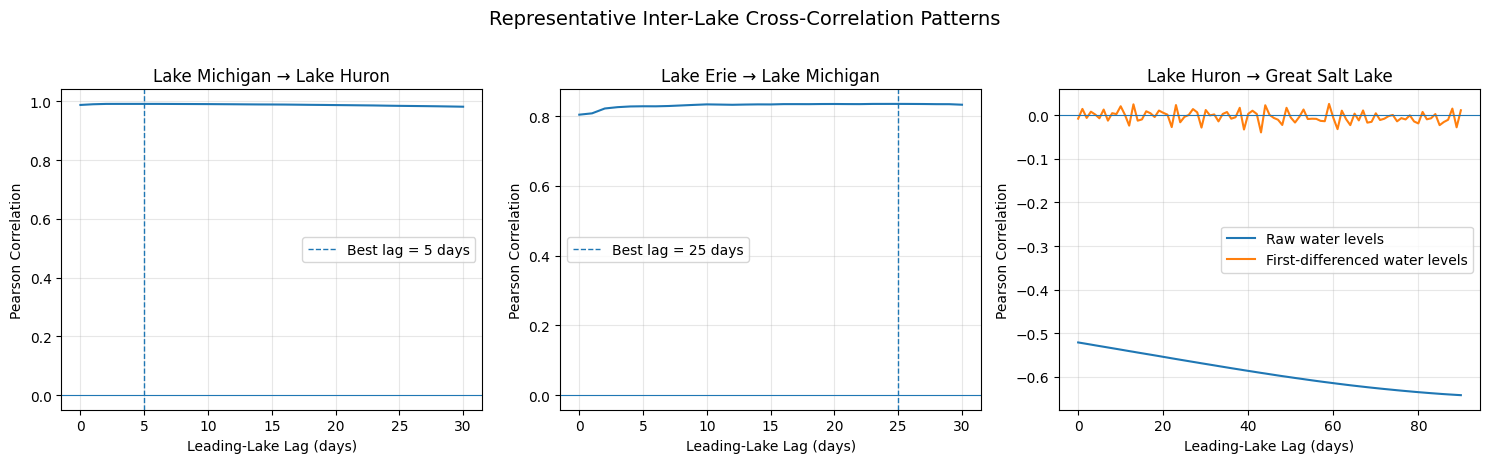

In [111]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5)
)


# Panel A: Strong near-synchronous relationship
michigan_huron = (
    interlake_ccf_results[
        (interlake_ccf_results["Leading Lake"] == "Lake Michigan")
        &
        (interlake_ccf_results["Response Lake"] == "Lake Huron")
    ]
    .sort_values("Lag")
    .copy()
)

axes[0].plot(
    michigan_huron["Lag"],
    michigan_huron["Correlation"]
)

axes[0].axhline(0, linewidth=0.8)
axes[0].axvline(
    5,
    linestyle="--",
    linewidth=1,
    label="Best lag = 5 days"
)

axes[0].set_title("Lake Michigan → Lake Huron")
axes[0].set_xlabel("Leading-Lake Lag (days)")
axes[0].set_ylabel("Pearson Correlation")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Panel B: Modest non-zero-lag strengthening
erie_michigan = (
    interlake_ccf_results[
        (interlake_ccf_results["Leading Lake"] == "Lake Erie")
        &
        (interlake_ccf_results["Response Lake"] == "Lake Michigan")
    ]
    .sort_values("Lag")
    .copy()
)

axes[1].plot(
    erie_michigan["Lag"],
    erie_michigan["Correlation"]
)

axes[1].axhline(0, linewidth=0.8)
axes[1].axvline(
    25,
    linestyle="--",
    linewidth=1,
    label="Best lag = 25 days"
)

axes[1].set_title("Lake Erie → Lake Michigan")
axes[1].set_xlabel("Leading-Lake Lag (days)")
axes[1].set_ylabel("Pearson Correlation")
axes[1].legend()
axes[1].grid(alpha=0.3)


# Panel C: Raw long-lag pattern versus first difference
huron_gsl_raw = (
    extended90_results[
        (extended90_results["Leading Lake"] == "Lake Huron")
        &
        (extended90_results["Response Lake"] == "Great Salt Lake")
    ]
    .sort_values("Lag")
    .copy()
)

huron_gsl_diff = (
    extended_diff_results[
        (extended_diff_results["Leading Lake"] == "Lake Huron")
        &
        (extended_diff_results["Response Lake"] == "Great Salt Lake")
    ]
    .sort_values("Lag")
    .copy()
)

axes[2].plot(
    huron_gsl_raw["Lag"],
    huron_gsl_raw["Correlation"],
    label="Raw water levels"
)

axes[2].plot(
    huron_gsl_diff["Lag"],
    huron_gsl_diff["Correlation"],
    label="First-differenced water levels"
)

axes[2].axhline(0, linewidth=0.8)

axes[2].set_title("Lake Huron → Great Salt Lake")
axes[2].set_xlabel("Leading-Lake Lag (days)")
axes[2].set_ylabel("Pearson Correlation")
axes[2].legend()
axes[2].grid(alpha=0.3)


fig.suptitle(
    "Representative Inter-Lake Cross-Correlation Patterns",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

fig.savefig(
    "Figure_Representative_Interlake_CCF_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### (3) Convergent Cross Mapping (CCM)
Linear correlation cannot distinguish synchrony from nonlinear dependence.

In [112]:
from pyEDM import CCM, Simplex
from scipy.stats import pearsonr
from itertools import combinations

#### 1.Prepare CCM Data

In [113]:
# Convert daily water levels to month-end monthly means
lake_level_monthly = (
    lake_level_wide
    .resample("ME")
    .mean()
)

# Count the number of observed daily values contributing to each monthly mean
lake_level_monthly_count = (
    lake_level_wide[lake_order]
    .resample("ME")
    .count()
)


print(
    "Monthly CCM data shape:",
    lake_level_monthly.shape
)

print("\nMissing monthly means:")
print(
    lake_level_monthly
    .isna()
    .sum()
)

print("\nMinimum number of daily observations in any month:")
print(
    lake_level_monthly_count
    .min()
)

Monthly CCM data shape: (240, 10)

Missing monthly means:
Lake
Lake Superior      0
Lake Huron         0
Lake Michigan      0
Lake Erie          0
Lake Ontario       0
Lake Woods         0
Great Salt Lake    0
Lake Champlain     0
Red Lake           4
Lake Tahoe         0
dtype: int64

Minimum number of daily observations in any month:
Lake
Lake Superior       1
Lake Huron          1
Lake Michigan      28
Lake Erie          28
Lake Ontario        2
Lake Woods         13
Great Salt Lake    28
Lake Champlain     28
Red Lake            0
Lake Tahoe         28
dtype: int64


In [114]:
# Calculate monthly data coverage

days_in_month = pd.Series(
    lake_level_monthly.index.days_in_month,
    index=lake_level_monthly.index
)

monthly_coverage = (
    lake_level_monthly_count
    .div(days_in_month, axis=0)
)


# Identify months with less than 50% observed daily coverage

low_coverage_months = (
    monthly_coverage
    .stack()
    .reset_index()
)

low_coverage_months.columns = [
    "Date",
    "Lake",
    "Coverage"
]

low_coverage_months = (
    low_coverage_months[
        low_coverage_months["Coverage"] < 0.50
    ]
    .sort_values(
        ["Lake", "Date"]
    )
    .reset_index(drop=True)
)

low_coverage_months

,Date,Lake,Coverage
0,2024-12-31,Lake Superior,0.032258
1,2021-10-31,Lake Huron,0.032258
2,2024-10-31,Lake Ontario,0.064516
3,2011-02-28,Lake Woods,0.464286
4,2010-12-31,Red Lake,0.322581
5,2011-01-31,Red Lake,0.000000
6,2011-02-28,Red Lake,0.000000
7,2011-10-31,Red Lake,0.354839
8,2011-11-30,Red Lake,0.000000
9,2011-12-31,Red Lake,0.000000


In [115]:
# Apply monthly coverage quality control for CCM

MIN_MONTHLY_COVERAGE = 0.50

lake_level_monthly_raw = (
    lake_level_monthly[lake_order]
    .copy()
)

# Treat monthly means based on less than 50% daily coverage as missing
lake_level_monthly_qc = (
    lake_level_monthly_raw
    .mask(
        monthly_coverage < MIN_MONTHLY_COVERAGE
    )
)

print(
    "Missing values after monthly coverage QC:"
)

print(
    lake_level_monthly_qc
    .isna()
    .sum()
)

Missing values after monthly coverage QC:
Lake
Lake Superior      1
Lake Huron         1
Lake Michigan      0
Lake Erie          0
Lake Ontario       1
Lake Woods         1
Great Salt Lake    0
Lake Champlain     0
Red Lake           6
Lake Tahoe         0
dtype: int64


In [116]:
# Interpolate flagged internal months at the monthly scale
# to preserve a regular monthly time axis for CCM

lake_level_monthly_ccm = (
    lake_level_monthly_qc
    .interpolate(
        method="time",
        limit_area="inside"
    )
)


print(
    "Final monthly CCM shape:",
    lake_level_monthly_ccm.shape
)

print("\nRemaining missing values:")
print(
    lake_level_monthly_ccm
    .isna()
    .sum()
)

Final monthly CCM shape: (240, 10)

Remaining missing values:
Lake
Lake Superior      0
Lake Huron         0
Lake Michigan      0
Lake Erie          0
Lake Ontario       0
Lake Woods         0
Great Salt Lake    0
Lake Champlain     0
Red Lake           0
Lake Tahoe         0
dtype: int64


In [117]:
assert lake_level_monthly_ccm.shape == (240, 10)
assert lake_level_monthly_ccm.isna().sum().sum() == 0

print("Monthly CCM dataset is complete and regularly spaced.")

Monthly CCM dataset is complete and regularly spaced.


#### 2.Select embedding dimensions

In [118]:
# 1. # Compute Pearson correlation between observed and predicted values

def compute_rho(observed, predicted):

    valid = pd.DataFrame({
        "Observed": observed,
        "Predicted": predicted
    }).dropna()

    if len(valid) <= 10:
        return np.nan

    if valid["Observed"].nunique() <= 1:
        return np.nan

    if valid["Predicted"].nunique() <= 1:
        return np.nan

    rho, _ = pearsonr(
        valid["Observed"],
        valid["Predicted"]
    )

    return rho

# 2. Evaluate candidate embedding dimensions for one lake

def choose_best_E_monthly(
    data,
    lake,
    E_range=range(1, 8)
):

    if lake not in data.columns:
        raise KeyError(
            f"{lake} is not present in the input dataset."
        )

    # CCM input should already be complete and regularly spaced
    if data[lake].isna().any():
        raise ValueError(
            f"Missing monthly values remain for {lake}."
        )

    df = (
        data[[lake]]
        .reset_index()
        .copy()
    )

    df.columns = [
        "Date",
        "x"
    ]

    n = len(df)

    if n < 50:
        raise ValueError(
            f"Insufficient monthly observations for {lake}: {n}"
        )

    # Use the first 70% as the library
    # and the remaining 30% as the prediction period
    library_end = int(n * 0.70)

    lib_range = f"1 {library_end}"
    pred_range = f"{library_end + 1} {n}"

    results = []

    for E in E_range:

        try:

            simplex_result = Simplex(
                dataFrame=df,
                columns="x",
                target="x",
                E=E,
                Tp=1,
                tau=-1,
                lib=lib_range,
                pred=pred_range,
                embedded=False,
                showPlot=False
            )

            rho = compute_rho(
                simplex_result["Observations"],
                simplex_result["Predictions"]
            )

            results.append({
                "Lake": lake,
                "E": E,
                "rho": rho,
                "Successful": True,
                "Error": None
            })

        except Exception as error:

            results.append({
                "Lake": lake,
                "E": E,
                "rho": np.nan,
                "Successful": False,
                "Error": str(error)
            })

    results = pd.DataFrame(results)

    valid_results = (
        results
        .dropna(subset=["rho"])
        .sort_values(
            ["rho", "E"],
            ascending=[False, True]
        )
    )

    if valid_results.empty:
        raise ValueError(
            f"No valid Simplex results for {lake}."
        )

    # Select E with the highest forecast skill.
    # If tied, prefer the smaller E.
    selected_E = int(
        valid_results.iloc[0]["E"]
    )

    maximum_rho = float(
        valid_results.iloc[0]["rho"]
    )

    results["Difference from maximum"] = (
        maximum_rho - results["rho"]
    )

    results["Selected"] = (
        results["E"] == selected_E
    )

    return selected_E, results


# 3.Select embedding dimensions for all lakes

monthly_embedding_results_list = []
monthly_best_E_dict = {}

for lake in lake_order:

    print(
        f"Evaluating embedding dimension for {lake}..."
    )

    selected_E, lake_E_results = (
        choose_best_E_monthly(
            data=lake_level_monthly_ccm,
            lake=lake,
            E_range=range(1, 8)
        )
    )

    monthly_best_E_dict[lake] = selected_E

    monthly_embedding_results_list.append(
        lake_E_results
    )


monthly_embedding_results = pd.concat(
    monthly_embedding_results_list,
    ignore_index=True
)


# 4. Create one-row-per-lake embedding-dimension summary

selected_E_rows = (
    monthly_embedding_results[
        monthly_embedding_results["Selected"]
    ]
    [
        [
            "Lake",
            "E",
            "rho"
        ]
    ]
    .rename(
        columns={
            "E": "Selected E",
            "rho": "Selected rho"
        }
    )
)


monthly_best_E_summary = (
    selected_E_rows
    .set_index("Lake")
    .reindex(lake_order)
    .reset_index()
)

# Check whether any selected E occurs at the upper search boundary

monthly_best_E_summary["At E Boundary"] = (
    monthly_best_E_summary["Selected E"] == 7
)

print(
    "Number of lakes selected at E=7 boundary:",
    monthly_best_E_summary["At E Boundary"].sum()
)

monthly_best_E_summary

Evaluating embedding dimension for Lake Superior...
Evaluating embedding dimension for Lake Huron...
Evaluating embedding dimension for Lake Michigan...
Evaluating embedding dimension for Lake Erie...
Evaluating embedding dimension for Lake Ontario...
Evaluating embedding dimension for Lake Woods...
Evaluating embedding dimension for Great Salt Lake...
Evaluating embedding dimension for Lake Champlain...
Evaluating embedding dimension for Red Lake...
Evaluating embedding dimension for Lake Tahoe...
Number of lakes selected at E=7 boundary: 0


,Lake,Selected E,Selected rho,At E Boundary
0,Lake Superior,2,0.933523,False
1,Lake Huron,2,0.976322,False
2,Lake Michigan,2,0.972533,False
3,Lake Erie,3,0.920923,False
4,Lake Ontario,3,0.920909,False
5,Lake Woods,2,0.859133,False
6,Great Salt Lake,1,0.803342,False
7,Lake Champlain,3,0.817176,False
8,Red Lake,2,0.926648,False
9,Lake Tahoe,2,0.983236,False


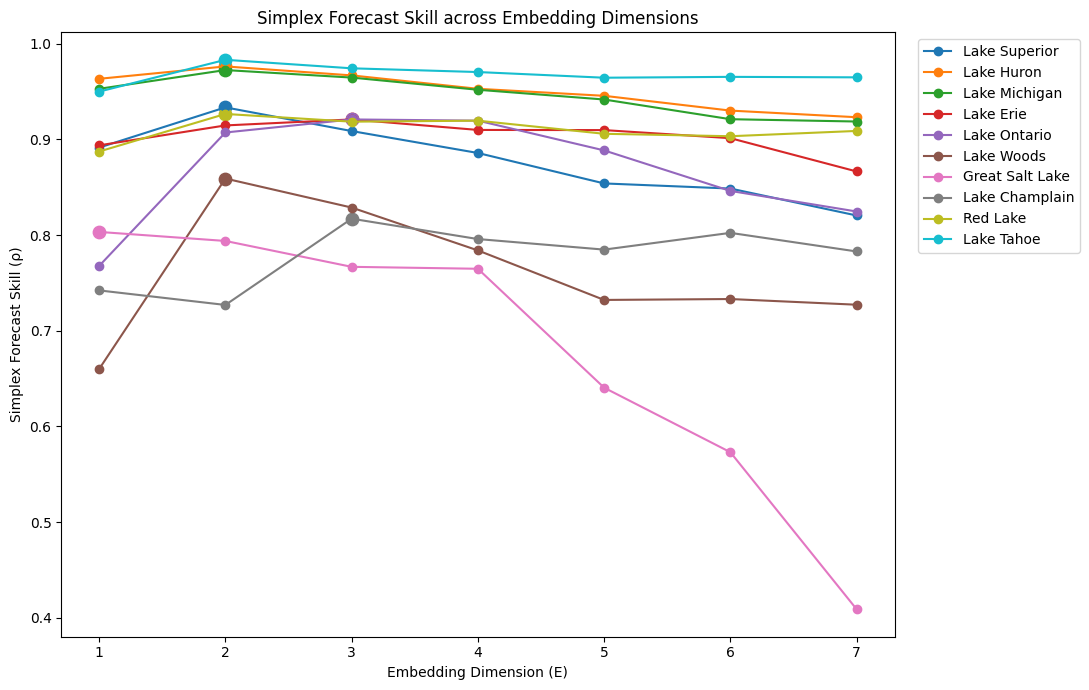

In [119]:
# 5. Plot Simplex forecast skill for all lakes
plt.figure(figsize=(11, 7))

for lake in lake_order:

    lake_results = (
        monthly_embedding_results[
            monthly_embedding_results["Lake"] == lake
        ]
        .sort_values("E")
    )

    plt.plot(
        lake_results["E"],
        lake_results["rho"],
        marker="o",
        label=lake
    )

    selected_row = lake_results[
        lake_results["Selected"]
    ]

    if not selected_row.empty:
        plt.scatter(
            selected_row["E"],
            selected_row["rho"],
            s=80
        )


plt.xlabel("Embedding Dimension (E)")
plt.ylabel("Simplex Forecast Skill (ρ)")
plt.title(
    "Simplex Forecast Skill across Embedding Dimensions"
)

plt.xticks(range(1, 8))
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [120]:
# 6. Construct pair-level common embedding dimensions


ccm_pair_E_rows = []

for lake_1, lake_2 in combinations(
    lake_order,
    2
):

    E_1 = monthly_best_E_dict[lake_1]
    E_2 = monthly_best_E_dict[lake_2]

    # Use the larger lake-specific embedding dimension
    # as the common E for the pair
    common_E = max(
        E_1,
        E_2
    )

    ccm_pair_E_rows.append({
        "Lake 1": lake_1,
        "Lake 2": lake_2,
        "Lake 1 E": E_1,
        "Lake 2 E": E_2,
        "Common E": common_E
    })


ccm_pair_E = pd.DataFrame(
    ccm_pair_E_rows
)


print(
    "Number of unique lake pairs:",
    len(ccm_pair_E)
)

print(
    "\nCommon E distribution:"
)

print(
    ccm_pair_E[
        "Common E"
    ]
    .value_counts()
    .sort_index()
)


display(ccm_pair_E)


Number of unique lake pairs: 45

Common E distribution:
Common E
2    21
3    24
Name: count, dtype: int64


,Lake 1,Lake 2,Lake 1 E,Lake 2 E,Common E
0,Lake Superior,Lake Huron,2,2,2
1,Lake Superior,Lake Michigan,2,2,2
2,Lake Superior,Lake Erie,2,3,3
3,Lake Superior,Lake Ontario,2,3,3
4,Lake Superior,Lake Woods,2,2,2
5,Lake Superior,Great Salt Lake,2,1,2
6,Lake Superior,Lake Champlain,2,3,3
7,Lake Superior,Red Lake,2,2,2
8,Lake Superior,Lake Tahoe,2,2,2
9,Lake Huron,Lake Michigan,2,2,2


#### 3.Pairwise CCM

In [121]:
# (1) Define the bidirectional CCM function

def run_ccm_pair(
    data,
    lake_1,
    lake_2,
    E,
    sample=20,
    seed=42
):
    """
    Run bidirectional CCM for one lake pair.

    Parameters
    ----------
    data : pandas.DataFrame
        Complete regularly spaced monthly water-level dataset.

    lake_1, lake_2 : str
        Names of the two lakes.

    E : int
        Common embedding dimension for the lake pair.

    sample : int
        Number of random library samples at each library size.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Pair information and bidirectional CCM output.
    """

    ccm_df = (
        data[
            [lake_1, lake_2]
        ]
        .reset_index()
        .copy()
    )

    ccm_df.columns = [
        "Date",
        "lake_1",
        "lake_2"
    ]

    # Evaluate cross-map skill from 20 to 220 months
    # in increments of 20 months
    lib_sizes = "20 220 20"

    try:

        ccm_output = CCM(
            dataFrame=ccm_df,
            E=E,
            Tp=0,
            tau=-1,
            columns="lake_1",
            target="lake_2",
            libSizes=lib_sizes,
            sample=sample,
            random=True,
            seed=seed,
            showPlot=False
        )

        rho_columns = [
            column
            for column in ccm_output.columns
            if column != "LibSize"
        ]

        return {
            "Lake 1": lake_1,
            "Lake 2": lake_2,
            "E": E,
            "Success": True,
            "Error": None,
            "CCM Output": ccm_output,
            "Rho Columns": rho_columns
        }

    except Exception as error:

        return {
            "Lake 1": lake_1,
            "Lake 2": lake_2,
            "E": E,
            "Success": False,
            "Error": str(error),
            "CCM Output": None,
            "Rho Columns": []
        }

In [122]:
# (2) Validate CCM using one lake pair

test_pair = ccm_pair_E[
    (ccm_pair_E["Lake 1"] == "Lake Huron")
    &
    (ccm_pair_E["Lake 2"] == "Lake Michigan")
].iloc[0]


test_ccm = run_ccm_pair(
    data=lake_level_monthly_ccm,
    lake_1=test_pair["Lake 1"],
    lake_2=test_pair["Lake 2"],
    E=int(test_pair["Common E"]),
    sample=20,
    seed=42
)


print("Success:", test_ccm["Success"])
print("Lake 1:", test_ccm["Lake 1"])
print("Lake 2:", test_ccm["Lake 2"])
print("Embedding dimension:", test_ccm["E"])
print("CCM rho columns:", test_ccm["Rho Columns"])
print("Error:", test_ccm["Error"])

if test_ccm["Success"]:
    display(test_ccm["CCM Output"])

Success: True
Lake 1: Lake Huron
Lake 2: Lake Michigan
Embedding dimension: 2
CCM rho columns: ['lake_1:lake_2', 'lake_2:lake_1']
Error: None


,LibSize,lake_1:lake_2,lake_2:lake_1
0,20.0,0.980674,0.985136
1,40.0,0.987092,0.990389
2,60.0,0.992630,0.995484
3,80.0,0.993570,0.996147
4,100.0,0.993997,0.996358
5,120.0,0.994743,0.996816
6,140.0,0.995093,0.996960
7,160.0,0.995455,0.997129
8,180.0,0.995583,0.997232
9,200.0,0.995739,0.997333


In [123]:
#(3) Run bidirectional CCM for all 45 lake pairs
all_ccm_outputs = []

for pair_number, (_, pair_row) in enumerate(
    ccm_pair_E.iterrows(),
    start=1
):
    lake_1 = pair_row["Lake 1"]
    lake_2 = pair_row["Lake 2"]
    common_E = int(
        pair_row["Common E"]
    )
    
    print(
        f"Running CCM pair "
        f"{pair_number}/{len(ccm_pair_E)}: "
        f"{lake_1} and {lake_2} "
        f"(E={common_E})"
    )

    result = run_ccm_pair(
        data=lake_level_monthly_ccm,
        lake_1=lake_1,
        lake_2=lake_2,
        sample=20,
        E=common_E,
        seed=42
    )

    all_ccm_outputs.append(result)

Running CCM pair 1/45: Lake Superior and Lake Huron (E=2)
Running CCM pair 2/45: Lake Superior and Lake Michigan (E=2)
Running CCM pair 3/45: Lake Superior and Lake Erie (E=3)
Running CCM pair 4/45: Lake Superior and Lake Ontario (E=3)
Running CCM pair 5/45: Lake Superior and Lake Woods (E=2)
Running CCM pair 6/45: Lake Superior and Great Salt Lake (E=2)
Running CCM pair 7/45: Lake Superior and Lake Champlain (E=3)
Running CCM pair 8/45: Lake Superior and Red Lake (E=2)
Running CCM pair 9/45: Lake Superior and Lake Tahoe (E=2)
Running CCM pair 10/45: Lake Huron and Lake Michigan (E=2)
Running CCM pair 11/45: Lake Huron and Lake Erie (E=3)
Running CCM pair 12/45: Lake Huron and Lake Ontario (E=3)
Running CCM pair 13/45: Lake Huron and Lake Woods (E=2)
Running CCM pair 14/45: Lake Huron and Great Salt Lake (E=2)
Running CCM pair 15/45: Lake Huron and Lake Champlain (E=3)
Running CCM pair 16/45: Lake Huron and Red Lake (E=2)
Running CCM pair 17/45: Lake Huron and Lake Tahoe (E=2)
Running 

In [124]:
# (4) Check unsuccessful CCM runs

failed_ccm_pairs = pd.DataFrame([
    {
        "Lake 1": result["Lake 1"],
        "Lake 2": result["Lake 2"],
        "E": result["E"],
        "Error": result["Error"]
    }
    for result in all_ccm_outputs
    if not result["Success"]
])


print(
    "Number of unsuccessful pairs:",
    len(failed_ccm_pairs)
)

failed_ccm_pairs

Number of unsuccessful pairs: 0


""


Bidirectional CCM statistics were successfully extracted for all 45 unique lake pairs (90 directional relationships)

In [125]:
# (5) Summarise bidirectional CCM results

ccm_summary_rows = []

for result in all_ccm_outputs:

    if not result["Success"]:
        continue

    ccm_output = (
        result["CCM Output"]
        .sort_values("LibSize")
        .reset_index(drop=True)
    )

    for rho_column in result["Rho Columns"]:

        direction_data = (
            ccm_output[
                ["LibSize", rho_column]
            ]
            .dropna()
            .reset_index(drop=True)
        )

        if len(direction_data) < 3:
            continue

        start_rho = float(
            direction_data[rho_column].iloc[0]
        )

        final_rho = float(
            direction_data[rho_column].iloc[-1]
        )

        rho_gain = (
            final_rho - start_rho
        )

        # Compare early and late cross-map skill
        early_mean_rho = float(
            direction_data[rho_column]
            .iloc[:3]
            .mean()
        )

        late_mean_rho = float(
            direction_data[rho_column]
            .iloc[-3:]
            .mean()
        )

        late_early_gain = (
            late_mean_rho - early_mean_rho
        )


        # Interpret the CCM direction.
        #
        # lake_1:lake_2 means that the manifold reconstructed
        # from lake_1 is used to estimate lake_2.
        # Under CCM interpretation, this provides directional
        # evidence from lake_2 to lake_1.

        if rho_column == "lake_1:lake_2":

            manifold_lake = result["Lake 1"]
            estimated_lake = result["Lake 2"]

            ccm_from = result["Lake 2"]
            ccm_to = result["Lake 1"]

        elif rho_column == "lake_2:lake_1":

            manifold_lake = result["Lake 2"]
            estimated_lake = result["Lake 1"]

            ccm_from = result["Lake 1"]
            ccm_to = result["Lake 2"]

        else:
            continue


        ccm_summary_rows.append({
            "Lake 1": result["Lake 1"],
            "Lake 2": result["Lake 2"],
            "Manifold Lake": manifold_lake,
            "Estimated Lake": estimated_lake,
            "CCM From": ccm_from,
            "CCM To": ccm_to,
            "CCM Direction": f"{ccm_from} → {ccm_to}",
            "Raw Direction": rho_column,
            "E": result["E"],
            "Start rho": start_rho,
            "Final rho": final_rho,
            "Rho gain": rho_gain,
            "Early mean rho": early_mean_rho,
            "Late mean rho": late_mean_rho,
            "Late–early rho gain": late_early_gain
        })


ccm_summary = pd.DataFrame(
    ccm_summary_rows
)


print(
    "Number of directional CCM results:",
    len(ccm_summary)
)

display(
    ccm_summary.head(10)
)

Number of directional CCM results: 90


,Lake 1,Lake 2,Manifold Lake,Estimated Lake,CCM From,CCM To,CCM Direction,Raw Direction,E,Start rho,Final rho,Rho gain,Early mean rho,Late mean rho,Late–early rho gain
0,Lake Superior,Lake Huron,Lake Superior,Lake Huron,Lake Huron,Lake Superior,Lake Huron → Lake Superior,lake_1:lake_2,2,0.811985,0.805693,-0.006292,0.813261,0.807751,-0.005510
1,Lake Superior,Lake Huron,Lake Huron,Lake Superior,Lake Superior,Lake Huron,Lake Superior → Lake Huron,lake_2:lake_1,2,0.809199,0.839164,0.029965,0.822784,0.835906,0.013122
2,Lake Superior,Lake Michigan,Lake Superior,Lake Michigan,Lake Michigan,Lake Superior,Lake Michigan → Lake Superior,lake_1:lake_2,2,0.801102,0.796026,-0.005076,0.803097,0.798222,-0.004875
3,Lake Superior,Lake Michigan,Lake Michigan,Lake Superior,Lake Superior,Lake Michigan,Lake Superior → Lake Michigan,lake_2:lake_1,2,0.818231,0.832928,0.014697,0.827047,0.830748,0.003700
4,Lake Superior,Lake Erie,Lake Superior,Lake Erie,Lake Erie,Lake Superior,Lake Erie → Lake Superior,lake_1:lake_2,3,0.578357,0.582321,0.003964,0.599369,0.585166,-0.014203
5,Lake Superior,Lake Erie,Lake Erie,Lake Superior,Lake Superior,Lake Erie,Lake Superior → Lake Erie,lake_2:lake_1,3,0.649512,0.677561,0.028049,0.662999,0.676864,0.013865
6,Lake Superior,Lake Ontario,Lake Superior,Lake Ontario,Lake Ontario,Lake Superior,Lake Ontario → Lake Superior,lake_1:lake_2,3,0.345940,0.491656,0.145716,0.410760,0.490115,0.079355
7,Lake Superior,Lake Ontario,Lake Ontario,Lake Superior,Lake Superior,Lake Ontario,Lake Superior → Lake Ontario,lake_2:lake_1,3,0.292310,0.325978,0.033668,0.301478,0.329707,0.028229
8,Lake Superior,Lake Woods,Lake Superior,Lake Woods,Lake Woods,Lake Superior,Lake Woods → Lake Superior,lake_1:lake_2,2,0.240182,0.339108,0.098926,0.300399,0.341717,0.041318
9,Lake Superior,Lake Woods,Lake Woods,Lake Superior,Lake Superior,Lake Woods,Lake Superior → Lake Woods,lake_2:lake_1,2,0.213646,0.295463,0.081817,0.227890,0.300067,0.072177


In [126]:
# (6) Summarise CCM results at the lake-pair level

ccm_pair_summary_rows = []

for (lake_1, lake_2), group in ccm_summary.groupby(
    ["Lake 1", "Lake 2"],
    sort=False
):

    group = group.reset_index(drop=True)

    direction_1 = group.iloc[0]
    direction_2 = group.iloc[1]

    final_rho_asymmetry = abs(
        direction_1["Final rho"]
        -
        direction_2["Final rho"]
    )

    ccm_pair_summary_rows.append({

        "Lake 1": lake_1,
        "Lake 2": lake_2,
        "E": int(direction_1["E"]),

        "Direction 1": direction_1["CCM Direction"],
        "Direction 1 final rho": direction_1["Final rho"],
        "Direction 1 late–early gain":
            direction_1["Late–early rho gain"],

        "Direction 2": direction_2["CCM Direction"],
        "Direction 2 final rho": direction_2["Final rho"],
        "Direction 2 late–early gain":
            direction_2["Late–early rho gain"],

        "Mean final rho": group["Final rho"].mean(),

        "Mean late–early gain":
            group["Late–early rho gain"].mean(),

        "Final rho asymmetry":
            final_rho_asymmetry
    })


ccm_pair_summary = pd.DataFrame(
    ccm_pair_summary_rows
)

print(
    "Number of lake-pair summaries:",
    len(ccm_pair_summary)
)

display(
    ccm_pair_summary.head(10)
)


# (7) Rank lake pairs by mean final cross-map skill

ccm_pair_rank = (
    ccm_pair_summary
    .sort_values(
        "Mean final rho",
        ascending=False
    )
    .reset_index(drop=True)
)

ccm_pair_rank.insert(
    0,
    "Pair Rank",
    range(1, len(ccm_pair_rank) + 1)
)

display(
    ccm_pair_rank.head(15)
)


# (8) Rank lake pairs by directional asymmetry

ccm_asymmetry_rank = (
    ccm_pair_summary
    .sort_values(
        "Final rho asymmetry",
        ascending=False
    )
    .reset_index(drop=True)
)

ccm_asymmetry_rank.insert(
    0,
    "Asymmetry Rank",
    range(1, len(ccm_asymmetry_rank) + 1)
)

display(
    ccm_asymmetry_rank.head(15)
)

Number of lake-pair summaries: 45


,Lake 1,Lake 2,E,Direction 1,Direction 1 final rho,Direction 1 late–early gain,Direction 2,Direction 2 final rho,Direction 2 late–early gain,Mean final rho,Mean late–early gain,Final rho asymmetry
0,Lake Superior,Lake Huron,2,Lake Huron → Lake Superior,0.805693,-0.005510,Lake Superior → Lake Huron,0.839164,0.013122,0.822428,0.003806,0.033471
1,Lake Superior,Lake Michigan,2,Lake Michigan → Lake Superior,0.796026,-0.004875,Lake Superior → Lake Michigan,0.832928,0.003700,0.814477,-0.000587,0.036903
2,Lake Superior,Lake Erie,3,Lake Erie → Lake Superior,0.582321,-0.014203,Lake Superior → Lake Erie,0.677561,0.013865,0.629941,-0.000169,0.095240
3,Lake Superior,Lake Ontario,3,Lake Ontario → Lake Superior,0.491656,0.079355,Lake Superior → Lake Ontario,0.325978,0.028229,0.408817,0.053792,0.165678
4,Lake Superior,Lake Woods,2,Lake Woods → Lake Superior,0.339108,0.041318,Lake Superior → Lake Woods,0.295463,0.072177,0.317286,0.056748,0.043645
5,Lake Superior,Great Salt Lake,2,Great Salt Lake → Lake Superior,0.536183,-0.001126,Lake Superior → Great Salt Lake,0.588685,-0.009255,0.562434,-0.005191,0.052502
6,Lake Superior,Lake Champlain,3,Lake Champlain → Lake Superior,0.313897,0.052614,Lake Superior → Lake Champlain,0.342774,0.089004,0.328336,0.070809,0.028877
7,Lake Superior,Red Lake,2,Red Lake → Lake Superior,0.043193,-0.041581,Lake Superior → Red Lake,0.359468,0.144770,0.201331,0.051594,0.316275
8,Lake Superior,Lake Tahoe,2,Lake Tahoe → Lake Superior,0.185894,0.054384,Lake Superior → Lake Tahoe,0.360482,0.074156,0.273188,0.064270,0.174589
9,Lake Huron,Lake Michigan,2,Lake Michigan → Lake Huron,0.995811,0.008912,Lake Huron → Lake Michigan,0.997398,0.006985,0.996605,0.007949,0.001587


,Pair Rank,Lake 1,Lake 2,E,Direction 1,Direction 1 final rho,Direction 1 late–early gain,Direction 2,Direction 2 final rho,Direction 2 late–early gain,Mean final rho,Mean late–early gain,Final rho asymmetry
0,1,Lake Huron,Lake Michigan,2,Lake Michigan → Lake Huron,0.995811,0.008912,Lake Huron → Lake Michigan,0.997398,0.006985,0.996605,0.007949,0.001587
1,2,Lake Huron,Lake Erie,3,Lake Erie → Lake Huron,0.902509,0.039998,Lake Huron → Lake Erie,0.909625,0.012759,0.906067,0.026379,0.007117
2,3,Lake Michigan,Lake Erie,3,Lake Erie → Lake Michigan,0.895522,0.032964,Lake Michigan → Lake Erie,0.907815,0.012706,0.901669,0.022835,0.012293
3,4,Lake Superior,Lake Huron,2,Lake Huron → Lake Superior,0.805693,-0.005510,Lake Superior → Lake Huron,0.839164,0.013122,0.822428,0.003806,0.033471
4,5,Lake Superior,Lake Michigan,2,Lake Michigan → Lake Superior,0.796026,-0.004875,Lake Superior → Lake Michigan,0.832928,0.003700,0.814477,-0.000587,0.036903
5,6,Lake Erie,Lake Ontario,3,Lake Ontario → Lake Erie,0.651239,0.057446,Lake Erie → Lake Ontario,0.630472,0.066682,0.640855,0.062064,0.020768
6,7,Lake Superior,Lake Erie,3,Lake Erie → Lake Superior,0.582321,-0.014203,Lake Superior → Lake Erie,0.677561,0.013865,0.629941,-0.000169,0.095240
7,8,Lake Michigan,Lake Ontario,3,Lake Ontario → Lake Michigan,0.772025,0.197283,Lake Michigan → Lake Ontario,0.391369,0.073608,0.581697,0.135445,0.380655
8,9,Lake Huron,Lake Ontario,3,Lake Ontario → Lake Huron,0.763101,0.197312,Lake Huron → Lake Ontario,0.390579,0.078763,0.576840,0.138038,0.372523
9,10,Lake Superior,Great Salt Lake,2,Great Salt Lake → Lake Superior,0.536183,-0.001126,Lake Superior → Great Salt Lake,0.588685,-0.009255,0.562434,-0.005191,0.052502


,Asymmetry Rank,Lake 1,Lake 2,E,Direction 1,Direction 1 final rho,Direction 1 late–early gain,Direction 2,Direction 2 final rho,Direction 2 late–early gain,Mean final rho,Mean late–early gain,Final rho asymmetry
0,1,Lake Champlain,Lake Tahoe,3,Lake Tahoe → Lake Champlain,0.083900,-0.056370,Lake Champlain → Lake Tahoe,0.560068,0.199581,0.321984,0.071605,0.476168
1,2,Lake Michigan,Lake Champlain,3,Lake Champlain → Lake Michigan,0.603920,0.180787,Lake Michigan → Lake Champlain,0.169897,0.048289,0.386908,0.114538,0.434023
2,3,Lake Huron,Lake Champlain,3,Lake Champlain → Lake Huron,0.606919,0.189120,Lake Huron → Lake Champlain,0.187357,0.051884,0.397138,0.120502,0.419562
3,4,Lake Woods,Lake Tahoe,2,Lake Tahoe → Lake Woods,-0.051014,-0.015889,Lake Woods → Lake Tahoe,0.351943,0.124593,0.150465,0.054352,0.402957
4,5,Lake Michigan,Lake Ontario,3,Lake Ontario → Lake Michigan,0.772025,0.197283,Lake Michigan → Lake Ontario,0.391369,0.073608,0.581697,0.135445,0.380655
5,6,Lake Huron,Lake Ontario,3,Lake Ontario → Lake Huron,0.763101,0.197312,Lake Huron → Lake Ontario,0.390579,0.078763,0.576840,0.138038,0.372523
6,7,Lake Erie,Lake Champlain,3,Lake Champlain → Lake Erie,0.475610,0.078168,Lake Erie → Lake Champlain,0.141295,0.022705,0.308452,0.050436,0.334315
7,8,Lake Superior,Red Lake,2,Red Lake → Lake Superior,0.043193,-0.041581,Lake Superior → Red Lake,0.359468,0.144770,0.201331,0.051594,0.316275
8,9,Lake Ontario,Great Salt Lake,3,Great Salt Lake → Lake Ontario,0.057755,0.015108,Lake Ontario → Great Salt Lake,0.347400,0.136658,0.202577,0.075883,0.289646
9,10,Lake Ontario,Lake Tahoe,3,Lake Tahoe → Lake Ontario,0.256738,0.002771,Lake Ontario → Lake Tahoe,0.469924,0.060177,0.363331,0.031474,0.213186


In [127]:
# (9) Select representative lake pairs

representative_pair_metadata = pd.DataFrame({
    "Lake 1": [
        "Lake Huron",
        "Lake Michigan",
        "Lake Champlain"
    ],
    "Lake 2": [
        "Lake Michigan",
        "Lake Ontario",
        "Lake Tahoe"
    ],
    "Selection rationale": [
        (
            "Highest overall bidirectional cross-map skill "
            "with very low directional asymmetry"
        ),
        (
            "Strong convergence with pronounced directional "
            "asymmetry within the Great Lakes"
        ),
        (
            "Largest final-rho directional asymmetry "
            "among all lake pairs"
        )
    ]
})


representative_ccm_pairs = list(
    zip(
        representative_pair_metadata["Lake 1"],
        representative_pair_metadata["Lake 2"]
    )
)

representative_pair_metadata

,Lake 1,Lake 2,Selection rationale
0,Lake Huron,Lake Michigan,Highest overall bidirectional cross-map skill ...
1,Lake Michigan,Lake Ontario,Strong convergence with pronounced directional...
2,Lake Champlain,Lake Tahoe,Largest final-rho directional asymmetry among ...


In [128]:
# (10) Retrieve pair-level summaries for representative lake pairs
def retrieve_pair_summary(
    pair_summary,
    lake_1,
    lake_2
):
    """
    Retrieve one pair-level CCM summary regardless of
    the stored order of the two lake names.
    """

    requested_pair = {lake_1, lake_2}

    for _, row in pair_summary.iterrows():

        stored_pair = {
            row["Lake 1"],
            row["Lake 2"]
        }

        if stored_pair == requested_pair:
            return row

    return None


representative_summary_rows = []

for _, metadata_row in representative_pair_metadata.iterrows():

    lake_1 = metadata_row["Lake 1"]
    lake_2 = metadata_row["Lake 2"]

    summary_row = retrieve_pair_summary(
        ccm_pair_summary,
        lake_1,
        lake_2
    )

    if summary_row is None:
        print(
            f"Pair summary not found: "
            f"{lake_1} and {lake_2}"
        )
        continue

    representative_summary_rows.append(
        {
            "Lake 1": lake_1,
            "Lake 2": lake_2,
            "Mean final rho": summary_row["Mean final rho"],
            "Mean late–early gain": summary_row[
                "Mean late–early gain"
            ],
            "Final rho asymmetry": summary_row[
                "Final rho asymmetry"
            ],
            "Selection rationale": metadata_row[
                "Selection rationale"
            ]
        }
    )


representative_pair_summary = pd.DataFrame(
    representative_summary_rows
)

representative_pair_summary

,Lake 1,Lake 2,Mean final rho,Mean late–early gain,Final rho asymmetry,Selection rationale
0,Lake Huron,Lake Michigan,0.996605,0.007949,0.001587,Highest overall bidirectional cross-map skill ...
1,Lake Michigan,Lake Ontario,0.581697,0.135445,0.380655,Strong convergence with pronounced directional...
2,Lake Champlain,Lake Tahoe,0.321984,0.071605,0.476168,Largest final-rho directional asymmetry among ...


In [129]:
# (11) Retrieve one CCM result

def get_ccm_pair_result(
    all_results,
    lake_a,
    lake_b
):
    """
    Retrieve the CCM result for one lake pair,
    regardless of the order in which the lakes are supplied.
    """

    for result in all_results:

        pair_matches = (
            (
                result["Lake 1"] == lake_a
                and
                result["Lake 2"] == lake_b
            )
            or
            (
                result["Lake 1"] == lake_b
                and
                result["Lake 2"] == lake_a
            )
        )

        if pair_matches:
            return result

    return None

In [130]:
# (12) Plot one bidirectional CCM convergence result

def plot_ccm_convergence(
    result,
    ax=None,
    y_limits=(-0.10, 1.05)
):

    if result is None:
        return

    if not result.get("Success", False):
        return

    ccm = (
        result["CCM Output"]
        .sort_values("LibSize")
        .reset_index(drop=True)
    )

    rho_1 = result["Rho Columns"][0]
    rho_2 = result["Rho Columns"][1]

    # lake_1:lake_2 corresponds to CCM evidence:
    # Lake 2 → Lake 1
    direction_1_label = (
        f'{result["Lake 2"]} → '
        f'{result["Lake 1"]}'
    )

    # lake_2:lake_1 corresponds to CCM evidence:
    # Lake 1 → Lake 2
    direction_2_label = (
        f'{result["Lake 1"]} → '
        f'{result["Lake 2"]}'
    )

    if ax is None:
        _, ax = plt.subplots(
            figsize=(7, 5)
        )

    ax.plot(
        ccm["LibSize"],
        ccm[rho_1],
        marker="o",
        linewidth=1.8,
        label=direction_1_label
    )

    ax.plot(
        ccm["LibSize"],
        ccm[rho_2],
        marker="s",
        linewidth=1.8,
        label=direction_2_label
    )

    ax.set_xlabel(
        "Library Size (months)"
    )

    ax.set_ylabel(
        "Cross-map Skill (ρ)"
    )

    ax.set_ylim(
        y_limits
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    return ax

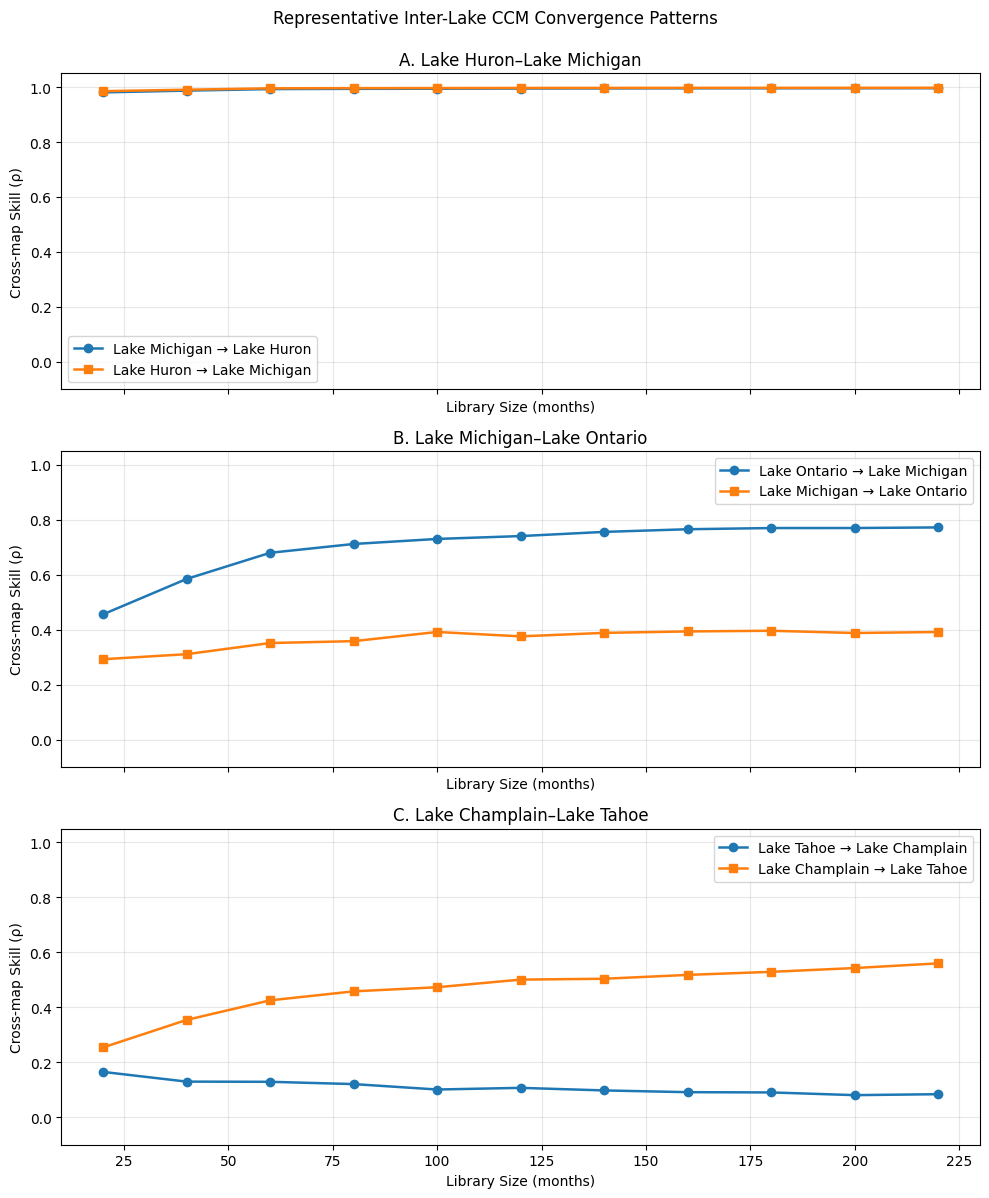

In [131]:
# (13) Plot representative CCM convergence patterns

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 12),
    sharex=True
)

panel_labels = [
    "A",
    "B",
    "C"
]

for ax, panel, (lake_1, lake_2) in zip(
    axes,
    panel_labels,
    representative_ccm_pairs
):

    result = get_ccm_pair_result(
        all_ccm_outputs,
        lake_1,
        lake_2
    )

    plot_ccm_convergence(
        result=result,
        ax=ax,
        y_limits=(-0.10, 1.05)
    )

    ax.set_title(
        f"{panel}. {lake_1}–{lake_2}"
    )


fig.suptitle(
    "Representative Inter-Lake CCM Convergence Patterns",
    y=0.995
)

plt.tight_layout()

plt.savefig(
    "Figure_Representative_CCM_Convergence_Patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [132]:
# (14) Summarise directional CCM results for representative lake pairs

representative_directional_rows = []

for lake_1, lake_2 in representative_ccm_pairs:

    result = get_ccm_pair_result(
        all_ccm_outputs,
        lake_1,
        lake_2
    )

    if result is None:
        continue

    if not result.get("Success", False):
        continue

    ccm = (
        result["CCM Output"]
        .sort_values("LibSize")
        .reset_index(drop=True)
    )

    rho_1 = result["Rho Columns"][0]
    rho_2 = result["Rho Columns"][1]


    direction_info = [
        (
            rho_1,
            result["Lake 2"],
            result["Lake 1"]
        ),
        (
            rho_2,
            result["Lake 1"],
            result["Lake 2"]
        )
    ]


    for rho_column, ccm_from, ccm_to in direction_info:

        series = (
            ccm[rho_column]
            .dropna()
            .reset_index(drop=True)
        )

        start_rho = series.iloc[0]
        final_rho = series.iloc[-1]

        early_mean_rho = (
            series.iloc[:3].mean()
        )

        late_mean_rho = (
            series.iloc[-3:].mean()
        )


        representative_directional_rows.append({
            "Lake pair":
                f"{lake_1}–{lake_2}",

            "Direction":
                f"{ccm_from} → {ccm_to}",

            "Start rho":
                start_rho,

            "Final rho":
                final_rho,

            "Rho gain":
                final_rho - start_rho,

            "Late–early rho gain":
                late_mean_rho - early_mean_rho,

            "Embedding dimension":
                result["E"]
        })


representative_directional_summary = pd.DataFrame(
    representative_directional_rows
)


representative_directional_summary[
    [
        "Start rho",
        "Final rho",
        "Rho gain",
        "Late–early rho gain"
    ]
] = (
    representative_directional_summary[
        [
            "Start rho",
            "Final rho",
            "Rho gain",
            "Late–early rho gain"
        ]
    ]
    .round(3)
)


representative_directional_summary

,Lake pair,Direction,Start rho,Final rho,Rho gain,Late–early rho gain,Embedding dimension
0,Lake Huron–Lake Michigan,Lake Michigan → Lake Huron,0.981,0.996,0.015,0.009,2
1,Lake Huron–Lake Michigan,Lake Huron → Lake Michigan,0.985,0.997,0.012,0.007,2
2,Lake Michigan–Lake Ontario,Lake Ontario → Lake Michigan,0.456,0.772,0.316,0.197,3
3,Lake Michigan–Lake Ontario,Lake Michigan → Lake Ontario,0.292,0.391,0.099,0.074,3
4,Lake Champlain–Lake Tahoe,Lake Tahoe → Lake Champlain,0.165,0.084,-0.081,-0.056,3
5,Lake Champlain–Lake Tahoe,Lake Champlain → Lake Tahoe,0.254,0.560,0.306,0.200,3


In [133]:
# (15) Export final CCM results

output_directory =  ccm_results_path

output_directory.mkdir(
    parents=True,
    exist_ok=True
)


# Lake-specific embedding dimensions
monthly_best_E_summary.to_csv(
    output_directory
    / "ccm_embedding_dimensions.csv",
    index=False
)


# Pair-level common embedding dimensions
ccm_pair_E.to_csv(
    output_directory
    / "ccm_pair_common_E.csv",
    index=False
)


# Complete 90-direction CCM summary
ccm_summary.to_csv(
    output_directory
    / "ccm_directional_summary_all_90.csv",
    index=False
)


# Complete 45-pair CCM summary
ccm_pair_summary.to_csv(
    output_directory
    / "ccm_pair_summary_all_45.csv",
    index=False
)


# Rank lake pairs by mean final rho
ccm_pair_rank.to_csv(
    output_directory
    / "ccm_pairs_ranked_by_mean_final_rho.csv",
    index=False
)


# Rank lake pairs by directional asymmetry
ccm_asymmetry_rank.to_csv(
    output_directory
    / "ccm_pairs_ranked_by_asymmetry.csv",
    index=False
)


# Representative pair information
representative_pair_metadata.to_csv(
    output_directory
    / "ccm_representative_pairs.csv",
    index=False
)


# Representative directional results
representative_directional_summary.to_csv(
    output_directory
    / "ccm_representative_directional_summary.csv",
    index=False
)


print(
    "Final CCM results saved successfully."
)

Final CCM results saved successfully.


In [134]:
# (16) Export all CCM library-size curves

ccm_curve_rows = []

for result in all_ccm_outputs:

    if not result["Success"]:
        continue

    ccm = (
        result["CCM Output"]
        .sort_values("LibSize")
        .reset_index(drop=True)
    )

    direction_info = [
        (
            result["Rho Columns"][0],
            result["Lake 2"],
            result["Lake 1"]
        ),
        (
            result["Rho Columns"][1],
            result["Lake 1"],
            result["Lake 2"]
        )
    ]

    for rho_column, ccm_from, ccm_to in direction_info:

        for _, row in ccm.iterrows():

            ccm_curve_rows.append({
                "Lake 1": result["Lake 1"],
                "Lake 2": result["Lake 2"],
                "CCM From": ccm_from,
                "CCM To": ccm_to,
                "E": result["E"],
                "LibSize": row["LibSize"],
                "rho": row[rho_column]
            })


ccm_library_curves = pd.DataFrame(
    ccm_curve_rows
)


ccm_library_curves.to_csv(
    output_directory
    / "ccm_library_curves_all_directions.csv",
    index=False
)